In [1]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import sweetviz as sv
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import warnings
from scipy.stats import zscore, mode
from sklearn.metrics import (silhouette_samples,silhouette_score,make_scorer,mean_absolute_error, r2_score, mean_squared_error,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)
from sklearn.base import (BaseEstimator,TransformerMixin,ClassifierMixin,RegressorMixin)
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, BaseCrossValidator, KFold, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import joblib
from joblib import load
import os
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.clustering import TimeSeriesKMeans, silhouette_score as ts_silhouette_score
import shap
from lime import lime_tabular
from sklearn.model_selection import GroupKFold

In [2]:
# Cargar los datos desde el archivo Excel
file_path = 'C:/Users/Andy/OneDrive/Desktop/MCD/Tesis/Datos_fuente_Bloomberg/en valores/serie completa 2014-2024/Dataset/dataset_completo.xlsx'
df = pd.read_excel(file_path, sheet_name='dataset')

In [3]:
df.head()

,Empresa,Fecha,P_E,P_B,P_TB,P_S,P_CF,P_FCF,P_Share,ROCE_sp,...,Efectivo y equiv_l,CPI,CPI_Exp_mediana,CPI_Exp_promedio,Fed Funds Rate,Fed Funds Rate_Exp_mediana,Fed Funds Rate_Exp_promedio,Non farm payrolls,Non farm payrolls_Exp_mediana,Non farm payrolls_Exp_promedio
0,FLWS US Equity,20140930,31.7207,2.5643,6.1415,0.6062,10.3190,21.6093,7.19,5.886400,...,1.314000,1.7,0.019,0.0191,0.25,0.0025,0.0025,307,230k,226.13k
1,FLWS US Equity,20141031,35.4266,2.8638,6.859,0.677,11.5246,24.1339,8.03,8.881198,...,2.610333,1.7,0.016,0.0162,0.25,0.0025,0.0025,240,215k,216.22k
2,FLWS US Equity,20141128,37.7207,3.0493,7.3032,0.7208,12.2709,25.6967,8.55,9.469145,...,3.906667,1.3,0.016,0.0157,0.25,0.0025,0.0025,284,235k,236.62k
3,FLWS US Equity,20141231,11.3711,2.3843,8.1913,0.5153,2.6214,3.0449,8.24,8.721900,...,5.203000,0.8,0.014,0.0142,0.25,0.0025,0.0025,278,230k,229.16k
4,FLWS US Equity,20150130,10.8881,2.283,7.8433,0.4934,2.5100,2.9155,7.89,7.711122,...,4.188000,-0.1,0.007,0.0069,0.25,0.0025,0.0025,196,240k,234.73k


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166440 entries, 0 to 166439
Data columns (total 42 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Empresa                         166440 non-null  object 
 1   Fecha                           166440 non-null  int64  
 2   P_E                             87792 non-null   float64
 3   P_B                             119348 non-null  object 
 4   P_TB                            92514 non-null   object 
 5   P_S                             117703 non-null  object 
 6   P_CF                            95713 non-null   float64
 7   P_FCF                           69291 non-null   object 
 8   P_Share                         131345 non-null  object 
 9   ROCE_sp                         115613 non-null  float64
 10  ROCE_l                          115613 non-null  float64
 11  EBIT_sp                         115176 non-null  float64
 12  EBIT_l          

In [5]:
# Quitar "k" de las columnas "Non farm payrolls_Exp_mediana" y "Non farm payrolls_Exp_promedio"
df['Non farm payrolls_Exp_mediana'] = df['Non farm payrolls_Exp_mediana'].astype(str).str.replace('k', '')
df['Non farm payrolls_Exp_promedio'] = df['Non farm payrolls_Exp_promedio'].astype(str).str.replace('k', '')

# Convertir las columnas a valores numéricos
df['Non farm payrolls_Exp_mediana'] = pd.to_numeric(df['Non farm payrolls_Exp_mediana'], errors='coerce')
df['Non farm payrolls_Exp_promedio'] = pd.to_numeric(df['Non farm payrolls_Exp_promedio'], errors='coerce')
df['P_B'] = pd.to_numeric(df['P_B'], errors='coerce')
df['P_TB'] = pd.to_numeric(df['P_TB'], errors='coerce')
df['P_S'] = pd.to_numeric(df['P_S'], errors='coerce')
df['P_FCF'] = pd.to_numeric(df['P_FCF'], errors='coerce')
df['P_Share'] = pd.to_numeric(df['P_Share'], errors='coerce')

In [6]:
# Convertir la columna de fecha a formato datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y%m%d')

# Extraer características temporales relevantes
df['mes'] = df['Fecha'].dt.month
df['año'] = df['Fecha'].dt.year
df['periodo'] = df['Fecha'].dt.to_period('M')

In [7]:
# Convertir CPI y Fed Funds Rate a decimales
df['CPI'] = df['CPI'] / 100
df['Fed Funds Rate'] = df['Fed Funds Rate'] / 100

In [8]:
# Calcular diferencias en puntos básicos
df['dif_CPI_mediana'] = (df['CPI'] - df['CPI_Exp_mediana']) * 10000
df['dif_CPI_promedio'] = (df['CPI'] - df['CPI_Exp_promedio']) * 10000

df['dif_FFR_mediana'] = (df['Fed Funds Rate'] - df['Fed Funds Rate_Exp_mediana']) * 10000
df['dif_FFR_promedio'] = (df['Fed Funds Rate'] - df['Fed Funds Rate_Exp_promedio']) * 10000

# Calcular diferencia
df['dif_NFP_mediana'] = (df['Non farm payrolls'] - df['Non farm payrolls_Exp_mediana'])
df['dif_NFP_promedio'] = (df['Non farm payrolls'] - df['Non farm payrolls_Exp_promedio'])

In [9]:
# tickers financieros (GICS)
gics_financieras = r'C:\Users\Andy\OneDrive\Desktop\MCD\Tesis\Datos_fuente_Bloomberg\GICS_Finanzas.xlsx'
try:
    df_tickers_financieras = pd.read_excel(gics_financieras)
    columna_ticker_excel = 'Ticker de miembro'
    columna_ticker_df = 'Ticker de miembro'

    if columna_ticker_excel not in df_tickers_financieras.columns:
        raise ValueError(f"La columna '{columna_ticker_excel}' no se encuentra en el archivo Excel.")

    # Seleccionar solo la columna de tickers y renombrarla si es necesario para el merge
    df_tickers_financieras = df_tickers_financieras[[columna_ticker_excel]].rename(columns={columna_ticker_excel: columna_ticker_df})
    # Eliminar duplicados por si acaso
    df_tickers_financieras = df_tickers_financieras.drop_duplicates().reset_index(drop=True)

    print(f"Se cargaron {len(df_tickers_financieras)} tickers del sector financiero.")
    print(df_tickers_financieras.head())

except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{gics_financieras}'")
    # Detener o manejar el error
except ValueError as ve:
     print(f"Error al procesar el Excel: {ve}")
     # Detener o manejar el error
except Exception as e:
    print(f"Ocurrió un error inesperado al leer el Excel: {e}")
    # Detener o manejar el error

Se cargaron 6271 tickers del sector financiero.
  Ticker de miembro
0   BRK/A US Equity
1    8109 HK Equity
2     JPM US Equity
3  601398 CH Equity
4    1288 HK Equity


In [10]:
# Lista de columnas numéricas para análisis con mensualización lineal de los ratios 
# y variables macroeconómicas calculadas con mediana
columnas_numericas_lineal_mediana= [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_l',
    'EBIT_l',
    'Total Activos_l',
    'Deuda a LP_l',
    'ROA_l',
    'Beneficio neto_l',
    'ROI_l',
    'EV_l',
    'Cap de mercado_l',
    'Deuda a CP_l',
    'Efectivo y equiv_l',
    'dif_CPI_mediana',
    'dif_FFR_mediana',
    'dif_NFP_mediana'
]

In [11]:
# Lista de columnas numéricas para análisis con mensualización spline de los ratios 
# y variables macroeconómicas calculadas con mediana
columnas_numericas_spline_mediana = [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_sp',
    'EBIT_sp',
    'Total Activos_sp',
    'Deuda a LP_sp',
    'ROA_sp',
    'Beneficio neto_sp',
    'ROI_sp',
    'EV_sp',
    'Cap de mercado_sp',
    'Deuda a CP_sp',
    'Efectivo y equiv_sp',
    'dif_CPI_mediana',
    'dif_FFR_mediana',
    'dif_NFP_mediana'
]

In [12]:
# Lista de columnas numéricas para análisis con mensualización lineal de los ratios 
# y variables macroeconómicas calculadas con promedio
columnas_numericas_lineal_promedio = [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_l',
    'EBIT_l',
    'Total Activos_l',
    'Deuda a LP_l',
    'ROA_l',
    'Beneficio neto_l',
    'ROI_l',
    'EV_l',
    'Cap de mercado_l',
    'Deuda a CP_l',
    'Efectivo y equiv_l',
    'dif_CPI_promedio',
    'dif_FFR_promedio',
    'dif_NFP_promedio'
]

In [13]:
# Lista de columnas numéricas para análisis con mensualización spline de los ratios 
# y variables macroeconómicas calculadas con promedio
columnas_numericas_spline_promedio = [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_sp',
    'EBIT_sp',
    'Total Activos_sp',
    'Deuda a LP_sp',
    'ROA_sp',
    'Beneficio neto_sp',
    'ROI_sp',
    'EV_sp',
    'Cap de mercado_sp',
    'Deuda a CP_sp',
    'Efectivo y equiv_sp',
    'dif_CPI_promedio',
    'dif_FFR_promedio',
    'dif_NFP_promedio'
]

In [14]:
listas_columnas = {
    'lineal_mediana': columnas_numericas_lineal_mediana,
    'spline_mediana': columnas_numericas_spline_mediana,
    'lineal_promedio': columnas_numericas_lineal_promedio,
    'spline_promedio': columnas_numericas_spline_promedio
}

In [15]:
listas_columnas

{'lineal_mediana': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_l',
  'EBIT_l',
  'Total Activos_l',
  'Deuda a LP_l',
  'ROA_l',
  'Beneficio neto_l',
  'ROI_l',
  'EV_l',
  'Cap de mercado_l',
  'Deuda a CP_l',
  'Efectivo y equiv_l',
  'dif_CPI_mediana',
  'dif_FFR_mediana',
  'dif_NFP_mediana'],
 'spline_mediana': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_sp',
  'EBIT_sp',
  'Total Activos_sp',
  'Deuda a LP_sp',
  'ROA_sp',
  'Beneficio neto_sp',
  'ROI_sp',
  'EV_sp',
  'Cap de mercado_sp',
  'Deuda a CP_sp',
  'Efectivo y equiv_sp',
  'dif_CPI_mediana',
  'dif_FFR_mediana',
  'dif_NFP_mediana'],
 'lineal_promedio': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_l',
  'EBIT_l',
  'Total Activos_l',
  'Deuda a LP_l',
  'ROA_l',
  'Beneficio neto_l',
  'ROI_l',
  'EV_l',
  'Cap de mercado_l',
  'Deuda a CP_l',
  'Efectivo y equiv_l',
  'dif_CPI_promedio',
  'dif_FFR_promedio',
  'dif_NFP_promedio'],
 'spline_promedio': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_sp',
  'E

In [16]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 1: Importaciones y Funciones Auxiliares                  │
# └─────────────────────────────────────────────────────────────────┘
import pandas as pd
import numpy as np

def pct_missing_by_column(df, columns):
    """Devuelve % de NaNs por columna, ordenado descendente."""
    return (df[columns].isna().mean() * 100).sort_values(ascending=False)

def pct_missing_by_group(df, group_col, features):
    """Devuelve Series con el máximo % de NaNs en cualquier feature por grupo."""
    missing = df.groupby(group_col)[features]\
                .apply(lambda g: g.isna().mean()*100)
    return missing.max(axis=1)

def filter_companies_by_target_missing(df, group_col, target_col):
    """Filtra y devuelve df sin empresas que tengan ANY NaN en target_col."""
    ok = ~df.groupby(group_col)[target_col].apply(lambda s: s.isna().any())
    valid_companies = ok[ok].index
    return df[df[group_col].isin(valid_companies)].copy()

def impute_by_group(df, group_col, zero_ok_cols, other_cols):
    """
    Imputa NaNs:
      • zero_ok_cols  -> sustituye NaN por 0
      • other_cols    -> ffill por empresa + mediana por empresa
                         y crea bandera *_was_na*
    """
    df = df.sort_values([group_col, 'Fecha']).copy()
    
    # 2.1 columnas donde 0 es válido
    df[zero_ok_cols] = df[zero_ok_cols].fillna(0)
    
    # 2.2 columnas donde 0 NO es válido
    #     (a) bandera de NaN original
    for col in other_cols:
        df[f"{col}_was_na"] = df[col].isna().astype('int8')
    
    #     (b) ffill por empresa
    df[other_cols] = df.groupby(group_col)[other_cols].ffill()
    
    #     (c) mediana histórica de la empresa
    df[other_cols] = df.groupby(group_col)[other_cols]\
                       .transform(lambda g: g.fillna(g.median()))
    
    #     (d) si aún quedan NaNs (empresas sin historial) — opcional: drop o 0
    df[other_cols] = df[other_cols].fillna(0)
    return df

def create_lags(df, group_col, date_col, features, lag=1):
    """Genera columnas de lag para cada feature dentro de cada grupo."""
    df2 = df.sort_values([group_col, date_col]).copy()
    for feat in features:
        df2[f"{feat}_lag{lag}"] = df2.groupby(group_col)[feat].shift(lag)
    return df2


#### ¿Por qué “rellenar con 0” suele ser sub-óptimo?

| Tipo de variable                                         | Interpretación de un 0 real              | Riesgo al imputar 0                                                                                                        |
| -------------------------------------------------------- | ---------------------------------------- | -------------------------------------------------------------------------------------------------------------------------- |
| **Ratios de valoración** (`P_B`, `ROA_l`, …)             | Prácticamente imposible (salvo quiebra)  | Distorsionas la escala; 0 queda varios σ lejos del rango normal → el modelo aprende que “falta” ≡ “baratísimo / negativo”. |
| **Variables macro** (diferencias de CPI, FFR, …)         | 0 ―sí tiene sentido (sin sorpresa macro) | Ok para estas columnas.                                                                                                    |
| **Magnitudes contables** (`Beneficio neto_l`, `EV_l`, …) | 0 a veces es válido, pero raro           | Lo mismo: creas outliers artificiales.                                                                                     |

En la práctica, el 0 termina funcionando como **flag implícito de “faltaba dato”** —no siempre malo, pero no controlas qué está aprendiendo el modelo.

---

#### Recomendaciones de imputación “más sanas”

1. **FFill + indicadores de ausencia (opción sencilla y segura)**

   ```python
   def impute_by_group(df, group_col, features, fill_strategy='ffill'):
       df = df.sort_values([group_col, 'Fecha']).copy()
       # ① bandera de NaN original
       for col in features:
           df[f"{col}_was_na"] = df[col].isna().astype(int)
       # ② imputación
       if fill_strategy == 'ffill':
           df[features] = df.groupby(group_col)[features].ffill()
       elif fill_strategy == 'median':
           df[features] = df.groupby(group_col)[features]\
                            .transform(lambda g: g.fillna(g.median()))
       # ③ todavía pueden quedar NaNs (primeros meses) → back-fill corto o drop
       df[features] = df.groupby(group_col)[features].bfill(limit=1)
       return df
   ```

   *Ventaja*: el modelo puede explotar la bandera “was\_na” si realmente importa que falte el dato, sin forzarte a inventar ceros.

2. **Mediana histórica por empresa**
   Usar `groupby(group_col).transform('median')` para los NaNs que queden después del *ffill* inicial.

   * Mantienes la **escala típica de la compañía**.
   * Sigues sin mirar al futuro (la mediana del *pasado*).

3. **Relleno contextual (industria / región)**
   Si tienes un campo *Industria*, puedes caer en la mediana de la industria cuando toda la serie de la empresa es NaN al principio.

4. **Model-based / KNN / IterativeImputer**
   Sólo vale la pena si el % de faltantes es grande y los datos son ricos. Tendrías que aplicarlo **dentro del fold** para no fugar información → más complejo.

---

#### ¿Cómo decidir?

* **% faltante < 3-5 %**: con *ffill* bastará, bandera opcional.
* **Ratios muy volátiles** (P/E, P/S): mediana de la propia empresa es más robusta que 0.
* **Macros**: 0 (sin sorpresa) puede mantenerse.
* **Series nuevas** (empresas con pocos meses): quizá prefieras descartar los primeros registros hasta que tengas un historial mínimo.

> ⚠️  **Nunca** mezcles datos de TEST en el cálculo de la imputación.
> Eso ya lo cumples, porque imputas **antes** del *split* por empresa. Si alguna vez haces *split temporal* dentro de la misma empresa, tendrás que imputar **después** de cortar la parte de entrenamiento.

---

#### Implementación rápida para tu notebook

```python
# Sustituye la antigua función:
def impute_by_group(df, group_col, features):
    df = df.sort_values([group_col, 'Fecha']).copy()
    
    # 1️⃣ bandera de NaN original
    for col in features:
        df[f"{col}_was_na"] = df[col].isna().astype('int8')
    
    # 2️⃣ ffill dentro de la empresa
    df[features] = df.groupby(group_col)[features].ffill()
    
    # 3️⃣ mediana histórica de la empresa para los que sigan NaN
    df[features] = df.groupby(group_col)[features]\
                     .transform(lambda g: g.fillna(g.median()))
    
    # 4️⃣ aún podrían quedar NaNs (todo un historial vacío) → opcional:
    df[features] = df[features].fillna(0)   # o bien dropna()
    return df
```

* Con esto eliminas los “0 ficticios” para ratios, mantienes coherencia de escala y das al modelo la posibilidad de aprender si “faltaba” el dato.

---

#### Resumen

* **Eliminar `fill_value=0` por defecto** es, casi siempre, una mejora.
* Reemplázalo por `ffill` + mediana (o media/percentil) **por empresa** y, si quieres, añade **banderas de imputación**.
* Para las pocas columnas donde 0 es un valor válido (p. ej. sorpresas macro en pbs), puedes seguir usando 0 ad-hoc.


### Implementación en el notebook
#### -------------------------------------------------------------
#### 1) Define listas explícitas
cols_zero_ok = [                     # 0 es un valor con sentido
    'dif_CPI_mediana', 'dif_CPI_promedio',
    'dif_FFR_mediana', 'dif_FFR_promedio',
    'dif_NFP_mediana', 'dif_NFP_promedio',
]
cols_zero_not_ok = [c for c in features_kept   # el resto de tus features numéricas
                    if c not in cols_zero_ok]
#### -------------------------------------------------------------
#### 2) Nueva función de imputación
def impute_by_group(df, group_col, zero_ok_cols, other_cols):
    """
    Imputa NaNs:
      • zero_ok_cols  -> sustituye NaN por 0
      • other_cols    -> ffill por empresa + mediana por empresa
                         y crea bandera *_was_na*
    """
    df = df.sort_values([group_col, 'Fecha']).copy()
    
    # 2.1 columnas donde 0 es válido
    df[zero_ok_cols] = df[zero_ok_cols].fillna(0)
    
    # 2.2 columnas donde 0 NO es válido
    #     (a) bandera de NaN original
    for col in other_cols:
        df[f"{col}_was_na"] = df[col].isna().astype('int8')
    
    #     (b) ffill por empresa
    df[other_cols] = df.groupby(group_col)[other_cols].ffill()
    
    #     (c) mediana histórica de la empresa
    df[other_cols] = df.groupby(group_col)[other_cols]\
                       .transform(lambda g: g.fillna(g.median()))
    
    #     (d) si aún quedan NaNs (empresas sin historial) — opcional: drop o 0
    df[other_cols] = df[other_cols].fillna(0)
    return df

### Uso

df_imputed = impute_by_group(
    df_final, 
    group_col='Empresa', 
    zero_ok_cols=cols_zero_ok, 
    other_cols=cols_zero_not_ok
)

In [17]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 2: Filtrar Empresas Financieras
# └─────────────────────────────────────────────────────────────────┘
# Asume: df (DataFrame principal) y df_tickers_financieras ya cargados.
#        La primera columna de df_tickers_financieras contiene los tickers.
#        La columna de tickers/empresas en df se llama 'Empresa'.

columna_ticker_en_df_principal = 'Empresa' # Columna en df para hacer el match
columna_con_tickers_financieros = df_tickers_financieras.columns[0] # Primera columna de df_tickers_financieras

print(f"\nFiltrando DataFrame principal ('df') para tickers financieros...")
print(f"Se usarán los tickers de la columna '{columna_con_tickers_financieros}' del archivo de tickers financieros.")
print(f"Se buscarán coincidencias en la columna '{columna_ticker_en_df_principal}' del DataFrame principal.")

# Verificar que la columna exista en df
if columna_ticker_en_df_principal not in df.columns:
    print(f"ERROR: La columna '{columna_ticker_en_df_principal}' no existe en el DataFrame principal 'df'.")
    print(f"Columnas disponibles en 'df': {df.columns.tolist()}")
    df_fin = pd.DataFrame() # Crear df vacío para evitar errores posteriores y detener
    # Podrías lanzar un error aquí: raise ValueError(f"Columna '{columna_ticker_en_df_principal}' no en df.")
else:
    # Obtener la lista única de tickers financieros cargados
    tickers_financieros_lista_unica = df_tickers_financieras[columna_con_tickers_financieros].unique()
    
    # Filtrar df usando la lista de tickers
    df_fin = df[df[columna_ticker_en_df_principal].isin(tickers_financieros_lista_unica)].copy()

    num_empresas_filtradas_fin = df_fin[columna_ticker_en_df_principal].nunique()
    print(f"\nDataFrame filtrado ('df_fin') contiene:")
    print(f"  - {len(df_fin)} filas")
    print(f"  - {num_empresas_filtradas_fin} empresas financieras únicas.")

    if df_fin.empty:
        print("\n¡ADVERTENCIA! El DataFrame filtrado 'df_fin' está vacío.")
        print("Posibles causas:")
        print(f"  - No hay coincidencias entre los tickers de '{columna_con_tickers_financieros}' y los tickers en '{columna_ticker_en_df_principal}'.")
        print(f"  - Verifica los formatos de los tickers (ej. 'AAPL' vs 'AAPL US Equity').")
    else:
        print("\nPrimeras 5 filas del DataFrame filtrado ('df_fin'):")
        print(df_fin.head())


Filtrando DataFrame principal ('df') para tickers financieros...
Se usarán los tickers de la columna 'Ticker de miembro' del archivo de tickers financieros.
Se buscarán coincidencias en la columna 'Empresa' del DataFrame principal.

DataFrame filtrado ('df_fin') contiene:
  - 27480 filas
  - 229 empresas financieras únicas.

Primeras 5 filas del DataFrame filtrado ('df_fin'):
            Empresa      Fecha      P_E     P_B    P_TB     P_S     P_CF  \
360  SRCE US Equity 2014-09-30  12.5518  1.1270  1.3134  2.7127   9.6024   
361  SRCE US Equity 2014-10-31  13.7902  1.2382  1.4429  2.9804  10.5499   
362  SRCE US Equity 2014-11-28  13.4509  1.2077  1.4074  2.9070  10.2902   
363  SRCE US Equity 2014-12-31  15.3159  1.3324  1.5474  3.2150  11.1493   
364  SRCE US Equity 2015-01-30  13.2714  1.1545  1.3408  2.7858   9.6610   

     P_FCF  P_Share   ROCE_sp  ...  Non farm payrolls_Exp_promedio  mes   año  \
360    NaN  25.8909  9.522900  ...                          226.13    9  2014   
3

In [18]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 3: Conversión Masiva a Numérico                         │
# └─────────────────────────────────────────────────────────────────┘
# Crear set de features base (sin 'Empresa' ni 'Fecha'), añadir 'P_E' si existe
features_base = {
    col for cols in listas_columnas.values()
            for col in cols if col not in ('Empresa','Fecha')
}
if 'P_E' in df_fin.columns:
    features_base.add('P_E')
numeric_cols = [c for c in sorted(features_base) if c in df_fin.columns]

# Vectorizado
nan_before = df_fin[numeric_cols].isna().sum()
df_fin[numeric_cols] = df_fin[numeric_cols].apply(pd.to_numeric, errors='coerce')
nan_after = df_fin[numeric_cols].isna().sum()
print("NaNs añadidos:", (nan_after - nan_before).sum())

NaNs añadidos: 0


In [19]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 4: Filtrar Empresas con NaNs en el Target P_E           │
# └─────────────────────────────────────────────────────────────────┘
df_fin_no_PE_NaN = filter_companies_by_target_missing(df_fin, 'Empresa', 'P_E')
print("Empresas tras filtrar P_E NaN:", df_fin_no_PE_NaN['Empresa'].nunique())

Empresas tras filtrar P_E NaN: 133


In [20]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 5: Excluir Columnas Críticas con Demasiados NaNs        │
# └─────────────────────────────────────────────────────────────────┘
col_pct = pct_missing_by_column(df_fin_no_PE_NaN, numeric_cols)
col_pct

EBIT_l                 83.696742
EBIT_sp                83.696742
EV_sp                  80.000000
EV_l                   80.000000
Deuda a CP_l           16.566416
Deuda a CP_sp          16.566416
Deuda a LP_l            2.236842
Deuda a LP_sp           2.236842
ROI_sp                  2.130326
ROI_l                   2.130326
ROCE_l                  1.817043
ROA_sp                  1.817043
ROA_l                   1.817043
ROCE_sp                 1.817043
Total Activos_sp        1.647870
Total Activos_l         1.647870
Efectivo y equiv_sp     1.647870
Efectivo y equiv_l      1.647870
Beneficio neto_sp       1.572682
Beneficio neto_l        1.572682
Cap de mercado_sp       1.541353
Cap de mercado_l        1.541353
P_S                     0.150376
P_B                     0.093985
P_Share                 0.000000
P_E                     0.000000
dif_CPI_mediana         0.000000
dif_CPI_promedio        0.000000
dif_FFR_mediana         0.000000
dif_FFR_promedio        0.000000
dif_NFP_me

In [21]:
umbral_col = 5.0   # % máximo de NaNs tolerable
cols_to_exclude = col_pct[col_pct > umbral_col].index.tolist()
features_kept = [c for c in numeric_cols if c not in cols_to_exclude]
print(f"Columnas excluidas (> {umbral_col}% NaNs):", cols_to_exclude)

Columnas excluidas (> 5.0% NaNs): ['EBIT_l', 'EBIT_sp', 'EV_sp', 'EV_l', 'Deuda a CP_l', 'Deuda a CP_sp']


In [22]:
cols_zero_ok = [                     # 0 es un valor con sentido
    'dif_CPI_mediana', 'dif_CPI_promedio',
    'dif_FFR_mediana', 'dif_FFR_promedio',
    'dif_NFP_mediana', 'dif_NFP_promedio',
]
cols_zero_not_ok = [c for c in features_kept   # el resto de tus features numéricas
                    if c not in cols_zero_ok]

In [23]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 6: Excluir Empresas con Demasiados NaNs en Features     │
# └─────────────────────────────────────────────────────────────────┘
umbral_grp = 10   # % máximo de NaNs por empresa
grp_pct = pct_missing_by_group(df_fin_no_PE_NaN, 'Empresa', features_kept)
empresas_final = grp_pct[grp_pct <= umbral_grp].index.tolist()
df_fin_final = df_fin_no_PE_NaN[df_fin_no_PE_NaN['Empresa'].isin(empresas_final)].copy()
print("Empresas finales (<= {umbral_grp}% NaNs):", len(empresas_final))


Empresas finales (<= {umbral_grp}% NaNs): 128


In [24]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 7: Imputar NaNs Restantes                                │
# └─────────────────────────────────────────────────────────────────┘
df_imputed = impute_by_group(
    df_fin_final, 
    group_col='Empresa', 
    zero_ok_cols=cols_zero_ok, 
    other_cols=cols_zero_not_ok
)
print("NaNs totales después de imputar:", df_imputed[features_kept].isna().sum().sum())


NaNs totales después de imputar: 0


In [25]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 8: Crear DataFrames con Lag (Incluyendo P_E_lag1 como feature) │
# └─────────────────────────────────────────────────────────────────┘
dfs_shifted = {}
LAG_VALUE_EXPERIMENT = 1 # Define el lag a usar (ej. 1 para _lag1)

# Asunciones:
# 1. df_imputed: DataFrame con datos limpios, incluyendo 'Empresa', 'Fecha', 'P_E' y las columnas base.
# 2. listas_columnas: Diccionario {metodo: [lista_de_columnas_base_para_ese_metodo]}
# 3. features_kept: Lista de columnas que pasaron filtros de NaNs (debe incluir 'P_E' si quieres su lag).
#    Si 'P_E' no está en features_kept porque se trató solo como target, necesitaremos añadirlo
#    específicamente para la creación de su lag.

# Asegurarse de que 'P_E' esté considerado para laggear si queremos P_E_lag1
# Esto es importante si 'features_kept' no incluye 'P_E' porque se manejó solo como target antes.
features_kept_for_lags = features_kept.copy() # Trabajar con una copia
if 'P_E' not in features_kept_for_lags and 'P_E' in df_imputed.columns:
    print("  Nota Bloque 8: Añadiendo 'P_E' a la lista de features a considerar para lags, para poder generar P_E_lagN.")
    features_kept_for_lags.append('P_E')
    features_kept_for_lags = sorted(list(set(features_kept_for_lags)))


for metodo, cols_originales_del_metodo in listas_columnas.items():
    print(f"\nProcesando lags para Método: {metodo}")
    # 1. Determinar las features base para este método que SÍ existen y pasaron filtros
    #    Estas son las features (EXCLUYENDO IDs y el target P/E original) para las que se crearán lags.
    #    PERO, si queremos P_E_lag1, P_E debe estar entre las features para las que se crea un lag.
    
    features_base_para_este_metodo = [
        col for col in cols_originales_del_metodo # Empezar con las definidas para el método
        if col in features_kept_for_lags  # Solo las que pasaron el filtro de NaNs global (y ahora incluye P_E)
           and col in df_imputed.columns    # Y existen en df_imputed
           and col not in ('Empresa', 'Fecha') # Excluir IDs
           # NO excluimos 'P_E' aquí porque queremos generar P_E_lagN
    ]

    if not features_base_para_este_metodo:
        print(f"  Método '{metodo}': No hay features base válidas (de 'features_kept_for_lags') para crear lags. Se omite.")
        continue
    
    print(f"  Features base para {metodo} que se usarán para generar lags ({len(features_base_para_este_metodo)}): {features_base_para_este_metodo[:5]}...")

    # 2. Preparar el DataFrame base para la función create_lags
    #    Necesita 'Empresa', 'Fecha', y TODAS las 'features_base_para_este_metodo' (que ahora incluye 'P_E')
    columnas_para_df_con_lags = ['Empresa', 'Fecha']
    # Añadir las features base, asegurando que 'P_E' (target original) también esté si no está ya en features_base_para_este_metodo
    # (aunque debería estarlo si se añadió a features_kept_for_lags)
    columnas_para_df_con_lags.extend(f for f in features_base_para_este_metodo if f not in columnas_para_df_con_lags)
    if 'P_E' not in columnas_para_df_con_lags and 'P_E' in df_imputed.columns: # Asegurar que P_E (target) esté para el join final
        columnas_para_df_con_lags.append('P_E')

    columnas_para_df_con_lags = [col for col in columnas_para_df_con_lags if col in df_imputed.columns] # Solo existentes
    
    if not all(essential_col in columnas_para_df_con_lags for essential_col in ['Empresa', 'Fecha']):
        print(f"  Método '{metodo}': Faltan 'Empresa' o 'Fecha'. Se omite.")
        continue
        
    df_para_crear_lags = df_imputed[columnas_para_df_con_lags].copy()

    # 3. Generar los lags para TODAS las features_base_para_este_metodo (incluyendo P_E)
    #    La función create_lags añadirá columnas como 'FeatureX_lag1', 'P_E_lag1'
    df_con_lags_generados = create_lags(df_para_crear_lags, 'Empresa', 'Fecha', features_base_para_este_metodo, lag=LAG_VALUE_EXPERIMENT)

    # 4. Definir las columnas de lag que se usarán como predictores finales
    #    Esto incluye P_E_lagN y los lags de las otras features.
    predictor_cols_finales_con_lag = [f"{feat}_lag{LAG_VALUE_EXPERIMENT}" for feat in features_base_para_este_metodo]
    
    # Asegurar que estas columnas de lag realmente se generaron
    predictor_cols_finales_existentes = [col for col in predictor_cols_finales_con_lag if col in df_con_lags_generados.columns]

    if not predictor_cols_finales_existentes:
         print(f"  Método '{metodo}': No se generaron columnas de lag válidas. Se omite.")
         continue
    
    # 5. Eliminar filas donde CUALQUIERA de los predictores de lag finales sea NaN
    rows_before_dropna = len(df_con_lags_generados)
    df_con_lags_generados.dropna(subset=predictor_cols_finales_existentes, inplace=True)
    rows_after_dropna = len(df_con_lags_generados)
    print(f"  {metodo}: Se eliminaron {rows_before_dropna - rows_after_dropna} filas por NaNs en lags.")


    if df_con_lags_generados.empty:
        print(f"  Método '{metodo}': El DataFrame quedó vacío después de crear lags y dropna.")
    else:
        # El DataFrame final para este método contendrá:
        # 'Empresa', 'Fecha', 'P_E' (target actual), y todas las 'predictor_cols_finales_existentes'
        # (que incluye P_E_lagN y los lags de otras features)
        
        # Seleccionar solo las columnas necesarias para el siguiente bloque (experimentos)
        columnas_a_mantener_en_dfs_shifted = ['Empresa', 'Fecha']
        if 'P_E' in df_con_lags_generados.columns: # Target
            columnas_a_mantener_en_dfs_shifted.append('P_E')
        columnas_a_mantener_en_dfs_shifted.extend(predictor_cols_finales_existentes) # Todas las features _lagN
        
        # Eliminar duplicados en la lista de columnas por si acaso
        columnas_a_mantener_en_dfs_shifted = sorted(list(set(col for col in columnas_a_mantener_en_dfs_shifted if col in df_con_lags_generados.columns)))

        dfs_shifted[metodo] = df_con_lags_generados[columnas_a_mantener_en_dfs_shifted].copy()
        
        print(f"  Método '{metodo}' (dfs_shifted): {dfs_shifted[metodo].shape[0]} filas, {dfs_shifted[metodo].shape[1]} columnas.")
        print(f"    Predictores finales (lags): {len(predictor_cols_finales_existentes)} {predictor_cols_finales_existentes[:5]}...")
        if f'P_E_lag{LAG_VALUE_EXPERIMENT}' in predictor_cols_finales_existentes:
            print(f"    ¡Confirmado! 'P_E_lag{LAG_VALUE_EXPERIMENT}' está incluido como predictor.")


Procesando lags para Método: lineal_mediana
  Features base para lineal_mediana que se usarán para generar lags (15): ['P_E', 'P_B', 'P_S', 'P_Share', 'ROCE_l']...
  lineal_mediana: Se eliminaron 128 filas por NaNs en lags.
  Método 'lineal_mediana' (dfs_shifted): 15232 filas, 18 columnas.
    Predictores finales (lags): 15 ['P_E_lag1', 'P_B_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROCE_l_lag1']...
    ¡Confirmado! 'P_E_lag1' está incluido como predictor.

Procesando lags para Método: spline_mediana
  Features base para spline_mediana que se usarán para generar lags (15): ['P_E', 'P_B', 'P_S', 'P_Share', 'ROCE_sp']...
  spline_mediana: Se eliminaron 128 filas por NaNs en lags.
  Método 'spline_mediana' (dfs_shifted): 15232 filas, 18 columnas.
    Predictores finales (lags): 15 ['P_E_lag1', 'P_B_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROCE_sp_lag1']...
    ¡Confirmado! 'P_E_lag1' está incluido como predictor.

Procesando lags para Método: lineal_promedio
  Features base para lineal_promedio que

### TL;DR

Con la estrategia que usas **no hay fuga de información relevante (“data leakage”)**.
Los dos puntos críticos – imputación y creación de lags – se hacen **dentro de cada empresa** y **solo con datos pasados**, y el *split* final que decide qué empresas van a TRAIN y cuáles a TEST se hace **después**.
Aun así, te dejo un checklist para que veas dónde *podría* aparecer fuga si cambias algo.

---

## Por qué tu pipeline está a salvo

| Paso                                                      | Qué haces                                                             | ¿Puede usar datos del futuro? | Motivo de seguridad                                                                          |
| --------------------------------------------------------- | --------------------------------------------------------------------- | ----------------------------- | -------------------------------------------------------------------------------------------- |
| **1. Imputación `ffill` por empresa** (`impute_by_group`) | Rellena NaNs mirando **solo hacia atrás** dentro de la misma empresa. | **No**                        | `ffill()` nunca mira valores futuros; además lo haces **antes** de crear lags.               |
| **2. Creación de lags** (`create_lags`)                   | `shift(lag)` por empresa.                                             | **No**                        | `shift(1)` desplaza la serie hacia abajo → sólo usa valores anteriores.                      |
| **3. Split TRAIN/TEST** (`train_test_split_by_empresa`)   | Todas las filas de una empresa van al mismo lado.                     | **No**                        | El modelo nunca ve ni un solo registro de la(s) empresa(s) de TEST durante el entrenamiento. |
| **4. Entrenamiento & CV**                                 | Opcionalmente CV por grupos (`GroupKFold`).                           | **No**                        | El agrupamiento es por `Empresa`, compatible con el split.                                   |
| **5. Predicción back-test en DLocal**                     | Para la fila *t*, sólo usas lags creados con la fila *t-1*.           | **No**                        | No hay look-ahead; cada predicción se basa en información realmente disponible.              |

### Sobre el orden “Empresa 1 (todas las fechas) → Empresa 2 → …”

* Aunque el fichero esté así, tu helper **elige las empresas aleatoriamente** (`shuffle=True`) antes de partir en TRAIN/TEST ⇒ no dependes del orden físico.
* Si algún día quitas el `shuffle`, el split seguiría siendo “por empresa”, así que tampoco habría fuga (pero el conjunto TEST podría quedar sesgado: solo “últimas” empresas del archivo).

---

## Dónde habría riesgo *si cambias la lógica*

1. **Back-test temporal dentro de la misma empresa**

   * Si quisieras predecir 2023 usando un modelo entrenado hasta 2021 **y** imputaras antes de cortar, el `ffill()` de 2023 rellenaría huecos en 2020 y contaminaría el entrenamiento.
   * Solución: primero cortas por fecha, **después** imputas/laggeas cada tramo.

2. **Imputar con técnicas que miran hacia delante**

   * Ej.: `bfill`, interpolaciones simétricas o modelos que usen toda la serie.
   * En tu notebook no las usas, pero si las añades, hazlo **después** del split temporal.

3. **Variables target “infiltradas” en los predictores**

   * Tú sólo incluyes `P_E_lag1` (válido). Evita usar `P_E` actual como feature.

---

## Checklist rápido

* [x] Imputación por empresa **solo con pasado** (`ffill`).
* [x] Lags creados **después** de imputar.
* [x] Split por empresa hecho **después** de todo lo anterior.
* [x] Ninguna fila de una empresa de TEST aparece en TRAIN.
* [x] Para DLocal, el modelo nunca se entrenó con datos de DLocal.

Si se mantienen estas condiciones, **puedes estar tranquilo: no hay data leakage**.


## Dlocal

In [26]:
# Cargar los datos desde el archivo Excel
file_path = 'C:/Users/Andy/OneDrive/Desktop/MCD/Tesis/Datos_fuente_Bloomberg/en valores/serie completa 2014-2024/Dataset/dataset_dlocal_casi sin vacías.xlsx'
df_dlocal = pd.read_excel(file_path, sheet_name='dataset')

In [27]:
df_dlocal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Empresa                         28 non-null     object 
 1   Fecha                           28 non-null     int64  
 2   P_E                             28 non-null     float64
 3   P_B                             28 non-null     float64
 4   P_S                             28 non-null     float64
 5   P_Share                         28 non-null     float64
 6   ROCE_sp                         28 non-null     float64
 7   ROCE_l                          28 non-null     float64
 8   EBIT_sp                         28 non-null     float64
 9   EBIT_l                          28 non-null     float64
 10  Total Activos_sp                28 non-null     float64
 11  Total Activos_l                 28 non-null     float64
 12  Deuda a LP_sp                   28 non

In [28]:
# Quitar "k" de las columnas "Non farm payrolls_Exp_mediana" y "Non farm payrolls_Exp_promedio"
df_dlocal['Non farm payrolls_Exp_mediana'] = df_dlocal['Non farm payrolls_Exp_mediana'].astype(str).str.replace('k', '')
df_dlocal['Non farm payrolls_Exp_promedio'] = df_dlocal['Non farm payrolls_Exp_promedio'].astype(str).str.replace('k', '')

# Convertir las columnas a valores numéricos
df_dlocal['Non farm payrolls_Exp_mediana'] = pd.to_numeric(df_dlocal['Non farm payrolls_Exp_mediana'], errors='coerce')
df_dlocal['Non farm payrolls_Exp_promedio'] = pd.to_numeric(df_dlocal['Non farm payrolls_Exp_promedio'], errors='coerce')

df_dlocal['P_B'] = pd.to_numeric(df_dlocal['P_B'], errors='coerce')
#df_dlocal['P_TB'] = pd.to_numeric(df_dlocal['P_TB'], errors='coerce')
df_dlocal['P_S'] = pd.to_numeric(df_dlocal['P_S'], errors='coerce')
#df_dlocal['P_FCF'] = pd.to_numeric(df_dlocal['P_FCF'], errors='coerce')
df_dlocal['P_Share'] = pd.to_numeric(df_dlocal['P_Share'], errors='coerce')

In [29]:
# Convertir la columna de fecha a formato datetime
df_dlocal['Fecha'] = pd.to_datetime(df_dlocal['Fecha'], format='%Y%m%d')

# Extraer características temporales relevantes
df_dlocal['mes'] = df_dlocal['Fecha'].dt.month
df_dlocal['año'] = df_dlocal['Fecha'].dt.year
df_dlocal['periodo'] = df_dlocal['Fecha'].dt.to_period('M')

In [30]:
# Convertir CPI y Fed Funds Rate a decimales
df_dlocal['CPI'] = df_dlocal['CPI'] / 100
df_dlocal['Fed Funds Rate'] = df_dlocal['Fed Funds Rate'] / 100

In [31]:
# Calcular diferencias en puntos básicos
df_dlocal['dif_CPI_mediana'] = (df_dlocal['CPI'] - df_dlocal['CPI_Exp_mediana']) * 10000
df_dlocal['dif_CPI_promedio'] = (df_dlocal['CPI'] - df_dlocal['CPI_Exp_promedio']) * 10000

df_dlocal['dif_FFR_mediana'] = (df_dlocal['Fed Funds Rate'] - df_dlocal['Fed Funds Rate_Exp_mediana']) * 10000
df_dlocal['dif_FFR_promedio'] = (df_dlocal['Fed Funds Rate'] - df_dlocal['Fed Funds Rate_Exp_promedio']) * 10000

# Calcular diferencia
df_dlocal['dif_NFP_mediana'] = (df_dlocal['Non farm payrolls'] - df_dlocal['Non farm payrolls_Exp_mediana'])
df_dlocal['dif_NFP_promedio'] = (df_dlocal['Non farm payrolls'] - df_dlocal['Non farm payrolls_Exp_promedio'])

In [32]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import joblib
import os 
import re 

# --- Modelos ---
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# --- Métricas y Preprocesamiento ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, GroupKFold 
from sklearn.pipeline import Pipeline

# Ignorar warnings comunes
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# =====================================
# CLASE AUXILIAR DropColumns (Definir una vez)
# =====================================
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns if columns is not None else []
    def fit(self, X, y=None): return self
    def transform(self, X):
        if not isinstance(X, pd.DataFrame): return X
        return X.copy().drop(columns=self.columns, errors='ignore')
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            raise ValueError("input_features debe ser provisto a get_feature_names_out para DropColumns")
        return [col for col in input_features if col not in self.columns]

# =====================================
# FUNCIONES AUXILIARES
# =====================================
def rmse(y_true, y_pred):
    y_true_np, y_pred_np = np.asarray(y_true), np.asarray(y_pred)
    mask = np.isfinite(y_true_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_true_np, y_pred_np = y_true_np[mask], y_pred_np[mask]
    if len(y_true_np) == 0: return np.nan
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

def train_test_split_by_empresa(df_model_input, n_empresas_prueba):
    df_model = df_model_input.copy()
    if 'Empresa' not in df_model.columns: raise KeyError("'Empresa' necesaria")
    if 'P_E' not in df_model.columns: raise KeyError("'P_E' (target) necesaria")
    empresas_unicas = df_model['Empresa'].unique()
    n_total_empresas = len(empresas_unicas)
    if n_total_empresas == 0: return None, None, None, None
    if n_total_empresas == 1:
        X = df_model.drop(columns=['P_E']); y = df_model['P_E']
        return X.copy(), y.copy(), pd.DataFrame(columns=X.columns), pd.Series(dtype=y.dtype)
    n_empresas_prueba_valido = max(0, min(n_empresas_prueba, n_total_empresas - 1 if n_total_empresas > 0 else 0))
    if n_empresas_prueba_valido != n_empresas_prueba:
        print(f"  Advertencia train_test_split: n_empresas_prueba ajustado de {n_empresas_prueba} a {n_empresas_prueba_valido}")
    n_empresas_prueba = n_empresas_prueba_valido
    if n_empresas_prueba == 0:
        empresas_entrenamiento = empresas_unicas; empresas_prueba = np.array([])
    else:
        empresas_entrenamiento, empresas_prueba = train_test_split(
            empresas_unicas, test_size=n_empresas_prueba, random_state=42, shuffle=True)
    mask_entrenamiento = df_model['Empresa'].isin(empresas_entrenamiento)
    X = df_model.drop(columns=['P_E']); y = df_model['P_E']
    X_train, y_train = X[mask_entrenamiento].copy(), y[mask_entrenamiento].copy()
    if n_empresas_prueba > 0 and len(empresas_prueba) > 0:
        mask_prueba = df_model['Empresa'].isin(empresas_prueba)
        X_test, y_test = X[mask_prueba].copy(), y[mask_prueba].copy()
        if X_test.empty and not mask_prueba.empty() and not X_train.empty : 
             X_test = pd.DataFrame(columns=X_train.columns)
             y_test = pd.Series(dtype=y_train.dtype)
    else:
        X_test_cols = X_train.columns if not X_train.empty else (X.columns if not X.empty else [])
        y_test_dtype = y_train.dtype if not y_train.empty else (y.dtype if not y.empty else float)
        X_test, y_test = pd.DataFrame(columns=X_test_cols), pd.Series(dtype=y_test_dtype)
    if X_train.empty and n_total_empresas > 0 :
        return None, None, None, None
    return X_train, y_train, X_test, y_test

def evaluate_model(y_test, y_pred):
    y_test_np, y_pred_np = np.asarray(y_test), np.asarray(y_pred)
    mask = np.isfinite(y_test_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_test_np, y_pred_np = y_test_np[mask], y_pred_np[mask]
    if len(y_test_np) == 0: return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
    mae = mean_absolute_error(y_test_np, y_pred_np); rmse_val = rmse(y_test_np, y_pred_np)
    r2 = np.nan
    if len(y_test_np) > 1 and np.var(y_test_np) > 1e-9:
        try: r2 = r2_score(y_test_np, y_pred_np)
        except ValueError: pass
    elif len(y_test_np) > 0 and mean_squared_error(y_test_np, y_pred_np) < 1e-9: r2 = 1.0
    elif len(y_test_np) > 0: r2 = 0.0
    return {'RMSE': rmse_val, 'MAE': mae, 'R2': r2}

def sort_by_timestep(X_df, y_series):
    X, y = X_df.copy(), y_series.copy()
    if 'time_step' not in X.columns: return X, y
    if not isinstance(y, pd.Series) or not X.index.equals(y.index):
        if len(y) == len(X): y = pd.Series(np.asarray(y), index=X.index, name=getattr(y, 'name', 'target'))
        else: print("Error sort_by_timestep: y no alineable con X."); return X, y
    X_sorted = X.sort_values('time_step'); y_sorted = y.loc[X_sorted.index]
    return X_sorted, y_sorted

def plot_feature_importances(model_or_pipeline, feature_names, title="Importancia de Características"):
    try:
        estimator = model_or_pipeline
        if hasattr(model_or_pipeline, 'steps'): 
            estimator = model_or_pipeline.steps[-1][1]
        elif hasattr(model_or_pipeline, 'best_estimator_'): 
            estimator_from_grid = model_or_pipeline.best_estimator_
            if hasattr(estimator_from_grid, 'steps'): 
                 estimator = estimator_from_grid.steps[-1][1]
            else: 
                 estimator = estimator_from_grid
        if not hasattr(estimator, 'feature_importances_'):
            print(f"Estimador {type(estimator).__name__} no tiene 'feature_importances_'.")
            return None
        importances = estimator.feature_importances_
        names_to_use = feature_names 
        if hasattr(estimator, 'feature_names_in_') and len(estimator.feature_names_in_) == len(importances):
            names_to_use = list(estimator.feature_names_in_)
        elif len(feature_names) != len(importances):
            print(f"Error plot_feature_importances: Longitud de nombres ({len(feature_names)}) no coincide con importancias ({len(importances)}).")
            return None
        fi_df = pd.DataFrame({'feature': names_to_use, 'importance': importances}).sort_values('importance', ascending=False).head(30)
        if fi_df.empty: print("No hay importancias para graficar."); return None
        plt.figure(figsize=(10, max(5, len(fi_df) * 0.3))); plt.barh(fi_df['feature'], fi_df['importance'])
        plt.xlabel('Importancia'); plt.ylabel('Característica'); plt.title(title); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
        return fi_df
    except Exception as e: print(f"Error graficando importancia: {e}"); return None

#### Sin transformación logarítmica


Procesando Método: lineal_mediana (SIN Log Transform) (Lags: _lag1, con DropColumns)

    Métricas Test RF_Simple: RMSE=3.6603, MAE=1.6516, R2=0.9188
    Métricas Test RF_HP: RMSE=3.6087, MAE=1.6297, R2=0.9211
    Métricas Test XGB_Simple: RMSE=5.0691, MAE=1.9101, R2=0.8443
    Métricas Test XGB_HP: RMSE=4.0146, MAE=1.7105, R2=0.9024
    Métricas Test LGBM_Simple: RMSE=3.2587, MAE=1.6221, R2=0.9357
    Métricas Test LGBM_HP: RMSE=2.7155, MAE=1.5322, R2=0.9553
    Métricas Test CB_Simple: RMSE=4.8591, MAE=1.7784, R2=0.8570
    Métricas Test CB_HP: RMSE=3.9783, MAE=1.6818, R2=0.9041

Tiempo total para Método: lineal_mediana: 157.07s

Procesando Método: spline_mediana (SIN Log Transform) (Lags: _lag1, con DropColumns)

    Métricas Test RF_Simple: RMSE=3.5711, MAE=1.6007, R2=0.9227
    Métricas Test RF_HP: RMSE=3.5887, MAE=1.6047, R2=0.9220
    Métricas Test XGB_Simple: RMSE=5.1929, MAE=1.9329, R2=0.8366
    Métricas Test XGB_HP: RMSE=4.2047, MAE=1.7895, R2=0.8929
    Métricas Test LGBM_

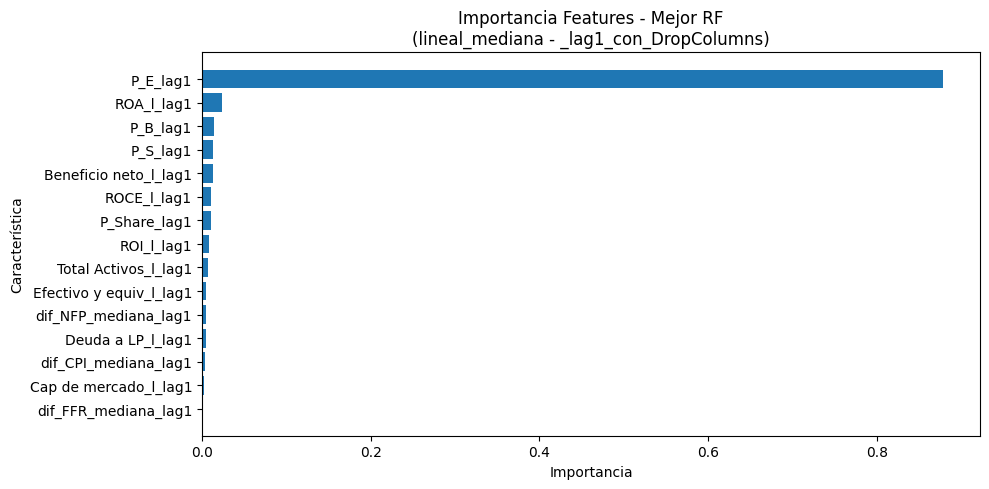

  Mejor XGB para lineal_mediana: RMSE = 4.0146
    Generando importancia de features para Mejor XGB de lineal_mediana...


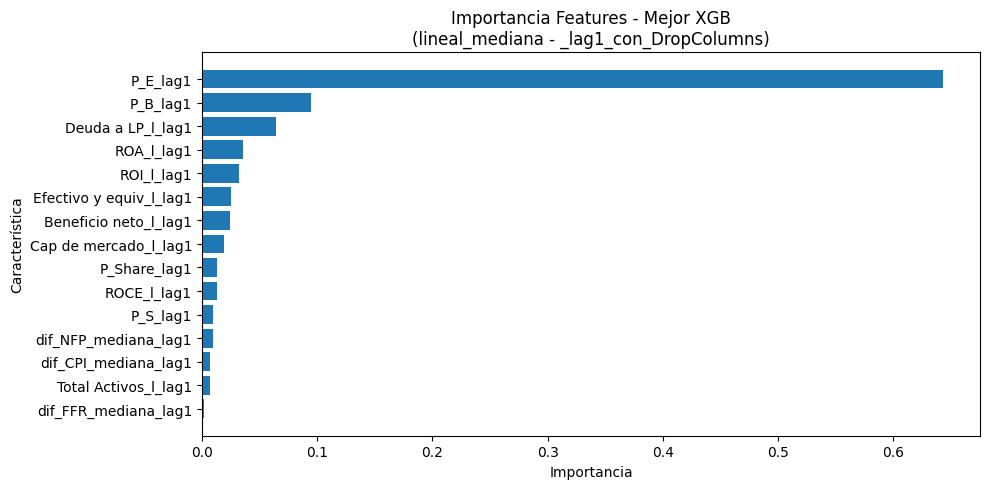

  Mejor LGBM para lineal_mediana: RMSE = 2.7155
    Generando importancia de features para Mejor LGBM de lineal_mediana...


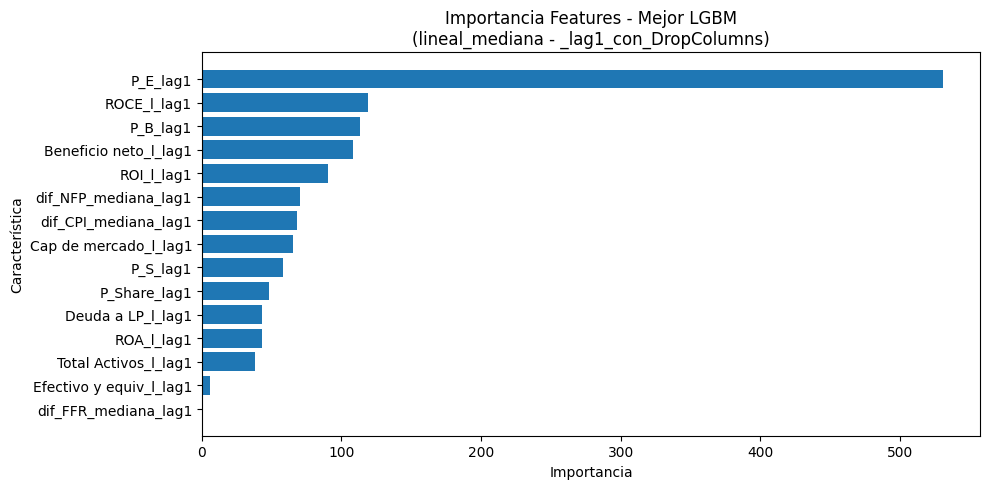

  Mejor CB para lineal_mediana: RMSE = 3.9783
    Generando importancia de features para Mejor CB de lineal_mediana...


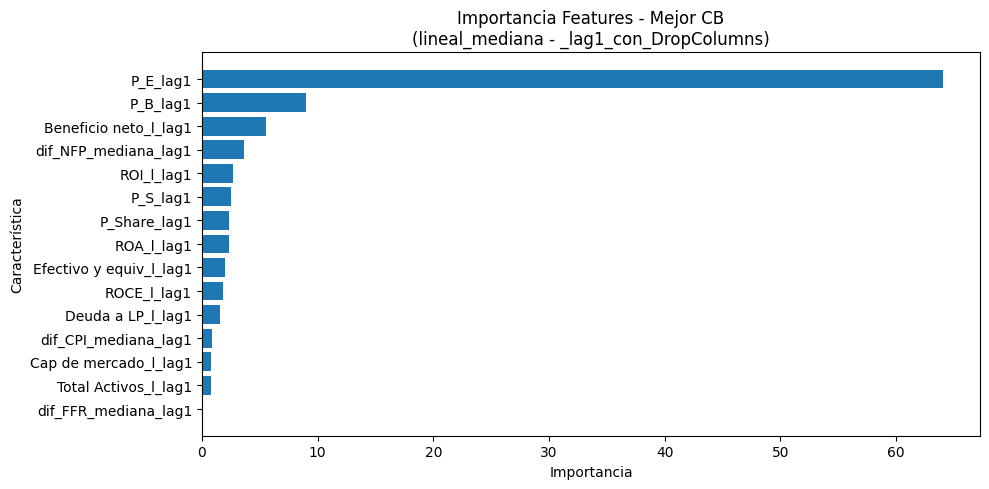


Paquete para 'lineal_mediana' guardado como: paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: spline_mediana ---
  Mejor RF para spline_mediana: RMSE = 3.5711
    Generando importancia de features para Mejor RF de spline_mediana...


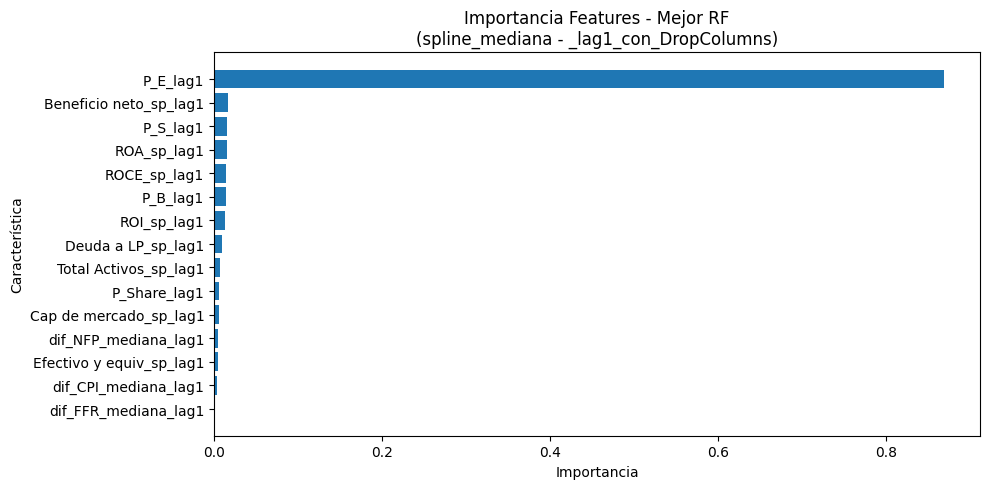

  Mejor XGB para spline_mediana: RMSE = 4.2047
    Generando importancia de features para Mejor XGB de spline_mediana...


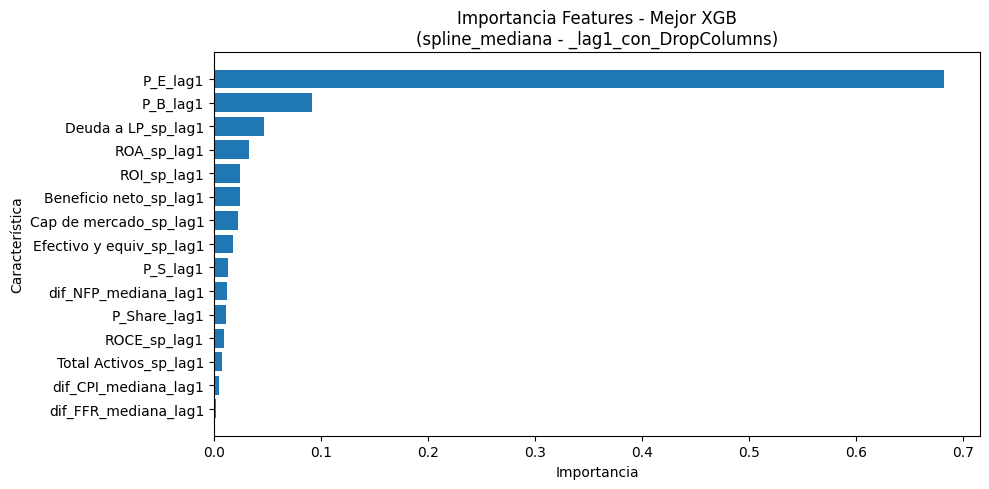

  Mejor LGBM para spline_mediana: RMSE = 2.7811
    Generando importancia de features para Mejor LGBM de spline_mediana...


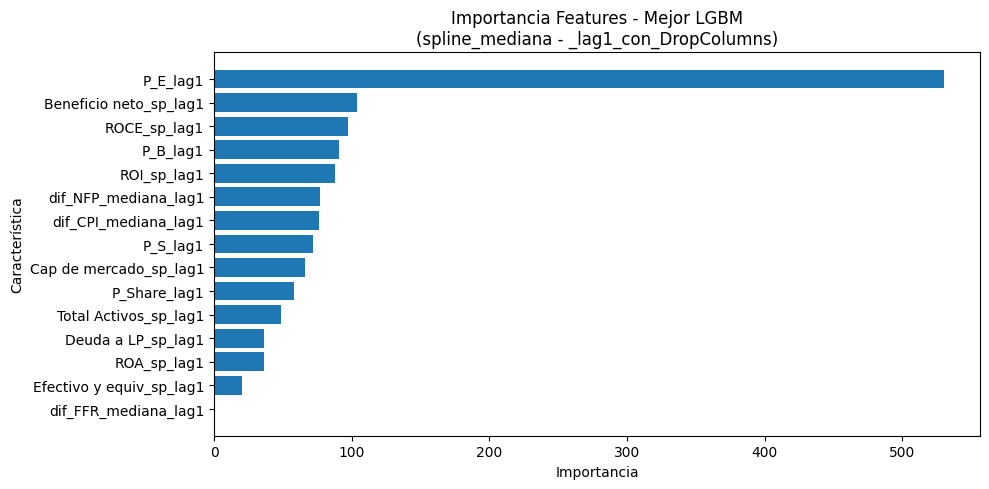

  Mejor CB para spline_mediana: RMSE = 3.1626
    Generando importancia de features para Mejor CB de spline_mediana...


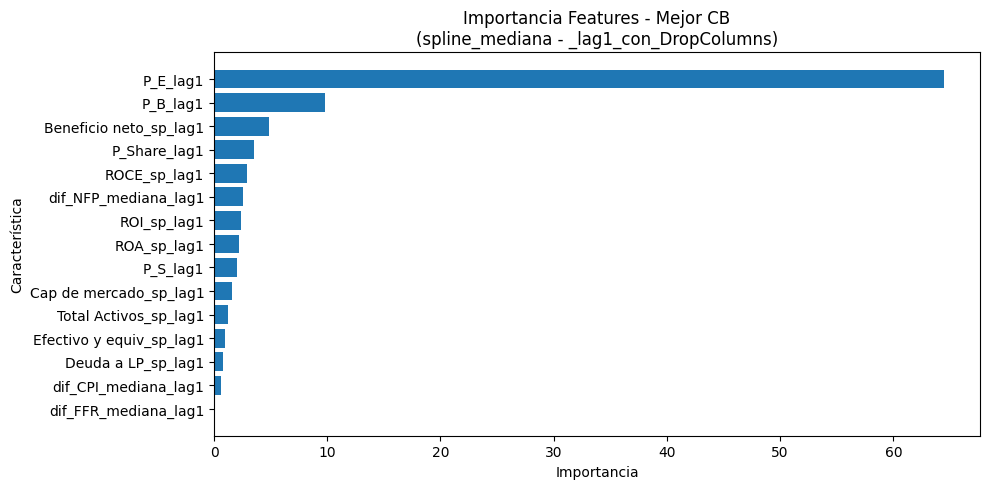


Paquete para 'spline_mediana' guardado como: paquete_mejores_por_tipo_spline_mediana__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: lineal_promedio ---
  Mejor RF para lineal_promedio: RMSE = 3.5620
    Generando importancia de features para Mejor RF de lineal_promedio...


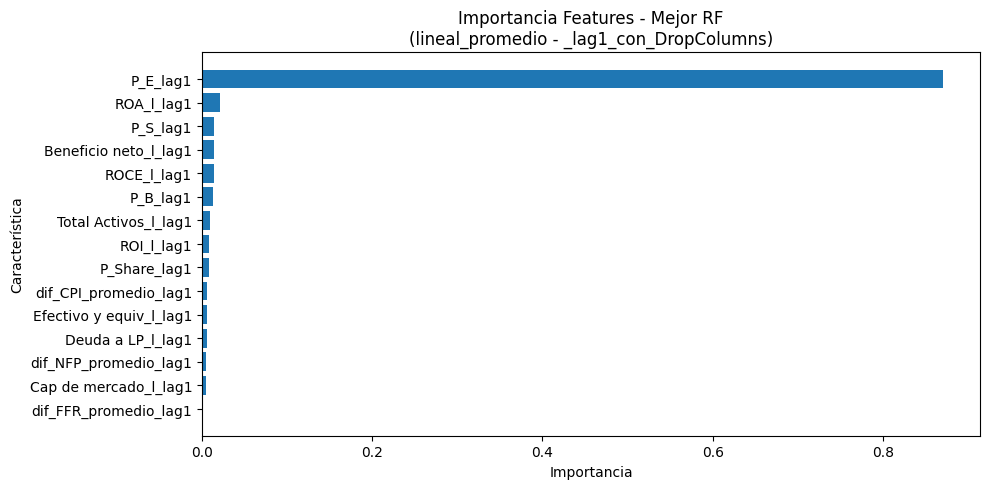

  Mejor XGB para lineal_promedio: RMSE = 3.9404
    Generando importancia de features para Mejor XGB de lineal_promedio...


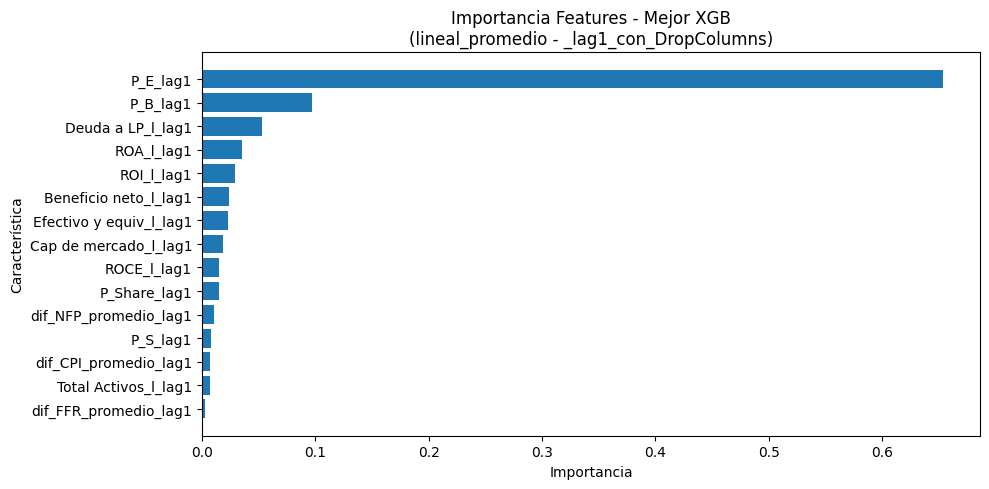

  Mejor LGBM para lineal_promedio: RMSE = 2.8411
    Generando importancia de features para Mejor LGBM de lineal_promedio...


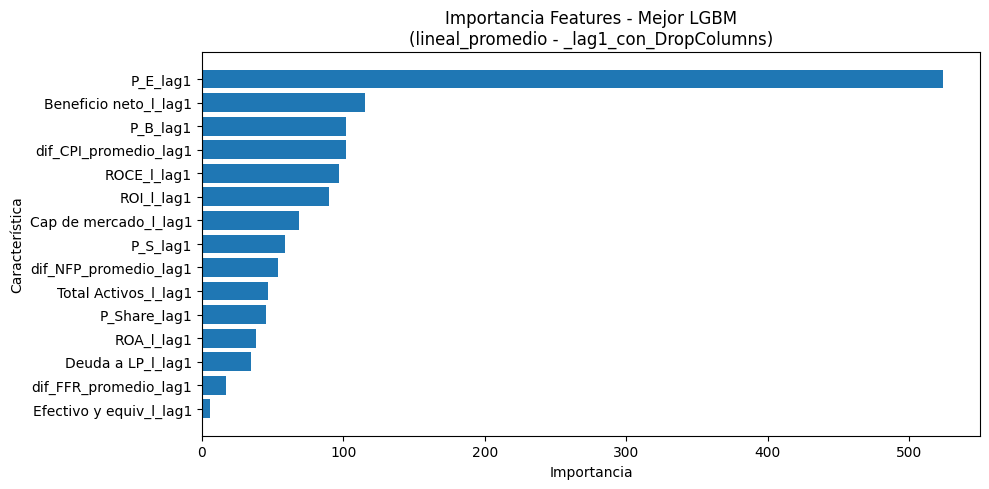

  Mejor CB para lineal_promedio: RMSE = 3.7963
    Generando importancia de features para Mejor CB de lineal_promedio...


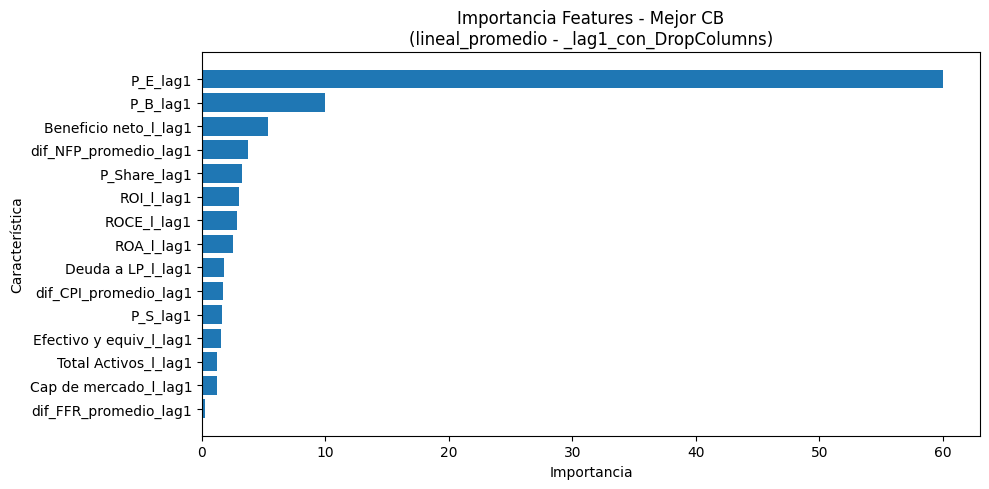


Paquete para 'lineal_promedio' guardado como: paquete_mejores_por_tipo_lineal_promedio__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: spline_promedio ---
  Mejor RF para spline_promedio: RMSE = 3.4467
    Generando importancia de features para Mejor RF de spline_promedio...


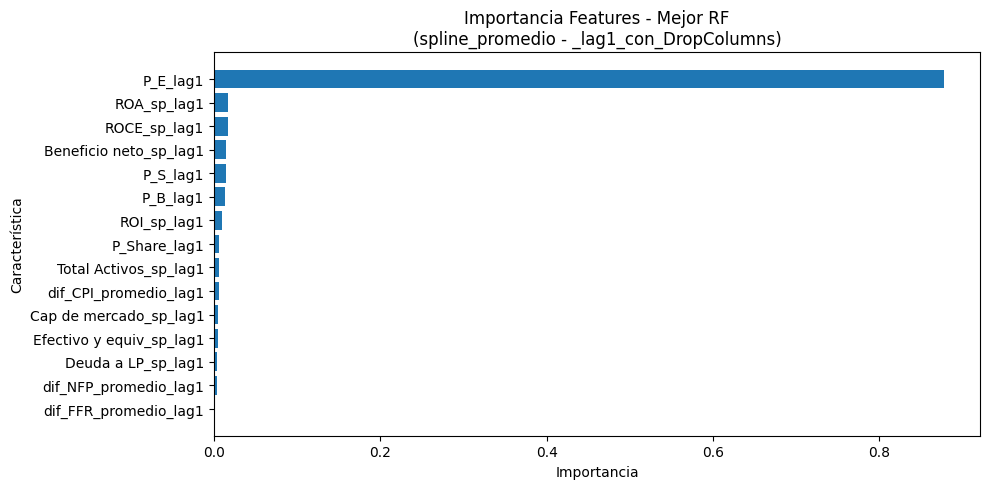

  Mejor XGB para spline_promedio: RMSE = 4.1606
    Generando importancia de features para Mejor XGB de spline_promedio...


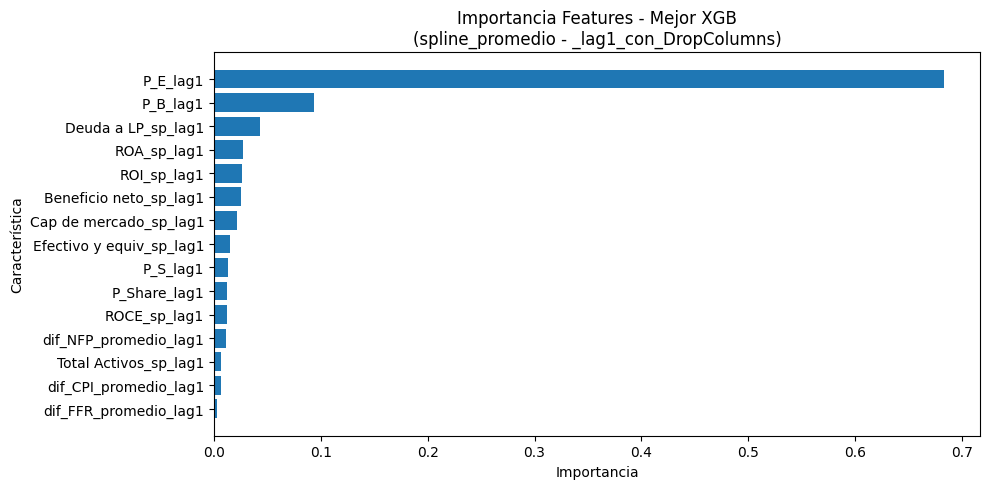

  Mejor LGBM para spline_promedio: RMSE = 2.9726
    Generando importancia de features para Mejor LGBM de spline_promedio...


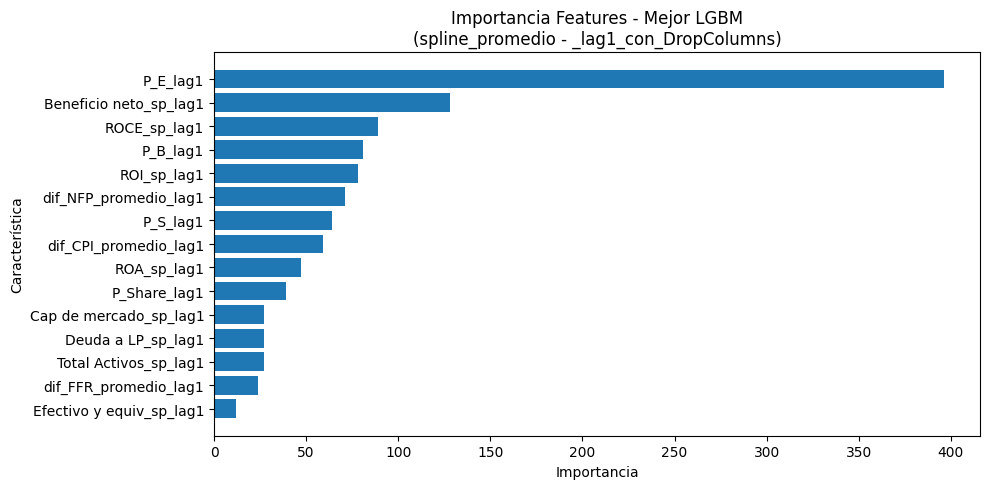

  Mejor CB para spline_promedio: RMSE = 3.3057
    Generando importancia de features para Mejor CB de spline_promedio...


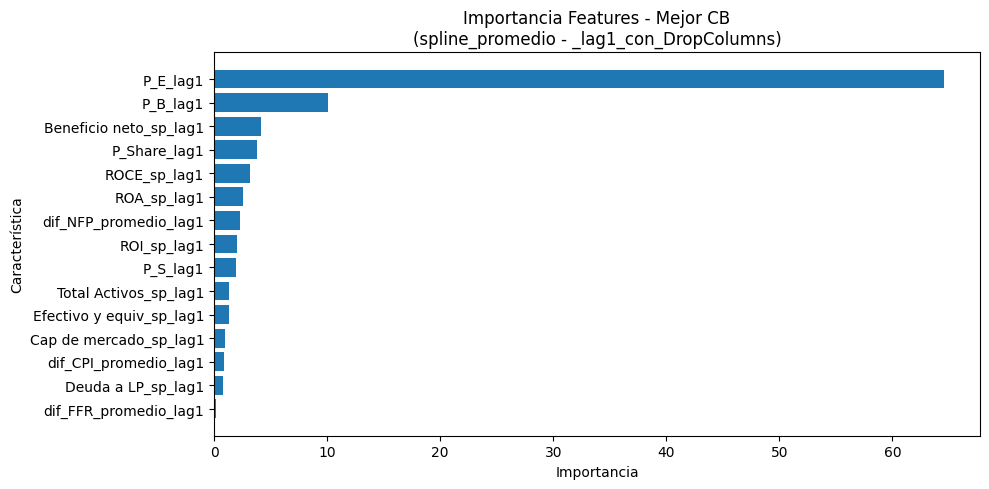


Paquete para 'spline_promedio' guardado como: paquete_mejores_por_tipo_spline_promedio__lag1_con_DropColumns.joblib

TABLA RESUMEN DE LOS MEJORES MODELOS POR TIPO
Metodo_Features            Lag_Config  Log_Transform Modelo_Tipo_Base   RMSE    MAE     R2  n_features_modelo                                                                                                Best_Params
 lineal_mediana _lag1_con_DropColumns          False             LGBM 2.7155 1.5322 0.9553                 15 {'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 100, 'model__num_leaves': 15}
 lineal_mediana _lag1_con_DropColumns          False               RF 3.6087 1.6297 0.9211                 15                        {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 100}
 lineal_mediana _lag1_con_DropColumns          False               CB 3.9783 1.6818 0.9041                 15        {'model__depth': 7, 'model__iterations': 200, 'model__l2_leaf_reg': 

In [33]:
# ================================================================================
# BLOQUE DE EXPERIMENTOS (CON DropColumns en Pipeline, PLOT FEATURE IMPORTANCE para Mejores por Tipo, GUARDAR PAQUETES)
# ================================================================================
results_accumulator = [] 
start_time_total_experiments = time.time()
use_log_transform_experiment = False
test_size_ratio_experiment = 0.20
LAG_SUFFIX_TO_USE = '_lag1' 

if 'dfs_shifted' not in locals() or not isinstance(dfs_shifted, dict) or not dfs_shifted:
    raise NameError("El diccionario 'dfs_shifted' no está definido o está vacío.")

for metodo_features, df_original_with_lags_and_ids in dfs_shifted.items():
    start_time_metodo = time.time()
    lag_config_display = f"{LAG_SUFFIX_TO_USE}_con_DropColumns" 

    print("\n" + "="*80)
    print(f"Procesando Método: {metodo_features} {'(CON Log Transform)' if use_log_transform_experiment else '(SIN Log Transform)'} (Lags: {LAG_SUFFIX_TO_USE}, con DropColumns)")
    print("="*80 + "\n")

    if df_original_with_lags_and_ids.empty: continue
    df_current_method_processed = df_original_with_lags_and_ids.copy()
    if 'time_step' not in df_current_method_processed.columns:
        df_current_method_processed.sort_values(['Empresa', 'Fecha'], inplace=True)
        df_current_method_processed['time_step'] = df_current_method_processed.groupby('Empresa').cumcount()

    predictor_cols_for_pipeline_input = sorted([
        c for c in df_current_method_processed.columns 
        if c.endswith(LAG_SUFFIX_TO_USE) and c not in ['Empresa', 'Fecha', 'time_step', 'P_E']
    ])
    if not predictor_cols_for_pipeline_input: continue
    columnas_base_que_generaron_lags = sorted(list(set(re.sub(r'_lag\d+$', '', lag_col) for lag_col in predictor_cols_for_pipeline_input)))
    
    all_relevant_cols_for_df = ['Empresa', 'Fecha', 'time_step', 'P_E'] + predictor_cols_for_pipeline_input
    final_cols_for_df_model_construction = sorted(list(set(c for c in all_relevant_cols_for_df if c in df_current_method_processed.columns)))
    essential_cols_check = ['Empresa', 'Fecha', 'time_step', 'P_E']
    if not all(ec in final_cols_for_df_model_construction for ec in essential_cols_check): continue
    df_model_for_splitting = df_current_method_processed[final_cols_for_df_model_construction].copy()

    n_total_empresas = df_model_for_splitting['Empresa'].nunique()
    n_empresas_test = 0
    if n_total_empresas > 1:
        n_empresas_test = max(1, int(round(n_total_empresas * test_size_ratio_experiment)))
        if n_total_empresas - n_empresas_test < 1 : n_empresas_test = n_total_empresas - 1
    X_train_with_ids, y_train_original, X_test_with_ids, y_test_original = train_test_split_by_empresa(df_model_for_splitting, n_empresas_test)
    if X_train_with_ids is None or X_train_with_ids.empty: continue
    
    y_train_transformed_target = y_train_original.copy()
    if use_log_transform_experiment:
        y_numeric = pd.to_numeric(y_train_original, errors='coerce')
        median_y_train = y_numeric.median() if not y_numeric.isnull().all() else 0.0
        y_numeric = y_numeric.fillna(median_y_train); y_numeric.loc[y_numeric < 0] = 0
        y_train_transformed_target = np.log1p(y_numeric)
        if y_train_transformed_target.isnull().any():
             median_y_transformed = y_train_transformed_target.median() if not y_train_transformed_target.isnull().all() else 0.0
             y_train_transformed_target = y_train_transformed_target.fillna(median_y_transformed)

    if not X_train_with_ids.index.equals(y_train_transformed_target.index):
        common_idx_train = X_train_with_ids.index.intersection(y_train_transformed_target.index)
        X_train_with_ids = X_train_with_ids.loc[common_idx_train]
        y_train_transformed_target = y_train_transformed_target.loc[common_idx_train]
        if X_train_with_ids.empty : continue

    X_train_s_with_ids, y_train_s_transformed = sort_by_timestep(X_train_with_ids, y_train_transformed_target)
    X_test_s_with_ids, y_test_s_original = pd.DataFrame(), pd.Series(dtype=float)
    if X_test_with_ids is not None and not X_test_with_ids.empty:
        X_test_s_with_ids, y_test_s_original = sort_by_timestep(X_test_with_ids, y_test_original)

    param_grid_rf   = {'model__max_depth':[10, 20, None],'model__min_samples_split':[5, 10],'model__n_estimators':[100, 200]}
    param_grid_xgb  = {'model__n_estimators':[100, 200],'model__max_depth':[3, 5, 7],'model__learning_rate':[0.1, 0.05]}
    param_grid_lgbm = {'model__n_estimators':[100, 200],'model__learning_rate':[0.1, 0.05],'model__max_depth':[3, 5, 7],'model__num_leaves':[15, 31]}
    param_grid_cb   = {'model__iterations':[100, 200],'model__learning_rate':[0.1, 0.05],'model__depth':[3, 5, 7],'model__l2_leaf_reg':[1, 3]}
    scenarios = {
        'RF_Simple':  {'model': RandomForestRegressor(random_state=42, n_jobs=-1), 'hp': False, 'vt': False, 'grid': param_grid_rf},
        'RF_HP':      {'model': RandomForestRegressor(random_state=42, n_jobs=-1), 'hp': True,  'vt': False, 'grid': param_grid_rf},
        'XGB_Simple': {'model': XGBRegressor(random_state=42, n_jobs=-1), 'hp': False, 'vt': False, 'grid': param_grid_xgb},
        'XGB_HP':     {'model': XGBRegressor(random_state=42, n_jobs=-1), 'hp': True,  'vt': False, 'grid': param_grid_xgb},
        'LGBM_Simple':{'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1), 'hp': False, 'vt': False, 'grid': param_grid_lgbm},
        'LGBM_HP':    {'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1), 'hp': True,  'vt': False, 'grid': param_grid_lgbm},
        'CB_Simple':  {'model': CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False), 'hp': False, 'vt': False, 'grid': param_grid_cb},
        'CB_HP':      {'model': CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False), 'hp': True,  'vt': False, 'grid': param_grid_cb},
    }

    for escenario_nombre, escenario_cfg in scenarios.items():
        tiempo_esc_inicio = time.time()
        current_base_model = escenario_cfg['model']; perform_hp_search = escenario_cfg['hp']; use_temporal_cv_in_scenario = escenario_cfg.get('vt', False)
        X_fit_data_pipeline = X_train_s_with_ids if use_temporal_cv_in_scenario else X_train_with_ids
        y_fit_data_pipeline = y_train_s_transformed if use_temporal_cv_in_scenario else y_train_transformed_target
        X_eval_data_pipeline = X_test_s_with_ids if use_temporal_cv_in_scenario else X_test_with_ids
        y_eval_data_original_final = y_test_s_original if use_temporal_cv_in_scenario else y_test_original
        if X_fit_data_pipeline.empty or y_fit_data_pipeline.empty:
            results_accumulator.append({'Modelo': escenario_nombre.split('_')[0], 'Validacion_Temp': use_temporal_cv_in_scenario,
                'Busqueda_HP': perform_hp_search, 'Config_Key': metodo_features, 'Metodo': metodo_features,
                'Lag_Config': lag_config_display, 'Log_Transform': use_log_transform_experiment, 'RMSE': np.nan, 'MAE': np.nan, 
                'R2': np.nan, 'Best_Params': None, 'pipeline': 'Error: Datos vacíos', 
                'columnas_base_usadas': columnas_base_que_generaron_lags, 
                'n_features_modelo': len(predictor_cols_after_drop), 
                'features_usadas_por_modelo': [], 'Error': 'Datos vacíos'})
            continue
        cols_to_drop_in_pipeline = [col for col in ['Empresa', 'Fecha', 'time_step'] if col in X_fit_data_pipeline.columns]
        pipeline_obj_for_training = Pipeline([('drop_ids', DropColumns(columns=cols_to_drop_in_pipeline)), ('model', current_base_model)])
        model_actual_features_for_plot = [col for col in X_fit_data_pipeline.columns if col not in cols_to_drop_in_pipeline]
        final_fitted_pipeline, hp_best_params_found, error_msg_escenario = None, None, None
        try:
            if perform_hp_search:
                cv_strategy_obj, cv_fit_params_dict, can_perform_cv = None, {}, True
                n_groups_for_cv = X_fit_data_pipeline['Empresa'].nunique() if use_temporal_cv_in_scenario and 'Empresa' in X_fit_data_pipeline.columns else 0
                if use_temporal_cv_in_scenario and n_groups_for_cv >= 2:
                    groups_for_gkf = X_fit_data_pipeline['Empresa']; n_splits_gkf = min(3, n_groups_for_cv); n_splits_gkf = max(2, n_splits_gkf)
                    if len(X_fit_data_pipeline) < n_splits_gkf : can_perform_cv = False
                    else: cv_strategy_obj = GroupKFold(n_splits=n_splits_gkf); cv_fit_params_dict = {'groups': groups_for_gkf}
                elif len(X_fit_data_pipeline) >= 2:
                    n_samples_kf = len(X_fit_data_pipeline); kfold_splits_val = min(3, n_samples_kf); kfold_splits_val = max(2, kfold_splits_val)
                    if n_samples_kf < kfold_splits_val : can_perform_cv = False
                    else: cv_strategy_obj = KFold(n_splits=kfold_splits_val, shuffle=True, random_state=42)
                else: can_perform_cv = False
                if not can_perform_cv or cv_strategy_obj is None: perform_hp_search = False
                if perform_hp_search:
                    gs = GridSearchCV(pipeline_obj_for_training, escenario_cfg['grid'], scoring=rmse_scorer, cv=cv_strategy_obj, n_jobs=-1, refit=True, error_score='raise', verbose=0)
                    gs.fit(X_fit_data_pipeline, y_fit_data_pipeline, **cv_fit_params_dict)
                    final_fitted_pipeline, hp_best_params_found = gs.best_estimator_, gs.best_params_
            if not perform_hp_search or final_fitted_pipeline is None:
                pipeline_obj_for_training.fit(X_fit_data_pipeline, y_fit_data_pipeline)
                final_fitted_pipeline = pipeline_obj_for_training; hp_best_params_found = None
        except Exception as e: error_msg_escenario = str(e)
        eval_metrics_dict, n_features_in_final_model_attr = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}, "N/A"
        if final_fitted_pipeline:
            try:
                actual_estimator = final_fitted_pipeline.steps[-1][1]
                n_features_in_final_model_attr = getattr(actual_estimator, 'n_features_in_', "N/A")
                if not X_eval_data_pipeline.empty and not y_eval_data_original_final.empty:
                    pred_transformed_eval = final_fitted_pipeline.predict(X_eval_data_pipeline)
                    pred_original_scale_eval = np.expm1(pred_transformed_eval) if use_log_transform_experiment else pred_transformed_eval
                    if use_log_transform_experiment: pred_original_scale_eval[~np.isfinite(pred_original_scale_eval)] = np.nan
                    eval_metrics_dict = evaluate_model(y_eval_data_original_final, pred_original_scale_eval)
                    print(f"    Métricas Test {escenario_nombre}: RMSE={eval_metrics_dict['RMSE']:.4f}, MAE={eval_metrics_dict['MAE']:.4f}, R2={eval_metrics_dict['R2']:.4f}")
                # NO PLOTEAMOS AQUÍ, LO HAREMOS AL FINAL PARA LOS MEJORES POR TIPO
            except Exception as e_eval: error_msg_escenario = (error_msg_escenario + f" | EvalError: {str(e_eval)}") if error_msg_escenario else f"EvalError: {str(e_eval)}"
        
        results_accumulator.append({
            'Modelo': escenario_nombre.split('_')[0], 'Validacion_Temp': use_temporal_cv_in_scenario and isinstance(cv_strategy_obj, GroupKFold),
            'Busqueda_HP': escenario_cfg['hp'] and perform_hp_search, 
            'Config_Key': metodo_features, 'Metodo': metodo_features, 
            'Lag_Config': lag_config_display, 
            'Log_Transform': use_log_transform_experiment, 
            'RMSE': eval_metrics_dict['RMSE'], 'MAE': eval_metrics_dict['MAE'], 'R2': eval_metrics_dict['R2'], 
            'Best_Params': hp_best_params_found, 
            'pipeline': final_fitted_pipeline, 
            'columnas_base_usadas': columnas_base_que_generaron_lags, 
            'n_features_modelo': n_features_in_final_model_attr, 
            'features_usadas_por_modelo': model_actual_features_for_plot, # Guardar las features que vio el estimador
            'Error': error_msg_escenario
        })
    print(f"\nTiempo total para Método: {metodo_features}: {time.time() - start_time_metodo:.2f}s")
print(f"\n\nTiempo total de ejecución de todos los experimentos: {(time.time() - start_time_total_experiments)/60:.2f} minutos")

# ================================================================================
# CREAR TABLA DE RESULTADOS GENERAL, GUARDAR PAQUETES Y PLOTEAR MEJORES POR TIPO
# ================================================================================
if results_accumulator:
    df_results_all_experiments = pd.DataFrame(results_accumulator)
    print("\n" + "="*80 + "\n--- Resultados Finales Globales ---\n" + f"Total resultados: {len(df_results_all_experiments)}\n")
    cols_to_display_summary = ['Metodo', 'Modelo', 'Busqueda_HP', 'RMSE', 'MAE', 'R2', 'n_features_modelo', 'Lag_Config', 'Error', 'Best_Params'] # Quitado 'features_usadas_por_modelo' para brevedad
    final_cols_to_display_summary = [col for col in cols_to_display_summary if col in df_results_all_experiments.columns]
    with pd.option_context('display.max_rows', 200, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
        print(df_results_all_experiments.sort_values(by=['Metodo','RMSE'], ascending=[True,True])[final_cols_to_display_summary].to_string(index=False))

    lista_info_mejores_por_tipo_global = []
    for metodo_actual_features_key in df_results_all_experiments['Metodo'].unique(): 
        print("\n" + "="*70 + f"\n--- Preparando paquete y plots para Método: {metodo_actual_features_key} ---")
        df_resultados_metodo_actual = df_results_all_experiments[
            (df_results_all_experiments['Metodo'] == metodo_actual_features_key) &
            (df_results_all_experiments['RMSE'].notna()) &
            (df_results_all_experiments['pipeline'].notna()) & 
            (df_results_all_experiments['Error'].isna()) &
            (df_results_all_experiments['pipeline'].apply(lambda x: not (isinstance(x, str) and x.startswith('Error:')))) & # Asegurar que pipeline no sea string de error
            (df_results_all_experiments['features_usadas_por_modelo'].apply(lambda x: isinstance(x, list) and len(x) > 0)) # Asegurar que hay features
        ].copy()

        if df_resultados_metodo_actual.empty: 
            print(f"No hay resultados válidos con features para el método '{metodo_actual_features_key}' para crear paquete o plotear.")
            continue

        mejores_modelos_info_para_paquete = {}
        modelos_base_a_considerar = ['RF', 'XGB', 'LGBM', 'CB']
        
        metadata_ref_row = df_resultados_metodo_actual.iloc[0]
        log_transform_paquete_actual = metadata_ref_row.get('Log_Transform', True)
        columnas_base_paquete_actual = metadata_ref_row.get('columnas_base_usadas', []) 
        lag_config_paquete_actual = metadata_ref_row.get('Lag_Config', 'desconocida')
        
        for tipo_modelo_base in modelos_base_a_considerar:
            df_tipo_especifico = df_resultados_metodo_actual[df_resultados_metodo_actual['Modelo'] == tipo_modelo_base]
            if not df_tipo_especifico.empty:
                mejor_fila_tipo_actual = df_tipo_especifico.sort_values(by='RMSE', ascending=True).iloc[0]
                
                pipeline_obj_actual = mejor_fila_tipo_actual['pipeline']
                features_usadas_actual = mejor_fila_tipo_actual['features_usadas_por_modelo']

                mejores_modelos_info_para_paquete[tipo_modelo_base] = {
                    'pipeline_object': pipeline_obj_actual,
                    'RMSE': mejor_fila_tipo_actual['RMSE'], 'MAE': mejor_fila_tipo_actual['MAE'],
                    'R2': mejor_fila_tipo_actual['R2'], 'Best_Params': mejor_fila_tipo_actual['Best_Params'],
                    'n_features_modelo': mejor_fila_tipo_actual['n_features_modelo'],
                    'features_usadas_por_modelo': features_usadas_actual, 
                    'Escenario_Validacion_Temp': mejor_fila_tipo_actual['Validacion_Temp'],
                    'Escenario_Busqueda_HP': mejor_fila_tipo_actual['Busqueda_HP']}
                
                print(f"  Mejor {tipo_modelo_base} para {metodo_actual_features_key}: RMSE = {mejor_fila_tipo_actual['RMSE']:.4f}")

                # --- PLOT FEATURE IMPORTANCE PARA ESTE MEJOR MODELO POR TIPO ---
                titulo_plot_tipo = (
                    f"Importancia Features - Mejor {tipo_modelo_base}\n"
                    f"({metodo_actual_features_key} - {lag_config_paquete_actual})"
                )
                print(f"    Generando importancia de features para Mejor {tipo_modelo_base} de {metodo_actual_features_key}...")
                plot_feature_importances(
                    pipeline_obj_actual, # El pipeline completo (DropColumns + modelo)
                    feature_names=features_usadas_actual, # Las features que vio el estimador final
                    title=titulo_plot_tipo
                )
                # --- FIN PLOT ---

                info_para_tabla_resumen = {
                    'Metodo_Features': metodo_actual_features_key, 
                    'Lag_Config': lag_config_paquete_actual,
                    'Log_Transform': log_transform_paquete_actual, 
                    'Modelo_Tipo_Base': tipo_modelo_base,
                    'RMSE': mejor_fila_tipo_actual['RMSE'], 'MAE': mejor_fila_tipo_actual['MAE'],
                    'R2': mejor_fila_tipo_actual['R2'], 'n_features_modelo': mejor_fila_tipo_actual['n_features_modelo'],
                    'Best_Params': mejor_fila_tipo_actual['Best_Params']}
                lista_info_mejores_por_tipo_global.append(info_para_tabla_resumen)
            else: 
                mejores_modelos_info_para_paquete[tipo_modelo_base] = None 

        if any(mejores_modelos_info_para_paquete.values()):
            paquete_final_a_guardar = {
                'metodo_features': metodo_actual_features_key, 
                'lag_config_usada': lag_config_paquete_actual,
                'log_transform_target': log_transform_paquete_actual,
                'columnas_base_para_lags': columnas_base_paquete_actual, 
                'mejores_modelos_info_por_tipo': mejores_modelos_info_para_paquete
            }
            nombre_archivo_paquete_final = f"paquete_mejores_por_tipo_{metodo_actual_features_key.replace(' ', '_')}_{lag_config_paquete_actual}.joblib"
            try:
                joblib.dump(paquete_final_a_guardar, nombre_archivo_paquete_final)
                print(f"\nPaquete para '{metodo_actual_features_key}' guardado como: {nombre_archivo_paquete_final}")
            except Exception as e_dump_final_package: print(f"\nERROR al guardar paquete para '{metodo_actual_features_key}': {e_dump_final_package}")
    
    if lista_info_mejores_por_tipo_global:
        df_mejores_por_tipo_global = pd.DataFrame(lista_info_mejores_por_tipo_global)
        print("\n" + "="*80 + "\nTABLA RESUMEN DE LOS MEJORES MODELOS POR TIPO" + "\n" + "="*80)
        with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
            cols_resumen_mejores = ['Metodo_Features', 'Lag_Config', 'Log_Transform', 'Modelo_Tipo_Base', 'RMSE', 'MAE', 'R2', 'n_features_modelo', 'Best_Params']
            cols_resumen_existentes = [col for col in cols_resumen_mejores if col in df_mejores_por_tipo_global.columns]
            print(df_mejores_por_tipo_global.sort_values(by=['Metodo_Features', 'RMSE'], ascending=[True, True])[cols_resumen_existentes].to_string(index=False))
else: 
    print("\nNo se generaron resultados en los experimentos.")

In [34]:
df_mejores_por_tipo_global.sort_values(by=["R2"], ascending=False)

,Metodo_Features,Lag_Config,Log_Transform,Modelo_Tipo_Base,RMSE,MAE,R2,n_features_modelo,Best_Params
2,lineal_mediana,_lag1_con_DropColumns,False,LGBM,2.715526,1.532192,0.955324,15,"{'model__learning_rate': 0.05, 'model__max_dep..."
6,spline_mediana,_lag1_con_DropColumns,False,LGBM,2.781068,1.551305,0.953141,15,"{'model__learning_rate': 0.05, 'model__max_dep..."
10,lineal_promedio,_lag1_con_DropColumns,False,LGBM,2.841114,1.548612,0.951096,15,"{'model__learning_rate': 0.05, 'model__max_dep..."
14,spline_promedio,_lag1_con_DropColumns,False,LGBM,2.972645,1.529580,0.946463,15,"{'model__learning_rate': 0.05, 'model__max_dep..."
7,spline_mediana,_lag1_con_DropColumns,False,CB,3.162580,1.638752,0.939403,15,"{'model__depth': 7, 'model__iterations': 200, ..."
15,spline_promedio,_lag1_con_DropColumns,False,CB,3.305679,1.642723,0.933795,15,"{'model__depth': 7, 'model__iterations': 200, ..."
12,spline_promedio,_lag1_con_DropColumns,False,RF,3.446678,1.558992,0.928027,15,"{'model__max_depth': 20, 'model__min_samples_s..."
8,lineal_promedio,_lag1_con_DropColumns,False,RF,3.561955,1.587906,0.923132,15,None
4,spline_mediana,_lag1_con_DropColumns,False,RF,3.571119,1.600748,0.922736,15,None
0,lineal_mediana,_lag1_con_DropColumns,False,RF,3.608659,1.629668,0.921103,15,"{'model__max_depth': 20, 'model__min_samples_s..."


In [35]:
# Celda: BLOQUE DE PREDICCIÓN PARA DLOCAL (MODELOS INDIVIDUALES - GRÁFICOS Y MÉTRICAS)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import joblib
import os
import re # Para la lógica de extracción de lags

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# --- Definiciones de Clases y Funciones Auxiliares ---
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None): self.columns = columns if columns is not None else []
    def fit(self, X, y=None): return self
    def transform(self, X):
        if not isinstance(X, pd.DataFrame): return X
        return X.copy().drop(columns=self.columns, errors='ignore')

def rmse(y_true, y_pred):
    y_true_np, y_pred_np = np.asarray(y_true), np.asarray(y_pred)
    mask = np.isfinite(y_true_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_true_np, y_pred_np = y_true_np[mask], y_pred_np[mask]
    if len(y_true_np) == 0: return np.nan
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

def evaluate_model(y_test, y_pred):
    y_test_np, y_pred_np = np.asarray(y_test), np.asarray(y_pred)
    mask = np.isfinite(y_test_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_test_np, y_pred_np = y_test_np[mask], y_pred_np[mask]
    if len(y_test_np) == 0: return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
    mae = mean_absolute_error(y_test_np, y_pred_np); rmse_val = rmse(y_test_np, y_pred_np)
    r2 = np.nan
    if len(y_test_np) > 1 and np.var(y_test_np) > 1e-9:
        try: r2 = r2_score(y_test_np, y_pred_np)
        except ValueError: pass
    elif len(y_test_np) > 0 and mean_squared_error(y_test_np, y_pred_np) < 1e-9: r2 = 1.0
    elif len(y_test_np) > 0: r2 = 0.0
    return {'RMSE': rmse_val, 'MAE': mae, 'R2': r2}

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

Cargando paquete de modelos desde: paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib
Paquete de modelos cargado exitosamente.
  Información del Paquete: Método=lineal_mediana, LagConfig=_lag1_con_DropColumns, LogT=False
    Columnas Base (usadas para generar lags): 15 ['Beneficio neto_l', 'Cap de mercado_l', 'Deuda a LP_l', 'Efectivo y equiv_l', 'P_B']...
    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.
Se generarán lags [1] para DLocal.

Preparando datos de DLocal (Método: lineal_mediana, Lags: [1])
Generando lags para DLocal para las features: ['Beneficio neto_l', 'Cap de mercado_l', 'Deuda a LP_l', 'Efectivo y equiv_l', 'P_B', 'P_E', 'P_S', 'P_Share', 'ROA_l', 'ROCE_l', 'ROI_l', 'Total Activos_l', 'dif_CPI_mediana', 'dif_FFR_mediana', 'dif_NFP_mediana']
Se generaron 15 columnas de lag para DLocal: ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
    ¡Confirmado! 

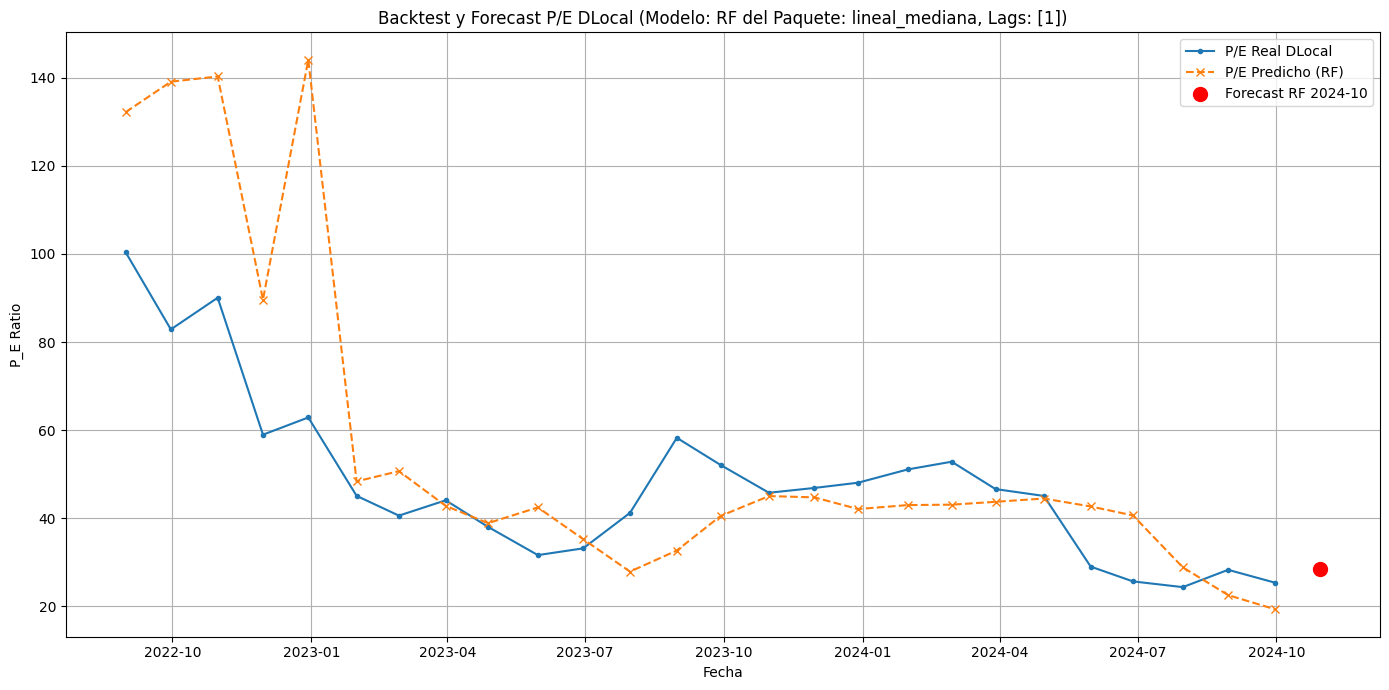


--- Procesando Modelo Tipo: XGB ---
  Features esperadas por XGB (del paquete o inferidas): 15 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
  Métricas Backtest (XGB): RMSE=12.0807, MAE=9.3590, R2=0.5910


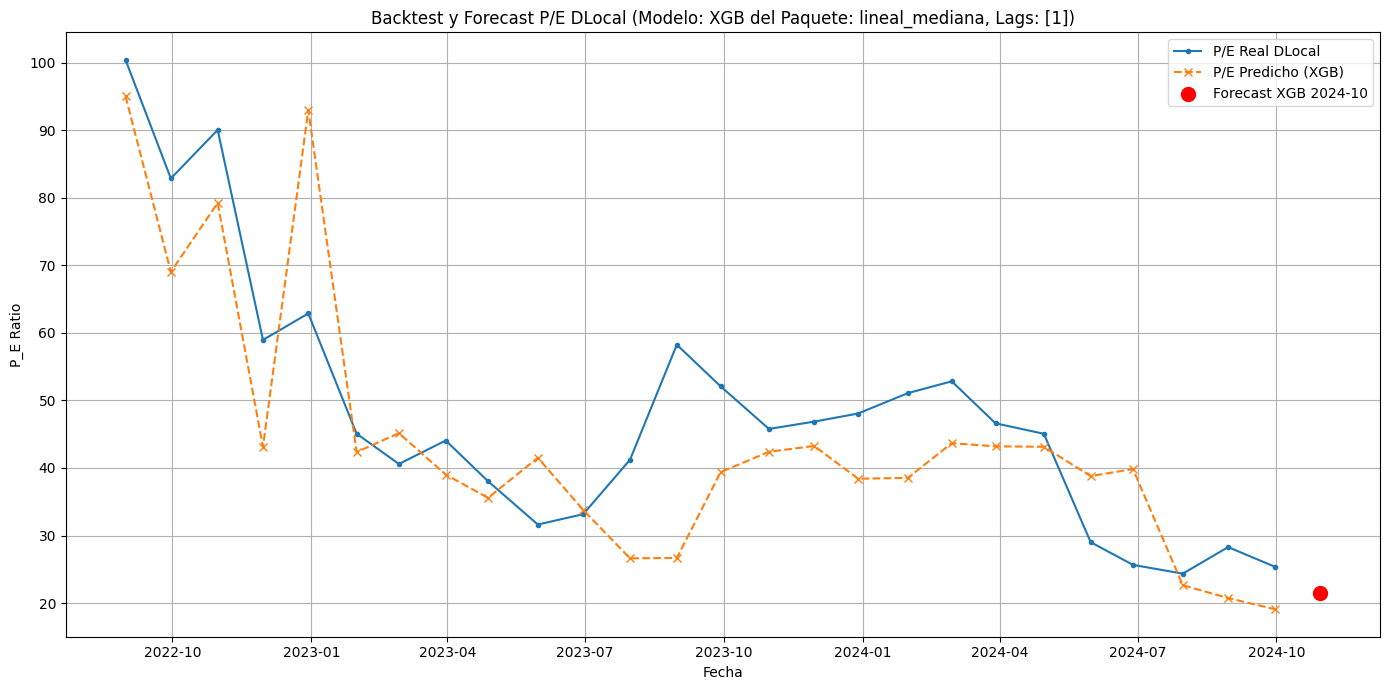


--- Procesando Modelo Tipo: LGBM ---
  Features esperadas por LGBM (del paquete o inferidas): 15 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
  Métricas Backtest (LGBM): RMSE=14.2792, MAE=10.1469, R2=0.4287


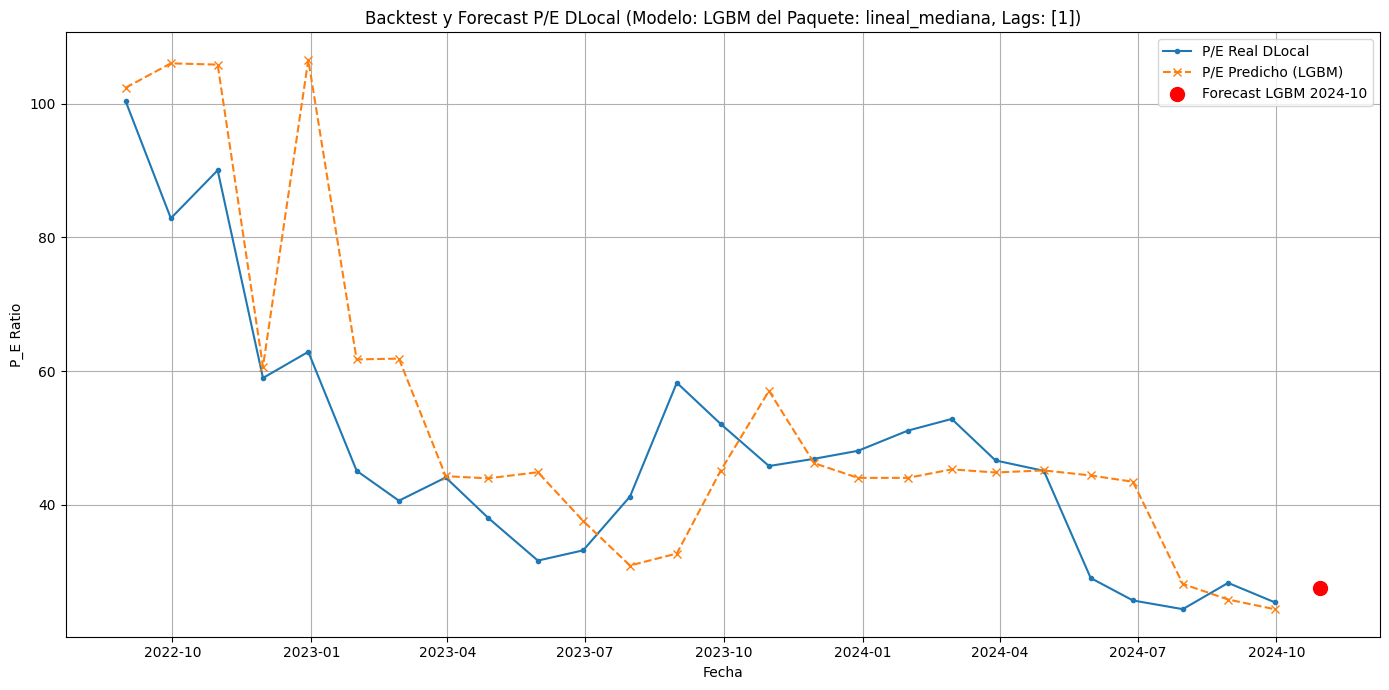


--- Procesando Modelo Tipo: CB ---
  Features esperadas por CB (del paquete o inferidas): 15 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
  Métricas Backtest (CB): RMSE=10.5135, MAE=7.8615, R2=0.6903


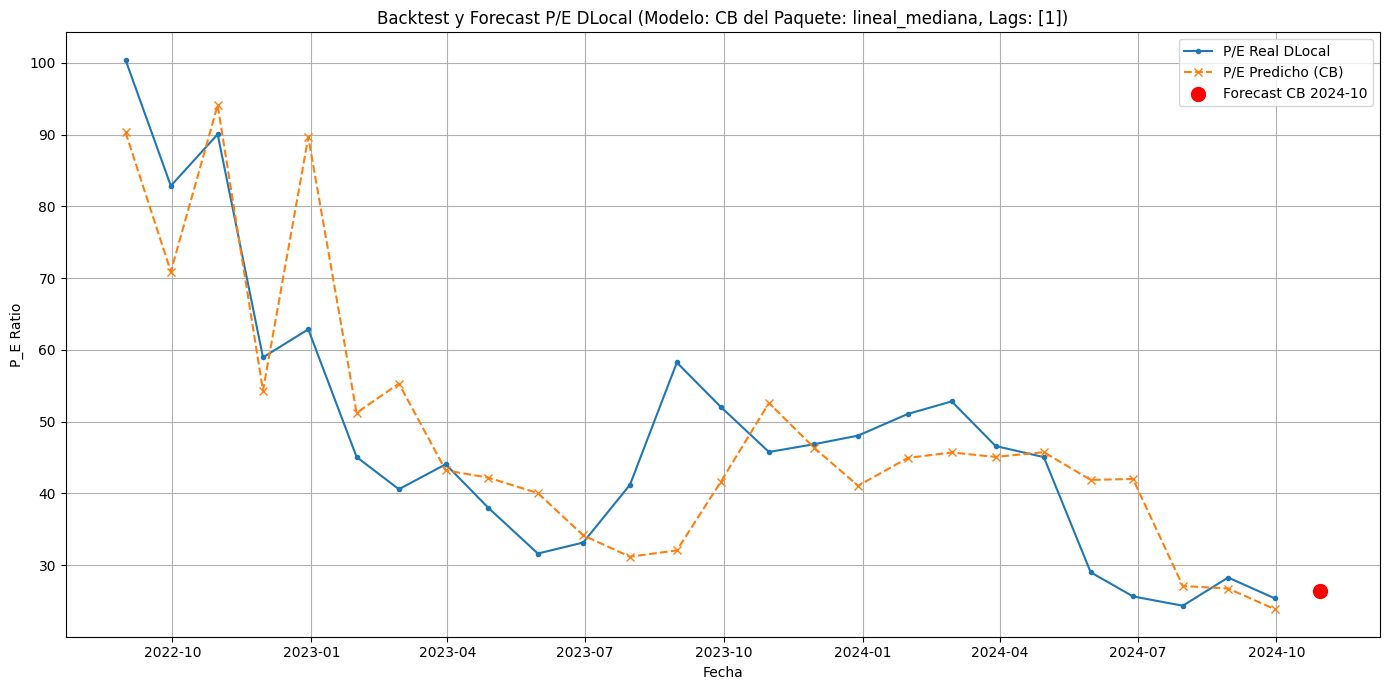


Resumen de Métricas Individuales de los Modelos en el Backtest de DLocal
Modelo_Tipo    RMSE     MAE      R2
         CB 10.5135  7.8615  0.6903
        XGB 12.0807  9.3590  0.5910
       LGBM 14.2792 10.1469  0.4287
         RF 24.9138 15.5401 -0.7393

Proceso de predicción para DLocal completado.


In [36]:
# =====================================================================================
# BLOQUE DE PREDICCIÓN PARA DLOCAL (MODELOS INDIVIDUALES - GRÁFICOS Y MÉTRICAS)
# =====================================================================================

# --- 0. CONFIGURACIÓN Y CARGA DEL PAQUETE DEL MODELO ---
# ASUME: df_dlocal está cargado.
#        listas_columnas está definida (si es necesaria como fallback para columnas_base_paquete).
#        El paquete fue entrenado incluyendo P_E_lagN como feature si se desea usar aquí.

nombre_paquete_a_cargar = "paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib"

print(f"Cargando paquete de modelos desde: {nombre_paquete_a_cargar}")
model_package = None
try:
    ruta_paquete = os.path.join(os.getcwd(), nombre_paquete_a_cargar)
    if not os.path.exists(ruta_paquete):
        raise FileNotFoundError(f"El archivo del paquete '{ruta_paquete}' no existe.")
    model_package = joblib.load(ruta_paquete)
    print("Paquete de modelos cargado exitosamente.")

    required_keys = ['metodo_features', 'lag_config_usada', 'log_transform_target', 'mejores_modelos_info_por_tipo']
    if not isinstance(model_package, dict) or not all(key in model_package for key in required_keys):
        raise ValueError("El archivo cargado no es un paquete de modelos válido o le faltan claves esenciales.")

    metodo_features_paquete = model_package['metodo_features']
    lag_config_paquete = model_package['lag_config_usada'] 
    log_transform_paquete = model_package['log_transform_target']
    columnas_base_paquete = model_package.get('columnas_base_para_lags') # Esta clave debe existir en tu paquete
    mejores_modelos_info = model_package['mejores_modelos_info_por_tipo']

    if not columnas_base_paquete: # Fallback si no está en el paquete
        print("ADVERTENCIA: 'columnas_base_para_lags' no encontrada en el paquete. Intentando usar 'listas_columnas'.")
        if 'listas_columnas' in locals() and metodo_features_paquete in listas_columnas:
            columnas_base_paquete = listas_columnas[metodo_features_paquete]
            # Si P_E_lagN se usó y 'P_E' no está en listas_columnas[metodo_features_paquete], hay que añadirlo:
            # Esta lógica asume que si P_E_lagN es una feature, 'P_E' debe estar en las bases para generar ese lag.
            # El paquete idealmente ya tendría 'P_E' en 'columnas_base_para_lags' si P_E_lagN fue usado.
            # Si el paquete es de "solo lags de P/E", columnas_base_paquete debería ser ['P_E'].
            if 'P_E' not in columnas_base_paquete and any(f.startswith("P_E_lag") for f_dict in mejores_modelos_info.values() if f_dict and 'features_usadas_por_modelo' in f_dict for f in f_dict['features_usadas_por_modelo']):
                 if 'P_E' in df_dlocal.columns:
                    print("Añadiendo 'P_E' a columnas_base_paquete para generar su lag, basado en features de modelos.")
                    columnas_base_paquete.append('P_E')
                    columnas_base_paquete = sorted(list(set(columnas_base_paquete)))
        else: 
            raise ValueError("No se pudieron determinar las 'columnas_base_para_lags' ni del paquete ni de 'listas_columnas'.")
    
    print(f"  Información del Paquete: Método={metodo_features_paquete}, LagConfig={lag_config_paquete}, LogT={log_transform_paquete}")
    print(f"    Columnas Base (usadas para generar lags): {len(columnas_base_paquete)} {columnas_base_paquete[:5]}...")
    if 'P_E' in columnas_base_paquete:
        print("    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.")
    else:
        print("    ADVERTENCIA: 'P_E' NO está en columnas_base_paquete. NO se generará P_E_lagN como feature para DLocal, a menos que lag_config_paquete lo fuerce.")

except FileNotFoundError: raise FileNotFoundError(f"ERROR FATAL: No se encontró el archivo del paquete '{nombre_paquete_a_cargar}'.")
except Exception as e_load_pack: raise RuntimeError(f"Error fatal al cargar o procesar el paquete: {e_load_pack}")

if 'df_dlocal' not in locals() or not isinstance(df_dlocal, pd.DataFrame) or df_dlocal.empty:
     raise NameError("'df_dlocal' no definido o vacío.")

# Determinar qué lags generar para DLocal basado en lag_config_paquete
lags_a_generar_dlocal = []
temp_lag_str_cfg = str(lag_config_paquete).lower()
temp_lag_str_cfg = temp_lag_str_cfg.replace('pe_lags_', '').replace('_solo_pred', '').replace('lags_', '').replace('lag', '')
found_numbers_cfg = re.findall(r'\d+', temp_lag_str_cfg)
if found_numbers_cfg:
    lags_a_generar_dlocal = sorted(list(set(int(num) for num in found_numbers_cfg)))
if not lags_a_generar_dlocal: # Fallback
    for i in range(1, 7): 
        if f"lag{i}" in str(lag_config_paquete).lower() or f"_{i}" in str(lag_config_paquete): 
            lags_a_generar_dlocal.append(i)
    lags_a_generar_dlocal = sorted(list(set(lags_a_generar_dlocal)))
if not lags_a_generar_dlocal:
    raise ValueError(f"No se pudo determinar qué lags numéricos generar a partir de lag_config_paquete: '{lag_config_paquete}'")
print(f"Se generarán lags {lags_a_generar_dlocal} para DLocal.")


# --- 1. PREPARAR df_dlocal ---
print("\n" + "="*80 + f"\nPreparando datos de DLocal (Método: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})" + "\n" + "="*80)
df_dlocal_procesado_base = df_dlocal.copy()

# 1.1 Conversión Numérica
# Usar 'columnas_base_paquete' que ahora debería incluir 'P_E' si P_E_lagN es una feature.
cols_convertir_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
for col in cols_convertir_dlocal:
    if not pd.api.types.is_numeric_dtype(df_dlocal_procesado_base[col]):
        df_dlocal_procesado_base[col] = pd.to_numeric(df_dlocal_procesado_base[col], errors='coerce')

# 1.2 Imputación Pre-Lag
cols_imputar_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
if cols_imputar_dlocal:
    df_dlocal_procesado_base.sort_values(['Empresa', 'Fecha'], inplace=True)
    if df_dlocal_procesado_base['Empresa'].nunique() > 1:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base.groupby('Empresa')[cols_imputar_dlocal].ffill()
    else:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].ffill()
    df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].fillna(0)

# 1.3 Generar Lags
# 'features_para_generar_lags_dlocal' se basa en 'columnas_base_paquete'
features_para_generar_lags_dlocal = [c for c in columnas_base_paquete if c in df_dlocal_procesado_base.columns]
# Asegurar que P_E esté si se espera P_E_lagN y no está ya en features_para_generar_lags_dlocal
# (Esta lógica es un poco redundante si columnas_base_paquete ya es correcta)
if any(f"P_E_lag{lg}" in model_info_actual.get('features_usadas_por_modelo',[]) for lg in lags_a_generar_dlocal for model_info_actual in mejores_modelos_info.values() if model_info_actual) \
   and 'P_E' not in features_para_generar_lags_dlocal and 'P_E' in df_dlocal_procesado_base.columns:
    print("  Asegurando que 'P_E' se incluya para generar sus lags para DLocal.")
    features_para_generar_lags_dlocal.append('P_E')
    features_para_generar_lags_dlocal = sorted(list(set(features_para_generar_lags_dlocal)))


cols_necesarias_para_base_df = ['Empresa', 'Fecha']
if 'P_E' in df_dlocal_procesado_base.columns: cols_necesarias_para_base_df.append('P_E')
for f_lag in features_para_generar_lags_dlocal:
    if f_lag not in cols_necesarias_para_base_df: cols_necesarias_para_base_df.append(f_lag)

df_dlocal_con_todos_lags = df_dlocal_procesado_base[cols_necesarias_para_base_df].copy()
all_generated_lag_cols_dlocal = []

print(f"Generando lags para DLocal para las features: {features_para_generar_lags_dlocal}")
for lag_val in lags_a_generar_dlocal:
    for col_base_para_lag in features_para_generar_lags_dlocal:
        lag_col_name = f"{col_base_para_lag}_lag{lag_val}"
        df_dlocal_con_todos_lags[lag_col_name] = df_dlocal_con_todos_lags.groupby('Empresa')[col_base_para_lag].shift(lag_val)
        all_generated_lag_cols_dlocal.append(lag_col_name)
all_generated_lag_cols_dlocal = sorted(list(set(all_generated_lag_cols_dlocal)))
print(f"Se generaron {len(all_generated_lag_cols_dlocal)} columnas de lag para DLocal: {all_generated_lag_cols_dlocal[:5]}...")
# Confirmación de P_E_lagN
pe_lags_actually_generated = [col for col in all_generated_lag_cols_dlocal if col.startswith("P_E_lag")]
if pe_lags_actually_generated:
    print(f"    ¡Confirmado! Lags de P/E generados: {pe_lags_actually_generated}")
else:
    print("    ADVERTENCIA: NO se generaron lags de P/E para DLocal. Verifica 'columnas_base_paquete' y la lógica de generación de lags.")

# 1.4 Aplicar dropna
df_dlocal_final_features_con_ids = df_dlocal_con_todos_lags.dropna(subset=all_generated_lag_cols_dlocal).copy()
if df_dlocal_final_features_con_ids.empty: raise ValueError("DLocal vacío post lags y dropna.")
print(f"DataFrame DLocal procesado y listo (con IDs y lags): {df_dlocal_final_features_con_ids.shape}")

# --- 2. ITERAR, PREDECIR, EVALUAR INDIVIDUALMENTE Y GRAFICAR ---
print("\n" + "="*80 + "\nIterando sobre modelos por tipo para predicción, evaluación y graficación individual en DLocal" + "\n" + "="*80)
lista_metricas_individuales_dlocal = []

for tipo_modelo_actual, model_info_actual in mejores_modelos_info.items():
    print(f"\n--- Procesando Modelo Tipo: {tipo_modelo_actual} ---")

    if model_info_actual is None or 'pipeline_object' not in model_info_actual or model_info_actual['pipeline_object'] is None:
        print(f"  No hay un pipeline válido para '{tipo_modelo_actual}'. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    pipeline_cargado_actual = model_info_actual['pipeline_object']
    estimador_real_actual = pipeline_cargado_actual
    if hasattr(pipeline_cargado_actual, 'steps'): estimador_real_actual = pipeline_cargado_actual.steps[-1][1]
    
    # Obtener las features que este modelo específico espera (guardadas en el paquete)
    features_esperadas_por_modelo_actual = model_info_actual.get('features_usadas_por_modelo', [])
    
    if not features_esperadas_por_modelo_actual: # Fallback si no se guardaron en el paquete
        print(f"  ADVERTENCIA para {tipo_modelo_actual}: 'features_usadas_por_modelo' no encontrada en el paquete. Intentando inferir...")
        if hasattr(estimador_real_actual, 'feature_names_in_'):
            features_esperadas_por_modelo_actual = list(estimador_real_actual.feature_names_in_)
        elif hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == len(all_generated_lag_cols_dlocal):
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        elif tipo_modelo_actual == 'CB' and hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == 0 and len(all_generated_lag_cols_dlocal) > 0:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        else:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal # Último recurso
            print(f"    Usando todos los {len(all_generated_lag_cols_dlocal)} lags generados como fallback final.")

    if not features_esperadas_por_modelo_actual:
        print(f"  Error: Lista final de features esperadas vacía para {tipo_modelo_actual}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    print(f"  Features esperadas por {tipo_modelo_actual} (del paquete o inferidas): {len(features_esperadas_por_modelo_actual)} {features_esperadas_por_modelo_actual[:5]}...")

    missing_features_in_dlocal = [f for f in features_esperadas_por_modelo_actual if f not in df_dlocal_final_features_con_ids.columns]
    if missing_features_in_dlocal:
        print(f"  ERROR para {tipo_modelo_actual}: Faltan features en DLocal que el modelo espera: {missing_features_in_dlocal}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    X_dlocal_input_this_model = df_dlocal_final_features_con_ids[features_esperadas_por_modelo_actual].copy()
    df_dlocal_eval_data_this_model = df_dlocal_final_features_con_ids[['Fecha', 'P_E']].loc[X_dlocal_input_this_model.index].copy()
    
    if X_dlocal_input_this_model.empty:
        print(f"  Input para {tipo_modelo_actual} vacío. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
    
    n_rows_pred_this_model = len(X_dlocal_input_this_model); fechas_p_individual, preds_p_individual, reales_p_individual = [], [], []
    if n_rows_pred_this_model > 0:
        if n_rows_pred_this_model > 1: # Backtest
            for i in range(1, n_rows_pred_this_model):
                X_pred_row_loop = X_dlocal_input_this_model.iloc[[i-1]]
                try:
                    pred_raw_loop = pipeline_cargado_actual.predict(X_pred_row_loop)[0]
                    pred_orig_loop = np.expm1(pred_raw_loop) if log_transform_paquete else pred_raw_loop
                    if log_transform_paquete and not np.isfinite(pred_orig_loop): pred_orig_loop = np.nan
                except Exception as e_pred_loop:
                    pred_orig_loop = np.nan
                    print(f"    Error en backtest para {tipo_modelo_actual} (Fecha target: {df_dlocal_eval_data_this_model.iloc[i]['Fecha']}): {e_pred_loop}")
                preds_p_individual.append(pred_orig_loop)
                fechas_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['Fecha'])
                reales_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['P_E'])
        
        X_forecast_row_loop = X_dlocal_input_this_model.iloc[[-1]]; pronostico_final_individual = np.nan
        try:
            pred_raw_forecast_loop = pipeline_cargado_actual.predict(X_forecast_row_loop)[0]
            pronostico_final_individual = np.expm1(pred_raw_forecast_loop) if log_transform_paquete else pred_raw_forecast_loop
            if log_transform_paquete and not np.isfinite(pronostico_final_individual): pronostico_final_individual = np.nan
        except Exception as e_forecast_ind:
             print(f"    Error durante el forecast para {tipo_modelo_actual}: {e_forecast_ind}")
        
        proxima_fecha_individual = "Periodo Siguiente"
        if not df_dlocal_eval_data_this_model.empty and 'Fecha' in df_dlocal_eval_data_this_model.columns and not df_dlocal_eval_data_this_model['Fecha'].empty:
            try: proxima_fecha_individual = df_dlocal_eval_data_this_model['Fecha'].iloc[-1] + pd.DateOffset(months=1)
            except: pass
            
        df_backtest_individual = pd.DataFrame({'Fecha': fechas_p_individual, 'P_E_Predicho': preds_p_individual, 'P_E_Real': reales_p_individual})
        
        metricas_individual_actual = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
        if not df_backtest_individual.empty:
            metricas_individual_actual = evaluate_model(df_backtest_individual['P_E_Real'], df_backtest_individual['P_E_Predicho'])
            print(f"  Métricas Backtest ({tipo_modelo_actual}): RMSE={metricas_individual_actual['RMSE']:.4f}, MAE={metricas_individual_actual['MAE']:.4f}, R2={metricas_individual_actual['R2']:.4f}")
        
        metricas_a_guardar = metricas_individual_actual.copy()
        metricas_a_guardar['Modelo_Tipo'] = tipo_modelo_actual
        lista_metricas_individuales_dlocal.append(metricas_a_guardar)

        if not df_backtest_individual.empty:
            plt.figure(figsize=(14, 7))
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Real'], marker='.', linestyle='-', label='P/E Real DLocal')
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Predicho'], marker='x', linestyle='--', label=f'P/E Predicho ({tipo_modelo_actual})')
            if isinstance(proxima_fecha_individual, pd.Timestamp) and pd.notna(pronostico_final_individual):
                 plt.scatter([proxima_fecha_individual], [pronostico_final_individual], color='red', label=f'Forecast {tipo_modelo_actual} {proxima_fecha_individual.strftime("%Y-%m")}', zorder=5, s=100)
            plt.title(f'Backtest y Forecast P/E DLocal (Modelo: {tipo_modelo_actual} del Paquete: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})')
            plt.xlabel('Fecha'); plt.ylabel('P_E Ratio'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
    else:
        print(f"  No hay datos suficientes en DLocal procesado para hacer predicciones con {tipo_modelo_actual}.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})

# --- 3. IMPRIMIR TABLA DE MÉTRICAS INDIVIDUALES (AL FINAL) ---
if lista_metricas_individuales_dlocal:
    df_metricas_final_dlocal = pd.DataFrame(lista_metricas_individuales_dlocal)
    print("\n" + "="*80 + "\nResumen de Métricas Individuales de los Modelos en el Backtest de DLocal" + "\n" + "="*80)
    df_metricas_final_dlocal_sorted = df_metricas_final_dlocal.sort_values(by='RMSE', ascending=True)
    columnas_ordenadas_metricas = ['Modelo_Tipo', 'RMSE', 'MAE', 'R2']
    columnas_existentes_para_print = [col for col in columnas_ordenadas_metricas if col in df_metricas_final_dlocal_sorted.columns]
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.4f}'.format):
        print(df_metricas_final_dlocal_sorted[columnas_existentes_para_print].to_string(index=False))
else:
    print("\nNo se generaron métricas para DLocal o la lista está vacía.")

print("\n" + "="*80 + "\nProceso de predicción para DLocal completado." + "\n" + "="*80)

Regresión Cuantílica

In [45]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import joblib
import os 
import re 
import lightgbm as lgb # Para el callback de early stopping de LGBM

# --- Modelos ---
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# --- Métricas y Preprocesamiento ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer, mean_pinball_loss
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, GroupKFold 
from sklearn.pipeline import Pipeline

# Ignorar warnings comunes
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# =====================================
# FUNCIONES AUXILIARES (rmse, train_test_split_by_empresa, evaluate_model_quantile, sort_by_timestep, evaluate_model)
# (Asegúrate de que estén definidas como en tus bloques anteriores)
# =====================================
def rmse(y_true, y_pred):
    y_true_np, y_pred_np = np.asarray(y_true), np.asarray(y_pred)
    mask = np.isfinite(y_true_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_true_np, y_pred_np = y_true_np[mask], y_pred_np[mask]
    if len(y_true_np) == 0: return np.nan
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

def train_test_split_by_empresa(df_model_input, n_empresas_prueba):
    df_model = df_model_input.copy();
    if 'Empresa' not in df_model.columns: raise KeyError("'Empresa' necesaria")
    if 'P_E' not in df_model.columns: raise KeyError("'P_E' (target) necesaria")
    empresas_unicas = df_model['Empresa'].unique(); n_total_empresas = len(empresas_unicas)
    if n_total_empresas == 0: return None, None, None, None
    if n_total_empresas == 1:
        X = df_model.drop(columns=['P_E']); y = df_model['P_E']
        return X.copy(), y.copy(), pd.DataFrame(columns=X.columns), pd.Series(dtype=y.dtype)
    n_empresas_prueba_valido = max(0, min(n_empresas_prueba, n_total_empresas - 1 if n_total_empresas > 0 else 0))
    if n_empresas_prueba_valido != n_empresas_prueba: n_empresas_prueba = n_empresas_prueba_valido
    if n_empresas_prueba == 0: empresas_entrenamiento = empresas_unicas; empresas_prueba = np.array([])
    else: empresas_entrenamiento, empresas_prueba = train_test_split(empresas_unicas, test_size=n_empresas_prueba, random_state=42, shuffle=True)
    mask_entrenamiento = df_model['Empresa'].isin(empresas_entrenamiento)
    X = df_model.drop(columns=['P_E']); y = df_model['P_E']
    X_train, y_train = X[mask_entrenamiento].copy(), y[mask_entrenamiento].copy()
    if n_empresas_prueba > 0 and len(empresas_prueba) > 0:
        mask_prueba = df_model['Empresa'].isin(empresas_prueba)
        X_test, y_test = X[mask_prueba].copy(), y[mask_prueba].copy()
        if X_test.empty and not mask_prueba.empty() and not X_train.empty : X_test = pd.DataFrame(columns=X_train.columns); y_test = pd.Series(dtype=y_train.dtype)
    else:
        X_test_cols = X_train.columns if not X_train.empty else (X.columns if not X.empty else []); y_test_dtype = y_train.dtype if not y_train.empty else (y.dtype if not y.empty else float)
        X_test, y_test = pd.DataFrame(columns=X_test_cols), pd.Series(dtype=y_test_dtype)
    if X_train.empty and n_total_empresas > 0 : return None, None, None, None
    return X_train, y_train, X_test, y_test

def evaluate_model(y_test, y_pred):
    y_test_np, y_pred_np = np.asarray(y_test), np.asarray(y_pred); mask = np.isfinite(y_test_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_test_np, y_pred_np = y_test_np[mask], y_pred_np[mask]
    if len(y_test_np) == 0: return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
    mae = mean_absolute_error(y_test_np, y_pred_np); rmse_val = rmse(y_test_np, y_pred_np); r2 = np.nan
    if len(y_test_np) > 1 and np.var(y_test_np) > 1e-9:
        try: r2 = r2_score(y_test_np, y_pred_np)
        except ValueError: pass
    elif len(y_test_np) > 0 and mean_squared_error(y_test_np, y_pred_np) < 1e-9: r2 = 1.0
    elif len(y_test_np) > 0: r2 = 0.0
    return {'RMSE': rmse_val, 'MAE': mae, 'R2': r2}

def evaluate_model_quantile(y_test, y_pred_lower, y_pred_upper, y_pred_median=None, alpha_lower=0.05, alpha_upper=0.95):
    results = {}; y_test_np = np.asarray(y_test); y_pred_lower_np = np.asarray(y_pred_lower); y_pred_upper_np = np.asarray(y_pred_upper)
    valid_mask = pd.Series(y_test_np).notna() & pd.Series(y_pred_lower_np).notna() & pd.Series(y_pred_upper_np).notna()
    default_metrics = {'Coverage':np.nan, 'Mean_Interval_Width':np.nan, 'Mean_Pinball_Loss':np.nan}
    if y_pred_median is not None: default_metrics.update({'Median_RMSE': np.nan, 'Median_MAE': np.nan, 'Median_R2': np.nan})
    if not valid_mask.any(): results.update(default_metrics); return results
    y_test_f, y_pred_lower_f, y_pred_upper_f = y_test_np[valid_mask], y_pred_lower_np[valid_mask], y_pred_upper_np[valid_mask]
    results['Coverage'] = np.mean((y_test_f >= y_pred_lower_f) & (y_test_f <= y_pred_upper_f)) if len(y_test_f) > 0 else np.nan
    results['Mean_Interval_Width'] = np.mean(y_pred_upper_f - y_pred_lower_f) if len(y_test_f) > 0 else np.nan
    pinball_lower = mean_pinball_loss(y_test_f, y_pred_lower_f, alpha=alpha_lower)
    pinball_upper = mean_pinball_loss(y_test_f, y_pred_upper_f, alpha=alpha_upper)
    results['Mean_Pinball_Loss'] = (pinball_lower + pinball_upper) / 2
    if y_pred_median is not None:
        y_pred_median_np = np.asarray(y_pred_median); y_pred_median_f = y_pred_median_np[valid_mask]
        if len(y_test_f) == len(y_pred_median_f): results.update(evaluate_model(y_test_f, y_pred_median_f))
        else: results.update({'Median_RMSE': np.nan, 'Median_MAE': np.nan, 'Median_R2': np.nan})
    return results

def sort_by_timestep(X_df, y_series):
    X, y = X_df.copy(), y_series.copy();
    if 'time_step' not in X.columns: return X, y
    if not isinstance(y, pd.Series) or not X.index.equals(y.index):
        if len(y) == len(X): y = pd.Series(np.asarray(y), index=X.index, name=getattr(y, 'name', 'target'))
        else: return X, y 
    X_sorted = X.sort_values('time_step'); y_sorted = y.loc[X_sorted.index]
    return X_sorted, y_sorted
    
# ================================================================================
# BLOQUE DE EXPERIMENTOS (REGRESIÓN CUANTÍLICA - FEATURES COMBINADAS, EARLY STOPPING)
# ================================================================================
results_accumulator_quantile = [] 
start_time_total_quantile_exp = time.time()
use_log_transform_experiment = False # O True
test_size_ratio_experiment = 0.20
QUANTILES_ALPHA = [0.05, 0.5, 0.95] 
EARLY_STOPPING_ROUNDS = 30 # Para LGBM y CatBoost en GridSearchCV

# --- USAR el diccionario 'dfs_shifted' que contiene P_E_lagN y otros lags ---
# Este dfs_shifted debe ser el resultado del "Bloque 8 (Incluyendo P_E_lag1 como feature)"
# Placeholder for dfs_shifted for testing purposes
# dfs_shifted = {'Metodo1': pd.DataFrame({
#     'Empresa': ['A']*5 + ['B']*5 + ['C']*5, # Added more companies for GroupKFold
#     'Fecha': pd.to_datetime(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04', '2020-01-05'] * 3),
#     'P_E': np.random.rand(15) * 10 + 5,
#     'Feature1_lag1': np.random.rand(15),
#     'P_E_lag1': np.random.rand(15) * 10 + 5,
#     'Feature2_lag1': np.random.rand(15)
# })}
if 'dfs_shifted' not in locals() or not isinstance(dfs_shifted, dict) or not dfs_shifted:
    raise NameError("El diccionario 'dfs_shifted' (con P_E_lagN y otros lags) no está definido o está vacío.")

for metodo_features, df_original_with_lags in dfs_shifted.items(): # Iterar sobre los métodos de features
    start_time_config = time.time()
    
    temp_cols_for_lag_config = df_original_with_lags.columns.tolist()
    pe_lags_present = sorted([int(re.search(r'P_E_lag(\d+)', col).group(1)) for col in temp_cols_for_lag_config if re.search(r'P_E_lag(\d+)', col)])
    otros_lags_present = sorted(list(set([int(re.search(r'_lag(\d+)', col).group(1)) for col in temp_cols_for_lag_config if not col.startswith('P_E_') and re.search(r'_lag(\d+)', col)])))
    lag_config_display = f"P_E_lags{pe_lags_present}_Otros_lags{otros_lags_present}"

    print("\n" + "="*80)
    print(f"Procesando Método Features: {metodo_features} (Regresión Cuantílica) {'(CON Log Transform)' if use_log_transform_experiment else '(SIN Log Transform)'}")
    print(f"  Configuración de Lags: {lag_config_display}")
    print(f"  Cuantiles a predecir: {QUANTILES_ALPHA}")
    print("="*80 + "\n")

    if df_original_with_lags.empty: continue

    df_current_method_processed = df_original_with_lags.copy()
    if 'time_step' not in df_current_method_processed.columns:
        df_current_method_processed.sort_values(['Empresa', 'Fecha'], inplace=True)
        df_current_method_processed['time_step'] = df_current_method_processed.groupby('Empresa').cumcount()

    predictor_cols_for_model = sorted([c for c in df_current_method_processed.columns if re.search(r'_lag\d+$', c)])
    if not predictor_cols_for_model: print(f"No se encontraron lags para {metodo_features}."); continue
    columnas_base_que_generaron_lags = sorted(list(set(re.sub(r'_lag\d+$', '', lag_col) for lag_col in predictor_cols_for_model)))
    
    cols_for_df_model_construction = ['Empresa', 'Fecha', 'time_step', 'P_E'] + predictor_cols_for_model
    final_cols_for_df_model_construction = sorted(list(set(c for c in cols_for_df_model_construction if c in df_current_method_processed.columns)))
    essential_cols_check = ['Empresa', 'Fecha', 'time_step', 'P_E']
    if not all(ec in final_cols_for_df_model_construction for ec in essential_cols_check): continue
    df_model_for_splitting = df_current_method_processed[final_cols_for_df_model_construction].copy()
    
    n_total_empresas = df_model_for_splitting['Empresa'].nunique()
    n_empresas_test = 0
    if n_total_empresas > 1:
        n_empresas_test = max(1, int(round(n_total_empresas * test_size_ratio_experiment)))
        if n_total_empresas - n_empresas_test < 1 : n_empresas_test = n_total_empresas - 1
    X_train_with_ids, y_train_original, X_test_with_ids, y_test_original = train_test_split_by_empresa(df_model_for_splitting, n_empresas_test)
    if X_train_with_ids is None or X_train_with_ids.empty: continue
    
    X_train_model_features = X_train_with_ids[predictor_cols_for_model].copy()
    X_test_model_features = pd.DataFrame(columns=predictor_cols_for_model)
    if X_test_with_ids is not None and not X_test_with_ids.empty: X_test_model_features = X_test_with_ids[predictor_cols_for_model].copy()
    
    y_train_transformed_target = y_train_original.copy()
    if use_log_transform_experiment:
        y_numeric = pd.to_numeric(y_train_original, errors='coerce'); median_y_train = y_numeric.median() if not y_numeric.isnull().all() else 0.0
        y_numeric = y_numeric.fillna(median_y_train); y_numeric.loc[y_numeric < 0] = 0; y_train_transformed_target = np.log1p(y_numeric)
        if y_train_transformed_target.isnull().any(): median_y_transformed = y_train_transformed_target.median() if not y_train_transformed_target.isnull().all() else 0.0; y_train_transformed_target = y_train_transformed_target.fillna(median_y_transformed)
    
    if not X_train_with_ids.index.equals(y_train_transformed_target.index):
        common_idx_train = X_train_with_ids.index.intersection(y_train_transformed_target.index)
        X_train_with_ids = X_train_with_ids.loc[common_idx_train]; X_train_model_features = X_train_model_features.loc[common_idx_train]
        y_train_transformed_target = y_train_transformed_target.loc[common_idx_train]
        if X_train_model_features.empty : continue
        
    X_train_cv_data_with_ids, y_train_cv_target = sort_by_timestep(X_train_with_ids, y_train_transformed_target)
    X_train_fit_data_features, y_train_fit_target = sort_by_timestep(X_train_model_features, y_train_transformed_target)
    X_test_eval_data_with_ids, y_test_eval_target_original = pd.DataFrame(), pd.Series(dtype=float)
    X_test_predict_data_features = pd.DataFrame()
    if X_test_with_ids is not None and not X_test_with_ids.empty:
        X_test_eval_data_with_ids, y_test_eval_target_original = sort_by_timestep(X_test_with_ids, y_test_original)
        X_test_predict_data_features, _ = sort_by_timestep(X_test_model_features, y_test_original)

    param_grid_lgbm_q = {'model__n_estimators':[500, 1000], 'model__learning_rate':[0.05, 0.03], 'model__num_leaves':[31, 63]}
    param_grid_cb_q   = {'model__iterations':[500, 1000], 'model__learning_rate':[0.05, 0.03], 'model__depth':[5, 7]}
    param_grid_rf_p   = {'model__n_estimators':[200, 500],'model__max_depth':[10, 20, None],'model__min_samples_split':[5, 10]}
    param_grid_xgb_p  = {'model__n_estimators':[200, 500],'model__max_depth':[5, 7, 9],'model__learning_rate':[0.05, 0.03]}

    scenarios_all = {
        'LGBM_Quantile_HP': {'model_class': LGBMRegressor, 'hp': True, 'grid_base': param_grid_lgbm_q, 'prefix': 'model', 'is_quantile': True},
        'CB_Quantile_HP':   {'model_class': CatBoostRegressor, 'hp': True, 'grid_base': param_grid_cb_q, 'prefix': 'model', 'is_quantile': True},
        'RF_Point_HP':      {'model_class': RandomForestRegressor, 'hp': True,  'grid_base': param_grid_rf_p,   'prefix': 'model', 'is_quantile': False},
        'XGB_Point_HP':     {'model_class': XGBRegressor, 'hp': True,  'grid_base': param_grid_xgb_p,  'prefix': 'model', 'is_quantile': False},
    }
    
    modelos_entrenados_para_paquete = {} 

    for escenario_nombre_base, escenario_cfg in scenarios_all.items():
        model_class = escenario_cfg['model_class']
        perform_hp_search = escenario_cfg['hp']
        model_prefix = escenario_cfg['prefix']
        
        X_fit_input = X_train_fit_data_features 
        y_fit_input = y_train_fit_target
        X_eval_input = X_test_predict_data_features 
        y_eval_target = y_test_eval_target_original
        
        X_for_cv_groups = X_train_cv_data_with_ids 
        current_model_actual_features = list(X_fit_input.columns)

        if escenario_cfg.get('is_quantile', True): 
            modelos_cuantil_del_escenario = {} 
            predictions_test_por_cuantil = {}
            for alpha_q in QUANTILES_ALPHA:
                esc_q_name = f"{escenario_nombre_base}_alpha{int(alpha_q*100)}"
                print(f"\n  --- Esc. Cuantílico: {esc_q_name} para {metodo_features} ---")
                
                # --- CORRECTED SECTION for model_params_q initialization ---
                model_params_q = {'random_state': 42} 
                
                if model_class == LGBMRegressor: 
                    model_params_q.update({'objective': 'quantile', 'alpha': alpha_q, 'verbosity': -1, 'n_jobs': -1})
                elif model_class == CatBoostRegressor: 
                    model_params_q.update({'loss_function': f'Quantile:alpha={alpha_q}', 'verbose': 0, 'allow_writing_files': False})
                    # CatBoostRegressor does not take 'n_jobs' in __init__
                else: 
                    # This case should ideally not be reached if scenarios_all is well-defined
                    # but as a safeguard, skip if model_class is unexpected for quantile.
                    print(f"Modelo {model_class.__name__} no configurado para regresión cuantílica en este script. Saltando.")
                    continue
                # --- END OF CORRECTED SECTION ---
                
                base_model_q = model_class(**model_params_q)
                pipeline_q = Pipeline([(model_prefix, base_model_q)]) 
                fitted_model_q, best_params_q, error_q = None, None, None
                
                current_perform_hp_search = perform_hp_search 

                try:
                    if current_perform_hp_search:
                        pinball_scorer_alpha = make_scorer(mean_pinball_loss, greater_is_better=False, alpha=alpha_q)
                        cv_obj, cv_params = None, {}
                        n_groups_cv = X_for_cv_groups['Empresa'].nunique() if 'Empresa' in X_for_cv_groups.columns else 0
                        can_cv = True
                        if n_groups_cv >= 2: # GroupKFold needs at least 2 groups
                            groups_gkf = X_for_cv_groups['Empresa']
                            # n_splits for GroupKFold must be <= number of groups.
                            n_s = min(3, n_groups_cv) 
                            n_s = max(2, n_s) # Ensure at least 2 splits if possible
                            if len(X_fit_input) < n_s : can_cv = False # Basic check for samples vs splits
                            else: cv_obj = GroupKFold(n_splits=n_s); cv_params = {'groups': groups_gkf}
                        elif len(X_fit_input) >= 4: # KFold needs at least n_splits samples, assume min 2 splits
                            n_s_kf = min(3, len(X_fit_input) // 2 if len(X_fit_input) // 2 >=2 else 2) # Try to make splits reasonable
                            n_s_kf = max(2, n_s_kf)
                            if len(X_fit_input) < n_s_kf: can_cv = False
                            else: cv_obj = KFold(n_splits=n_s_kf, shuffle=True, random_state=42)
                        else: can_cv = False
                        
                        if not can_cv or cv_obj is None: current_perform_hp_search = False

                        if current_perform_hp_search:
                            gs_q = GridSearchCV(pipeline_q, escenario_cfg['grid_base'], scoring=pinball_scorer_alpha, cv=cv_obj, n_jobs=-1, refit=True, error_score='raise', verbose=0)
                            gs_q.fit(X_fit_input, y_fit_input, **cv_params) 
                            fitted_model_q, best_params_q = gs_q.best_estimator_, gs_q.best_params_
                    
                    if not current_perform_hp_search or fitted_model_q is None: 
                        fit_model_instance = pipeline_q 
                        
                        if model_class in [LGBMRegressor, CatBoostRegressor]:
                            # Ensure enough samples for a validation split for early stopping
                            # Test size 0.2 means we need at least 5 samples for 1 validation sample.
                            if len(X_fit_input) >= 5: 
                                temp_X_train, temp_X_val, temp_y_train, temp_y_val = train_test_split(X_fit_input, y_fit_input, test_size=0.2, random_state=42)
                                fit_kwargs = {}
                                if model_class == LGBMRegressor: 
                                    fit_kwargs = {f'{model_prefix}__callbacks':[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)], 
                                                  f'{model_prefix}__eval_set':[(temp_X_val, temp_y_val)], 
                                                  f'{model_prefix}__eval_metric':'quantile'}
                                elif model_class == CatBoostRegressor: 
                                    fit_kwargs = {f'{model_prefix}__early_stopping_rounds':EARLY_STOPPING_ROUNDS, 
                                                  f'{model_prefix}__eval_set':[(temp_X_val, temp_y_val)]}
                                fit_model_instance.fit(temp_X_train, temp_y_train, **fit_kwargs)
                            else: # Not enough data for split, fit on all data without early stopping via eval_set
                                print(f"  Not enough samples ({len(X_fit_input)}) for early stopping split in {esc_q_name}. Fitting on all train data.")
                                fit_model_instance.fit(X_fit_input, y_fit_input)
                        else: 
                            fit_model_instance.fit(X_fit_input, y_fit_input)
                        fitted_model_q = fit_model_instance
                        best_params_q = None 
                except Exception as e: error_q = str(e); print(f"ERROR {esc_q_name}: {e}")
                
                modelos_cuantil_del_escenario[alpha_q] = fitted_model_q 
                if fitted_model_q and not X_eval_input.empty:
                    pred_trans_q = fitted_model_q.predict(X_eval_input)
                    pred_orig_q = np.expm1(pred_trans_q) if use_log_transform_experiment else pred_trans_q
                    if use_log_transform_experiment: pred_orig_q[~np.isfinite(pred_orig_q)] = np.nan
                    predictions_test_por_cuantil[alpha_q] = pred_orig_q
                else: predictions_test_por_cuantil[alpha_q] = np.full(len(y_eval_target) if not y_eval_target.empty else 0, np.nan)
                
                results_accumulator_quantile.append({
                    'Modelo': escenario_nombre_base.split('_')[0], 'Cuantil_Alpha': alpha_q,
                    'Busqueda_HP': escenario_cfg['hp'] and current_perform_hp_search, 
                    'Config_Key': metodo_features, 'Metodo': metodo_features, 
                    'Lag_Config': lag_config_display, 'Log_Transform': use_log_transform_experiment, 
                    'Pinball_Loss_Test': mean_pinball_loss(y_eval_target, predictions_test_por_cuantil[alpha_q], alpha=alpha_q) if not y_eval_target.empty and pd.Series(predictions_test_por_cuantil[alpha_q]).notna().any() else np.nan,
                    'Best_Params': best_params_q, 'pipeline': fitted_model_q, 
                    'columnas_base_usadas': columnas_base_que_generaron_lags, 
                    'n_features_modelo': getattr(fitted_model_q.steps[-1][1] if hasattr(fitted_model_q, 'steps') else fitted_model_q, 'n_features_in_', "N/A") if fitted_model_q else "N/A", 
                    'features_usadas_por_modelo': current_model_actual_features, 'Error': error_q
                })

            if QUANTILES_ALPHA[0] in predictions_test_por_cuantil and QUANTILES_ALPHA[-1] in predictions_test_por_cuantil and not y_eval_target.empty:
                pass 
            modelos_entrenados_para_paquete[escenario_nombre_base.replace('_HP','')] = modelos_cuantil_del_escenario
        
        else: # Escenario de regresión puntual (RF o XGB)
            # For point regressors (RF, XGB), n_jobs is fine as they support it.
            point_model_init_args = {'random_state': 42, 'n_jobs': -1}
            base_point_model_instance = model_class(**point_model_init_args)
            pipeline_for_training = Pipeline([(model_prefix, base_point_model_instance)])
            
            final_fitted_model_object, hp_best_params_found, error_msg_escenario = None, None, None
            current_perform_hp_search_pt = perform_hp_search 

            try:
                if current_perform_hp_search_pt:
                    cv_strategy_obj, cv_fit_params_dict, can_perform_cv = None, {}, True
                    n_groups_cv_point = X_for_cv_groups['Empresa'].nunique() if 'Empresa' in X_for_cv_groups.columns else 0
                    if n_groups_cv_point >= 2:
                        groups_for_cv_point = X_for_cv_groups['Empresa']
                        n_s_gkf = min(3, n_groups_cv_point); n_s_gkf = max(2, n_s_gkf)
                        if len(X_fit_input) < n_s_gkf: can_perform_cv = False
                        else: cv_strategy_obj = GroupKFold(n_splits=n_s_gkf); cv_fit_params_dict = {'groups': groups_for_cv_point}
                    elif len(X_fit_input) >= 4:
                        n_s_kf_pt = min(3, len(X_fit_input) // 2 if len(X_fit_input) // 2 >=2 else 2)
                        n_s_kf_pt = max(2, n_s_kf_pt)
                        if len(X_fit_input) < n_s_kf_pt: can_perform_cv = False
                        else: cv_strategy_obj = KFold(n_splits=n_s_kf_pt, shuffle=True, random_state=42)
                    else: can_perform_cv = False

                    if not can_perform_cv or cv_strategy_obj is None: current_perform_hp_search_pt = False
                    
                    if current_perform_hp_search_pt:
                        gs = GridSearchCV(pipeline_for_training, escenario_cfg['grid_base'], scoring=rmse_scorer, cv=cv_strategy_obj, n_jobs=-1, refit=True, error_score='raise', verbose=0)
                        gs.fit(X_fit_input, y_fit_input, **cv_fit_params_dict)
                        final_fitted_model_object, hp_best_params_found = gs.best_estimator_, gs.best_params_

                if not current_perform_hp_search_pt or final_fitted_model_object is None:
                    fit_model_instance_pt = pipeline_for_training 
                    
                    can_do_early_stopping_split_pt = len(X_fit_input) >= 5

                    if model_class == XGBRegressor and can_do_early_stopping_split_pt:
                        temp_X_train_pt, temp_X_val_pt, temp_y_train_pt, temp_y_val_pt = train_test_split(
                            X_fit_input, y_fit_input, test_size=0.2, random_state=42
                        )
                        fit_kwargs_pt = {
                            f'{model_prefix}__early_stopping_rounds': EARLY_STOPPING_ROUNDS,
                            f'{model_prefix}__eval_set': [(temp_X_val_pt, temp_y_val_pt)],
                        }
                        # XGBoost default eval_metric for regression is rmse, so explicit not always needed
                        # but can be added: f'{model_prefix}__eval_metric': 'rmse'
                        fit_model_instance_pt.fit(temp_X_train_pt, temp_y_train_pt, **fit_kwargs_pt)
                    else: 
                        if model_class == XGBRegressor and not can_do_early_stopping_split_pt:
                             print(f"  Not enough samples ({len(X_fit_input)}) for early stopping split in {escenario_nombre_base}. Fitting on all train data.")
                        fit_model_instance_pt.fit(X_fit_input, y_fit_input)
                    
                    final_fitted_model_object = fit_model_instance_pt
                    hp_best_params_found = None
            except Exception as e: error_msg_escenario = str(e); print(f"ERROR {escenario_nombre_base}: {e}")
            
            eval_metrics_dict = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
            if final_fitted_model_object and not X_eval_input.empty and not y_eval_target.empty:
                pred_transformed_eval = final_fitted_model_object.predict(X_eval_input)
                pred_original_scale_eval = np.expm1(pred_transformed_eval) if use_log_transform_experiment else pred_transformed_eval
                if use_log_transform_experiment: pred_original_scale_eval[~np.isfinite(pred_original_scale_eval)] = np.nan
                eval_metrics_dict = evaluate_model(y_eval_target, pred_original_scale_eval)
            
            results_accumulator_quantile.append({
                'Modelo': escenario_nombre_base.split('_')[0], 'Cuantil_Alpha': 'Puntual',
                'Busqueda_HP': escenario_cfg['hp'] and current_perform_hp_search_pt, 
                'Config_Key': metodo_features, 'Metodo': metodo_features, 
                'Lag_Config': lag_config_display, 'Log_Transform': use_log_transform_experiment, 
                'RMSE': eval_metrics_dict['RMSE'], 'MAE': eval_metrics_dict['MAE'], 'R2': eval_metrics_dict['R2'], 
                'Best_Params': hp_best_params_found, 'pipeline': final_fitted_model_object, 
                'columnas_base_usadas': columnas_base_que_generaron_lags, 
                'n_features_modelo': getattr(final_fitted_model_object.steps[-1][1] if hasattr(final_fitted_model_object, 'steps') else final_fitted_model_object, 'n_features_in_', "N/A") if final_fitted_model_object else "N/A", 
                'features_usadas_por_modelo': current_model_actual_features, 'Error': error_msg_escenario 
            })
            modelos_entrenados_para_paquete[escenario_nombre_base.replace('_HP','')] = final_fitted_model_object

    if modelos_entrenados_para_paquete:
        paquete_final_a_guardar = {
            'metodo_features': metodo_features, 
            'lag_config_usada': lag_config_display, 
            'log_transform_target': use_log_transform_experiment,
            'columnas_base_para_lags': columnas_base_que_generaron_lags, 
            'features_usadas_en_entrenamiento': predictor_cols_for_model,
            'modelos_por_tipo_y_cuantil_o_puntual': modelos_entrenados_para_paquete
        }
        nombre_archivo_paquete_final = f"paquete_cuantil_{metodo_features.replace(' ', '_')}_{lag_config_display.replace(' ', '_')}.joblib" 
        try:
            joblib.dump(paquete_final_a_guardar, nombre_archivo_paquete_final)
            print(f"\nPaquete para '{metodo_features}' ({lag_config_display}) guardado como: {nombre_archivo_paquete_final}") 
        except Exception as e_dump_final_package:
            print(f"\nERROR al guardar el paquete final para '{metodo_features}': {e_dump_final_package}") 
    else:
        print(f"\nNo se entrenaron modelos válidos para '{metodo_features}'. No se guardó paquete.") 

if results_accumulator_quantile:
    df_results_quantile_exp_final = pd.DataFrame(results_accumulator_quantile)
    print("\n" + "="*80 + "\n--- Resultados Finales (Regresión Cuantílica y Puntual) ---\n")
    cols_q_display = ['Metodo', 'Modelo', 'Cuantil_Alpha', 'Busqueda_HP', 'RMSE', 'MAE', 'R2', 'Pinball_Loss_Test', 'Best_Params', 'Error']
    cols_q_exist = [c for c in cols_q_display if c in df_results_quantile_exp_final.columns]
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
        print(df_results_quantile_exp_final.sort_values(by=['Metodo', 'Modelo', 'Cuantil_Alpha', 'RMSE', 'Pinball_Loss_Test'],key=lambda x: x.astype(str) if x.name == 'Cuantil_Alpha' else x)[cols_q_exist].to_string(index=False))
else:
    print("\nNo se generaron resultados en los experimentos cuantílicos.")


Procesando Método Features: lineal_mediana (Regresión Cuantílica) (SIN Log Transform)
  Configuración de Lags: P_E_lags[1]_Otros_lags[1]
  Cuantiles a predecir: [0.05, 0.5, 0.95]


  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha5 para lineal_mediana ---

  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha50 para lineal_mediana ---

  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha95 para lineal_mediana ---

  --- Esc. Cuantílico: CB_Quantile_HP_alpha5 para lineal_mediana ---

  --- Esc. Cuantílico: CB_Quantile_HP_alpha50 para lineal_mediana ---

  --- Esc. Cuantílico: CB_Quantile_HP_alpha95 para lineal_mediana ---

Paquete para 'lineal_mediana' (P_E_lags[1]_Otros_lags[1]) guardado como: paquete_cuantil_lineal_mediana_P_E_lags[1]_Otros_lags[1].joblib

Procesando Método Features: spline_mediana (Regresión Cuantílica) (SIN Log Transform)
  Configuración de Lags: P_E_lags[1]_Otros_lags[1]
  Cuantiles a predecir: [0.05, 0.5, 0.95]


  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha5 para spline_mediana --

Predicción Regresión Cuantílica

Usando el paquete: paquete_cuantil_spline_promedio_P_E_lags[1]_Otros_lags[1].joblib
INFO: Usando la variable 'df_dlocal' existente para los datos históricos de DLocal.
Paquete 'paquete_cuantil_spline_promedio_P_E_lags[1]_Otros_lags[1].joblib' cargado exitosamente.

--- Backtesting A Un Paso para DLocal ---

Métricas de Backtesting A Un Paso para DLocal:
  Puntos evaluados: 27
  Cobertura (5%-95%): 66.67%
  Anchura Media Intervalo: 33.60
  Pinball Loss Media Intervalo: 1.8019
  RMSE Mediana (Q50): 13.44
  MAE Mediana (Q50): 8.39
  Pinball Loss Mediana (Q50): 4.1942

--- Forecast A Un Paso para DLocal ---
Predicción para 2024-10-30: Q5: 20.09, Q50: 27.07, Q95: 41.17


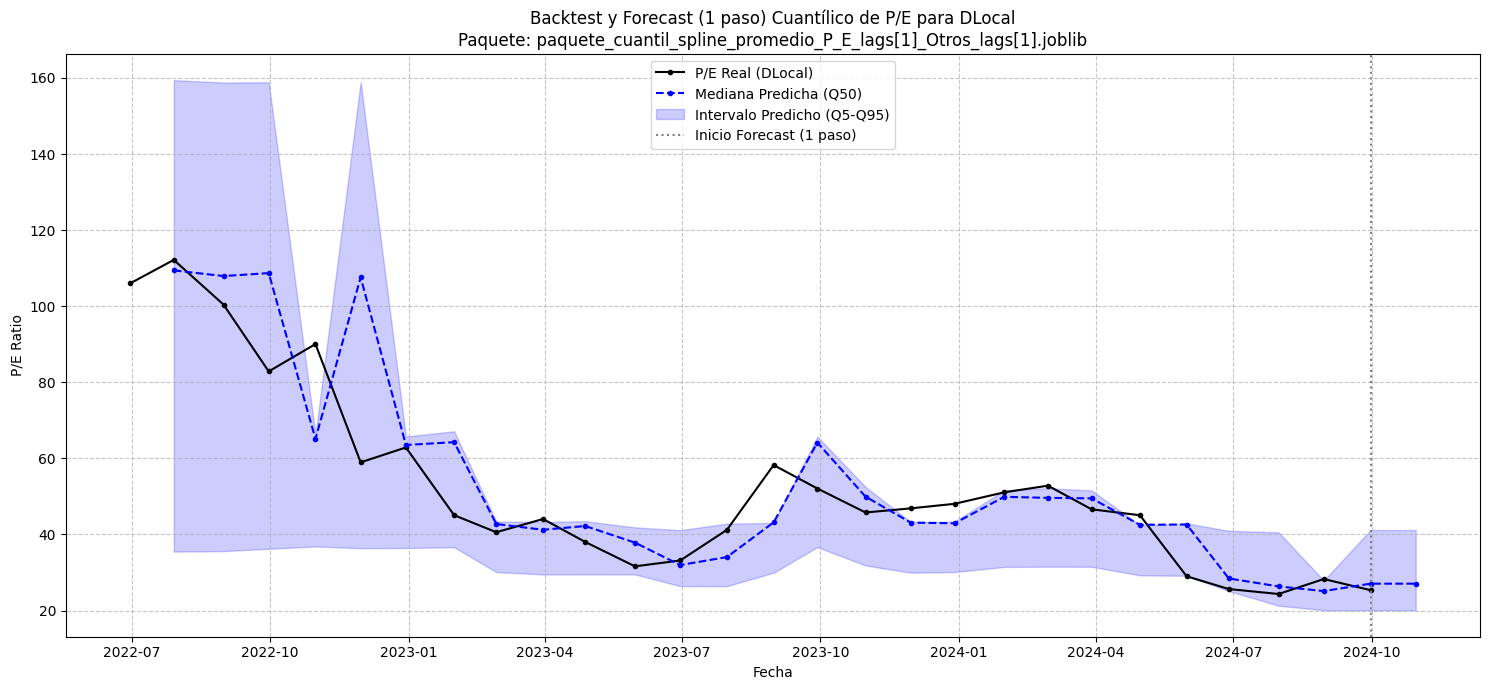


Forecast A Un Paso para DLocal:
       Fecha  P_E_pred_q5  P_E_pred_q50  P_E_pred_q95  P_E
0 2024-10-30    20.088307     27.066202     41.171329  NaN


In [54]:
# ================================================================================
# BLOQUE DE BACKTESTING "A UN PASO" Y FORECAST "A UN PASO" CUANTÍLICO PARA DLOCAL
# ================================================================================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import re
import warnings
from sklearn.metrics import mean_pinball_loss, mean_squared_error # Para métricas de backtesting

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# --- Configuración para la Predicción ---
EMPRESA_A_PREDECIR = "DLocal"
# N_FUTURE_STEPS ya no se usa para un forecast a un solo paso, pero lo dejamos por si se quiere cambiar
# N_FUTURE_STEPS_FORECAST = 1 # <--- CAMBIO CLAVE: Solo 1 paso para el forecast
QUANTILES_PREDICCION = [0.05, 0.5, 0.95]
ALPHA_LOWER_INTERVAL = QUANTILES_PREDICCION[0]
ALPHA_UPPER_INTERVAL = QUANTILES_PREDICCION[-1]
ALPHA_MEDIAN = QUANTILES_PREDICCION[len(QUANTILES_PREDICCION)//2]


# !!! NOMBRE DEL PAQUETE DE MODELOS ENTRENADOS !!!
NOMBRE_PAQUETE_MODELOS = "paquete_cuantil_spline_promedio_P_E_lags[1]_Otros_lags[1].joblib"
print(f"Usando el paquete: {NOMBRE_PAQUETE_MODELOS}")

# --- ASEGÚRATE DE QUE 'df_dlocal' ESTÉ DEFINIDO ANTES DE ESTE BLOQUE ---
if 'df_dlocal' not in locals() or not isinstance(df_dlocal, pd.DataFrame) or df_dlocal.empty:
    print(f"ERROR CRÍTICO: La variable 'df_dlocal' no está definida, no es un DataFrame o está vacía.")
    raise SystemExit("'df_dlocal' no disponible o inválida.")
else:
    print(f"INFO: Usando la variable 'df_dlocal' existente para los datos históricos de {EMPRESA_A_PREDECIR}.")
    df_empresa_hist_original = df_dlocal.copy()

# --- Cargar el paquete de modelos ---
# ... (Sección de carga de paquete sin cambios) ...
try:
    paquete_cargado = joblib.load(NOMBRE_PAQUETE_MODELOS)
    print(f"Paquete '{NOMBRE_PAQUETE_MODELOS}' cargado exitosamente.")
except FileNotFoundError:
    print(f"ERROR CRÍTICO: Archivo del paquete '{NOMBRE_PAQUETE_MODELOS}' no encontrado.")
    raise SystemExit(f"Archivo del paquete no encontrado: {NOMBRE_PAQUETE_MODELOS}")
except Exception as e:
    print(f"ERROR CRÍTICO: No se pudo cargar el paquete '{NOMBRE_PAQUETE_MODELOS}'. Error: {e}")
    raise SystemExit(f"Error al cargar el paquete: {e}")

log_transform_usada = paquete_cargado.get('log_transform_target')
features_entrenamiento = paquete_cargado.get('features_usadas_en_entrenamiento')
modelos_paquete = paquete_cargado.get('modelos_por_tipo_y_cuantil_o_puntual')

if any(v is None for v in [log_transform_usada, features_entrenamiento, modelos_paquete]):
    print("ERROR CRÍTICO: Información esencial faltante en el paquete cargado.")
    raise SystemExit("Paquete inválido.")

modelo_cuantil_key_base = None
for key_iter in modelos_paquete.keys():
    if 'Quantile' in key_iter and isinstance(modelos_paquete[key_iter], dict):
        potential_quantile_models = modelos_paquete[key_iter]
        if all(q_alpha in potential_quantile_models for q_alpha in QUANTILES_PREDICCION):
            modelo_cuantil_key_base = key_iter
            break
if not modelo_cuantil_key_base:
    print(f"ERROR CRÍTICO: No se encontró clave de diccionario para modelos cuantílicos en el paquete.")
    raise SystemExit("Modelos cuantílicos no encontrados en paquete.")
modelos_cuantil_dict = modelos_paquete[modelo_cuantil_key_base]
for alpha_val in QUANTILES_PREDICCION:
    if alpha_val not in modelos_cuantil_dict or not hasattr(modelos_cuantil_dict[alpha_val], 'predict'):
        print(f"ERROR CRÍTICO: Modelo para cuantil {alpha_val} faltante o inválido.")
        raise SystemExit(f"Modelo para cuantil {alpha_val} faltante o inválido.")

# --- Preparar datos históricos de DLocal ---
# ... (Sección de preparación de df_empresa_hist y función crear_features_con_lags sin cambios) ...
df_empresa_hist = df_empresa_hist_original.copy()
if 'Fecha' not in df_empresa_hist.columns:
    print("ERROR CRÍTICO: 'Fecha' no en df_empresa_hist (derivado de df_dlocal).")
    raise SystemExit("'Fecha' faltante.")
try:
    df_empresa_hist['Fecha'] = pd.to_datetime(df_empresa_hist['Fecha'])
except Exception as e_date:
    print(f"ERROR CRÍTICO: No se pudo convertir 'Fecha' a datetime. Error: {e_date}")
    raise SystemExit("Error en formato de 'Fecha'.")
df_empresa_hist.sort_values(by='Fecha', ascending=True, inplace=True)
df_empresa_hist.reset_index(drop=True, inplace=True)

def crear_features_con_lags_para_prediccion(df_historico_empresa, features_modelo_espera, fecha_base_prediccion):
    input_features = {}
    df_hist_para_lags = df_historico_empresa[df_historico_empresa['Fecha'] <= fecha_base_prediccion].sort_values(by='Fecha', ascending=False)
    if df_hist_para_lags.empty:
        for feat in features_modelo_espera: input_features[feat] = np.nan
        return pd.Series(input_features, index=features_modelo_espera)
    for feature_lag_name in features_modelo_espera:
        match = re.match(r"(.+)_lag(\d+)", feature_lag_name)
        if match:
            base_col_name = match.group(1)
            lag_n = int(match.group(2))
            if base_col_name not in df_hist_para_lags.columns:
                input_features[feature_lag_name] = np.nan
                continue
            if lag_n < len(df_hist_para_lags): 
                input_features[feature_lag_name] = df_hist_para_lags[base_col_name].iloc[lag_n]
            else:
                input_features[feature_lag_name] = np.nan
        else: 
            if feature_lag_name in df_hist_para_lags.columns:
                 input_features[feature_lag_name] = df_hist_para_lags[feature_lag_name].iloc[0] 
            else:
                input_features[feature_lag_name] = np.nan
    return pd.Series(input_features, index=features_modelo_espera)

# --- 1. BACKTESTING "A UN PASO": GENERAR PREDICCIONES PARA EL PERÍODO HISTÓRICO ---
# ... (Esta sección se mantiene igual que en el bloque anterior para el backtesting) ...
print("\n--- Backtesting A Un Paso para DLocal ---")
historical_predictions_list = []
min_lag_required = 0
if features_entrenamiento: 
    for feat_name in features_entrenamiento:
        match_lag = re.search(r"_lag(\d+)", feat_name)
        if match_lag:
            min_lag_required = max(min_lag_required, int(match_lag.group(1)))
for index, row_hist in df_empresa_hist.iterrows():
    current_hist_fecha = row_hist['Fecha']
    p_e_real_hist = row_hist.get('P_E', np.nan)
    pred_row_hist = {'Fecha': current_hist_fecha, 'P_E_real': p_e_real_hist}
    for alpha_val in QUANTILES_PREDICCION: 
        pred_row_hist[f'P_E_pred_q{int(alpha_val*100)}'] = np.nan
    if index < min_lag_required: 
        historical_predictions_list.append(pred_row_hist)
        continue
    hist_input_features = crear_features_con_lags_para_prediccion(df_empresa_hist, features_entrenamiento, current_hist_fecha)
    if hist_input_features.isna().all():
        historical_predictions_list.append(pred_row_hist)
        continue
    input_df_hist_model = pd.DataFrame([hist_input_features], columns=features_entrenamiento)
    for alpha_val in QUANTILES_PREDICCION:
        model_cuantil_actual = modelos_cuantil_dict[alpha_val]
        try:
            pred_transformed_hist = model_cuantil_actual.predict(input_df_hist_model)[0]
            if pd.isna(pred_transformed_hist): pred_original_hist = np.nan
            elif log_transform_usada: pred_original_hist = np.expm1(pred_transformed_hist)
            else: pred_original_hist = pred_transformed_hist
            pred_row_hist[f'P_E_pred_q{int(alpha_val*100)}'] = np.nan_to_num(pred_original_hist) if not pd.isna(pred_original_hist) else np.nan
        except Exception: pass             
    historical_predictions_list.append(pred_row_hist)
df_historical_quantile_preds = pd.DataFrame(historical_predictions_list)

# Calcular Métricas de Backtesting
# ... (Sección de métricas de backtesting sin cambios) ...
df_backtest_eval = df_historical_quantile_preds.dropna(
    subset=['P_E_real', f'P_E_pred_q{int(ALPHA_LOWER_INTERVAL*100)}', f'P_E_pred_q{int(ALPHA_UPPER_INTERVAL*100)}']
)
if not df_backtest_eval.empty:
    y_true_backtest = df_backtest_eval['P_E_real']
    pred_lower_backtest = df_backtest_eval[f'P_E_pred_q{int(ALPHA_LOWER_INTERVAL*100)}']
    pred_upper_backtest = df_backtest_eval[f'P_E_pred_q{int(ALPHA_UPPER_INTERVAL*100)}']
    coverage = np.mean((y_true_backtest >= pred_lower_backtest) & (y_true_backtest <= pred_upper_backtest))
    mean_interval_width = np.mean(pred_upper_backtest - pred_lower_backtest)
    pinball_loss_lower = mean_pinball_loss(y_true_backtest, pred_lower_backtest, alpha=ALPHA_LOWER_INTERVAL)
    pinball_loss_upper = mean_pinball_loss(y_true_backtest, pred_upper_backtest, alpha=ALPHA_UPPER_INTERVAL)
    avg_pinball_loss_interval = (pinball_loss_lower + pinball_loss_upper) / 2
    print(f"\nMétricas de Backtesting A Un Paso para DLocal:")
    print(f"  Puntos evaluados: {len(df_backtest_eval)}")
    print(f"  Cobertura ({ALPHA_LOWER_INTERVAL*100:.0f}%-{ALPHA_UPPER_INTERVAL*100:.0f}%): {coverage:.2%}")
    print(f"  Anchura Media Intervalo: {mean_interval_width:.2f}")
    print(f"  Pinball Loss Media Intervalo: {avg_pinball_loss_interval:.4f}")
    median_pred_col_name = f'P_E_pred_q{int(ALPHA_MEDIAN*100)}'
    if median_pred_col_name in df_backtest_eval.columns:
        valid_median_mask = df_backtest_eval[median_pred_col_name].notna()
        y_true_for_median = y_true_backtest[valid_median_mask]
        pred_median_backtest = df_backtest_eval.loc[valid_median_mask, median_pred_col_name]
        if not pred_median_backtest.empty and not y_true_for_median.empty:
            rmse_median = np.sqrt(mean_squared_error(y_true_for_median, pred_median_backtest))
            from sklearn.metrics import mean_absolute_error as mae
            mae_median = mae(y_true_for_median, pred_median_backtest)
            pinball_loss_median = mean_pinball_loss(y_true_for_median, pred_median_backtest, alpha=ALPHA_MEDIAN)
            print(f"  RMSE Mediana (Q{int(ALPHA_MEDIAN*100)}): {rmse_median:.2f}")
            print(f"  MAE Mediana (Q{int(ALPHA_MEDIAN*100)}): {mae_median:.2f}")
            print(f"  Pinball Loss Mediana (Q{int(ALPHA_MEDIAN*100)}): {pinball_loss_median:.4f}")
else:
    print("\nNo hay datos para métricas de backtesting.")

# --- 2. FORECAST "A UN PASO": GENERAR PREDICCIÓN SOLO PARA EL SIGUIENTE MES ---
print("\n--- Forecast A Un Paso para DLocal ---")
last_known_row_dlocal = df_empresa_hist.iloc[-1:]
last_known_P_E_original = last_known_row_dlocal['P_E'].iloc[0]
last_known_fecha = pd.to_datetime(last_known_row_dlocal['Fecha'].iloc[0])

# Features para predecir el primer mes futuro
features_for_next_step_forecast = crear_features_con_lags_para_prediccion(
    df_empresa_hist, features_entrenamiento, last_known_fecha
)

single_future_prediction_list = []
if not features_for_next_step_forecast.isna().all():
    input_df_forecast_model = pd.DataFrame([features_for_next_step_forecast], columns=features_entrenamiento)
    
    pred_step_transformed_future = {}
    pred_step_original_future = {}
    
    first_future_date = last_known_fecha + pd.DateOffset(months=1)
    pred_row_future = {'Fecha': first_future_date}

    for alpha_val in QUANTILES_PREDICCION:
        model_cuantil_actual = modelos_cuantil_dict[alpha_val]
        try:
            pred_transformed = model_cuantil_actual.predict(input_df_forecast_model)[0]
        except Exception:
            pred_transformed = np.nan
        pred_step_transformed_future[alpha_val] = pred_transformed
        
        if pd.isna(pred_transformed): pred_original_val = np.nan
        elif log_transform_usada: pred_original_val = np.expm1(pred_transformed)
        else: pred_original_val = pred_transformed
        pred_step_original_future[alpha_val] = np.nan_to_num(pred_original_val) if not pd.isna(pred_original_val) else np.nan
        pred_row_future[f'P_E_pred_q{int(alpha_val*100)}'] = pred_step_original_future[alpha_val]
        
    single_future_prediction_list.append(pred_row_future)
    
    q_strs_future = [f"Q{int(qv*100)}: {pred_step_original_future.get(qv, np.nan):.2f}" for qv in QUANTILES_PREDICCION]
    print(f"Predicción para {first_future_date.strftime('%Y-%m-%d')}: {', '.join(q_strs_future)}")
else:
    print("No se pudieron generar features para el forecast a un paso.")

df_single_future_prediction = pd.DataFrame(single_future_prediction_list)

# --- 3. COMBINAR DATAFRAMES Y GRAFICAR ---
df_historical_quantile_preds.rename(columns={'P_E_real': 'P_E'}, inplace=True, errors='ignore')
df_single_future_prediction['P_E'] = np.nan # No hay P/E real para el futuro

df_combined_predictions = pd.concat([df_historical_quantile_preds, df_single_future_prediction], ignore_index=True)
df_combined_predictions.sort_values(by='Fecha', inplace=True)

plt.figure(figsize=(15, 7))
plt.plot(df_combined_predictions['Fecha'], df_combined_predictions['P_E'], label=f'P/E Real ({EMPRESA_A_PREDECIR})', color='black', marker='.', linestyle='-')
median_col = f'P_E_pred_q{int(ALPHA_MEDIAN*100)}'
lower_col = f'P_E_pred_q{int(ALPHA_LOWER_INTERVAL*100)}'
upper_col = f'P_E_pred_q{int(ALPHA_UPPER_INTERVAL*100)}'
df_plot_median = df_combined_predictions.dropna(subset=[median_col])
df_plot_interval = df_combined_predictions.dropna(subset=[lower_col, upper_col])

if not df_plot_median.empty:
    plt.plot(df_plot_median['Fecha'], df_plot_median[median_col], label=f'Mediana Predicha (Q{int(ALPHA_MEDIAN*100)})', color='blue', marker='o', markersize=3, linestyle='--')
if not df_plot_interval.empty:
    plt.fill_between(df_plot_interval['Fecha'], df_plot_interval[lower_col], df_plot_interval[upper_col], color='blue', alpha=0.2, label=f'Intervalo Predicho (Q{int(ALPHA_LOWER_INTERVAL*100)}-Q{int(ALPHA_UPPER_INTERVAL*100)})')

# Línea vertical para separar backtest de forecast (ahora solo un punto de forecast)
plt.axvline(last_known_fecha, color='gray', linestyle=':', linewidth=1.5, label='Inicio Forecast (1 paso)')

plt.title(f'Backtest y Forecast (1 paso) Cuantílico de P/E para {EMPRESA_A_PREDECIR}\nPaquete: {NOMBRE_PAQUETE_MODELOS.split("/")[-1]}')
plt.xlabel('Fecha')
plt.ylabel('P/E Ratio')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Imprimir tabla de la única predicción futura
print("\n" + "="*80)
print(f"Forecast A Un Paso para {EMPRESA_A_PREDECIR}:")
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    print(df_single_future_prediction)
print("="*80)

#### Con transformación logarítmica


Procesando Método: lineal_mediana (CON Log Transform) (Lags: _lag1, con DropColumns)

    Métricas Test RF_Simple: RMSE=2.8832, MAE=1.5423, R2=0.9496
    Métricas Test RF_HP: RMSE=2.8222, MAE=1.5158, R2=0.9517
    Métricas Test XGB_Simple: RMSE=5.2252, MAE=1.9456, R2=0.8346
    Métricas Test XGB_HP: RMSE=4.2733, MAE=1.7490, R2=0.8894
    Métricas Test LGBM_Simple: RMSE=2.3481, MAE=1.2521, R2=0.9666
    Métricas Test LGBM_HP: RMSE=2.6387, MAE=1.3730, R2=0.9578
    Métricas Test CB_Simple: RMSE=3.1811, MAE=1.4734, R2=0.9387
    Métricas Test CB_HP: RMSE=3.1697, MAE=1.5242, R2=0.9391

Tiempo total para Método: lineal_mediana: 321.49s

Procesando Método: spline_mediana (CON Log Transform) (Lags: _lag1, con DropColumns)

    Métricas Test RF_Simple: RMSE=3.0015, MAE=1.5943, R2=0.9454
    Métricas Test RF_HP: RMSE=2.9157, MAE=1.5615, R2=0.9485
    Métricas Test XGB_Simple: RMSE=5.6298, MAE=2.2004, R2=0.8080
    Métricas Test XGB_HP: RMSE=3.9996, MAE=1.6920, R2=0.9031
    Métricas Test LGBM_

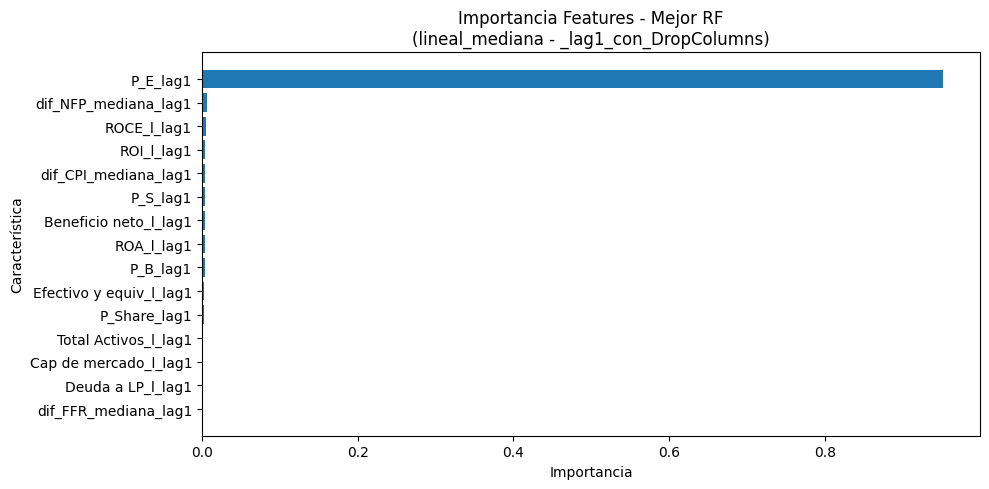

  Mejor XGB para lineal_mediana: RMSE = 4.2733
    Generando importancia de features para Mejor XGB de lineal_mediana...


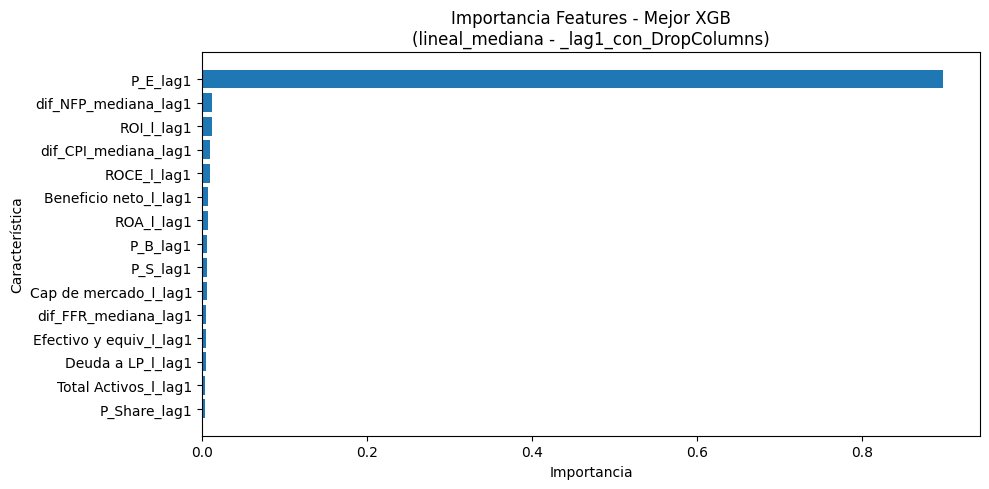

  Mejor LGBM para lineal_mediana: RMSE = 2.3481
    Generando importancia de features para Mejor LGBM de lineal_mediana...


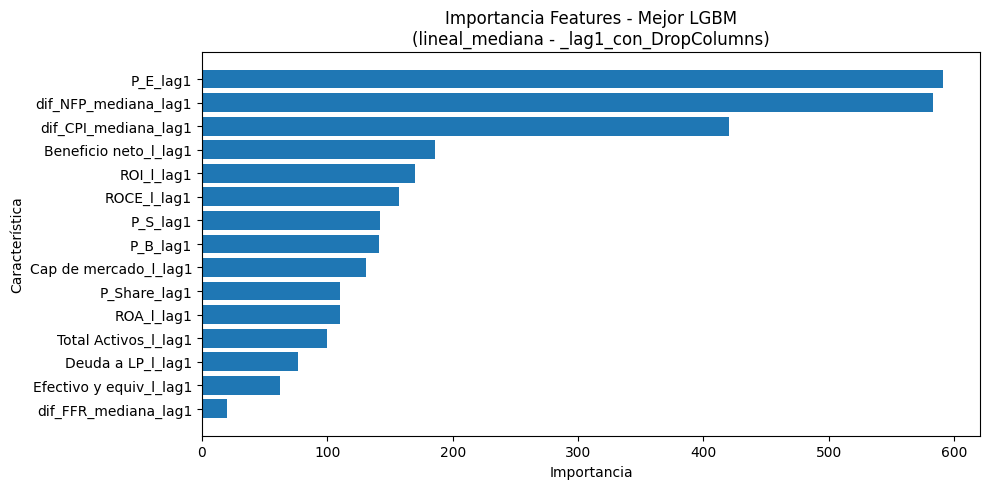

  Mejor CB para lineal_mediana: RMSE = 3.1697
    Generando importancia de features para Mejor CB de lineal_mediana...


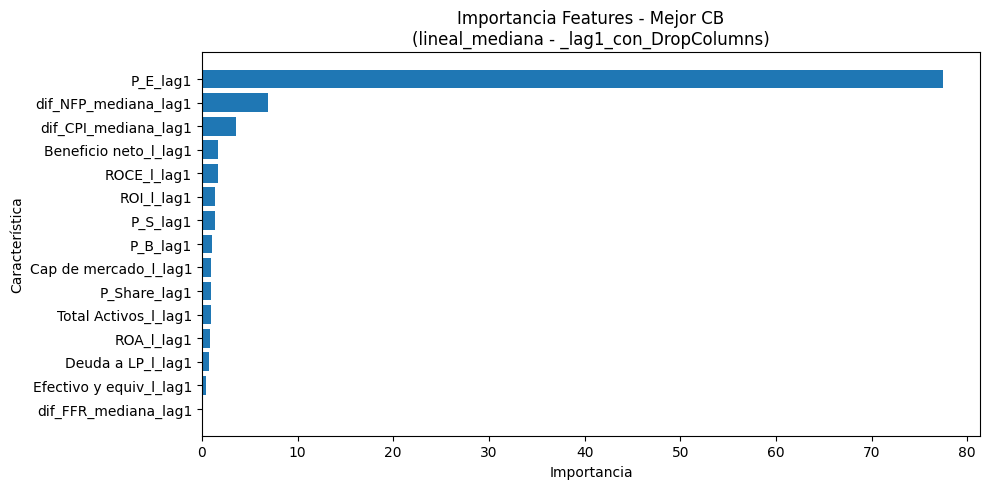


Paquete para 'lineal_mediana' guardado como: paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: spline_mediana ---
  Mejor RF para spline_mediana: RMSE = 2.9157
    Generando importancia de features para Mejor RF de spline_mediana...


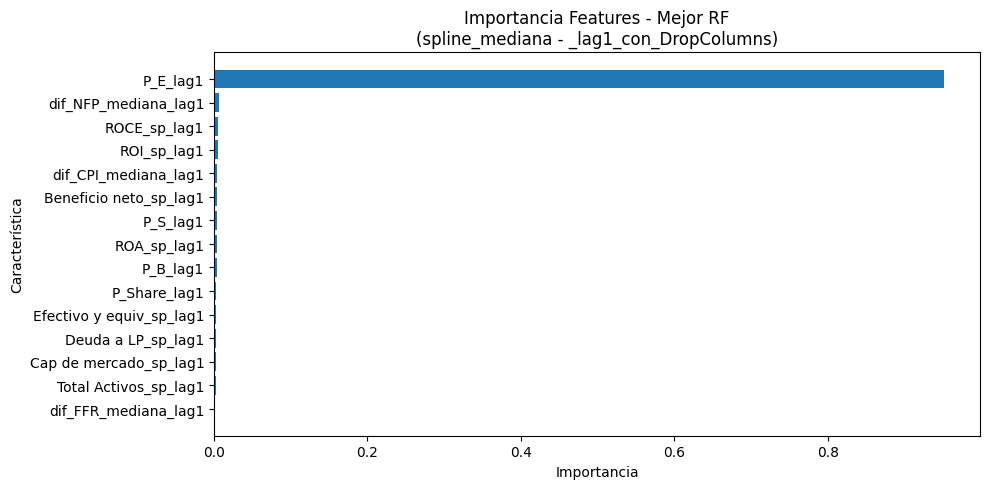

  Mejor XGB para spline_mediana: RMSE = 3.9996
    Generando importancia de features para Mejor XGB de spline_mediana...


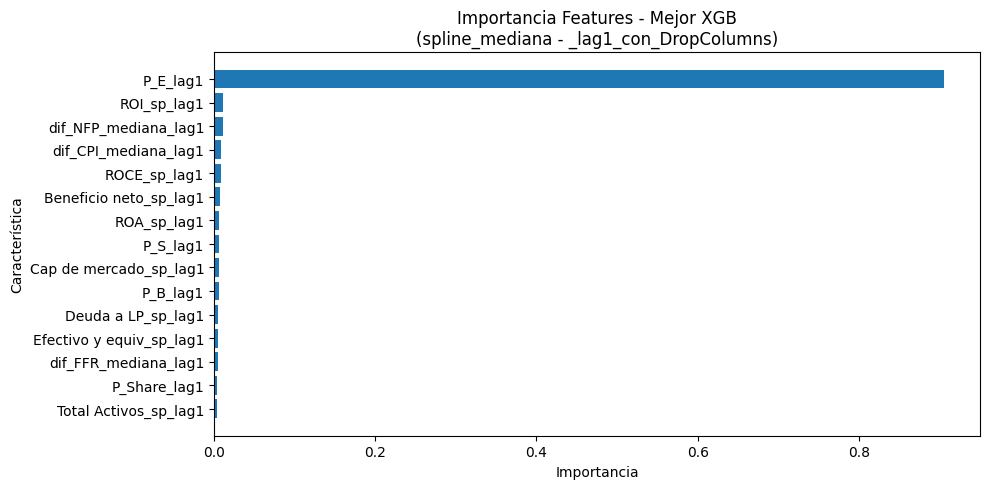

  Mejor LGBM para spline_mediana: RMSE = 2.3417
    Generando importancia de features para Mejor LGBM de spline_mediana...


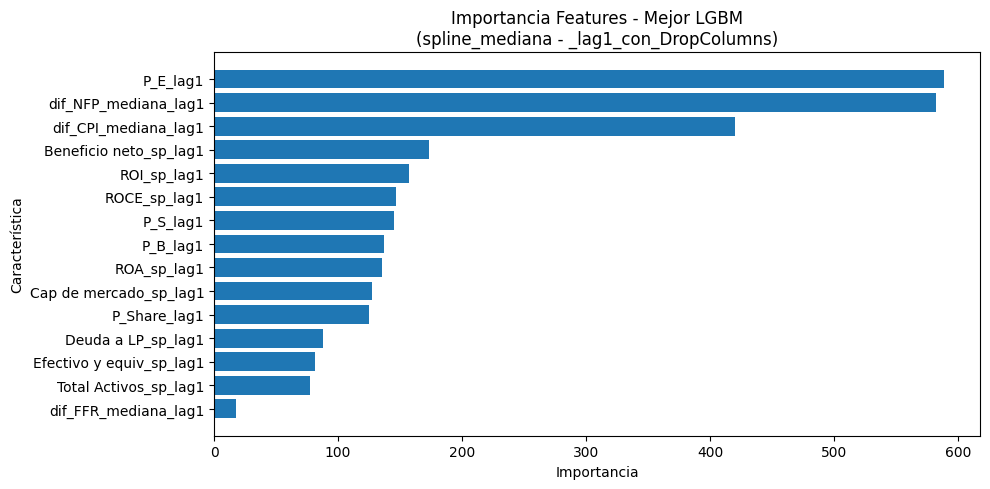

  Mejor CB para spline_mediana: RMSE = 2.8453
    Generando importancia de features para Mejor CB de spline_mediana...


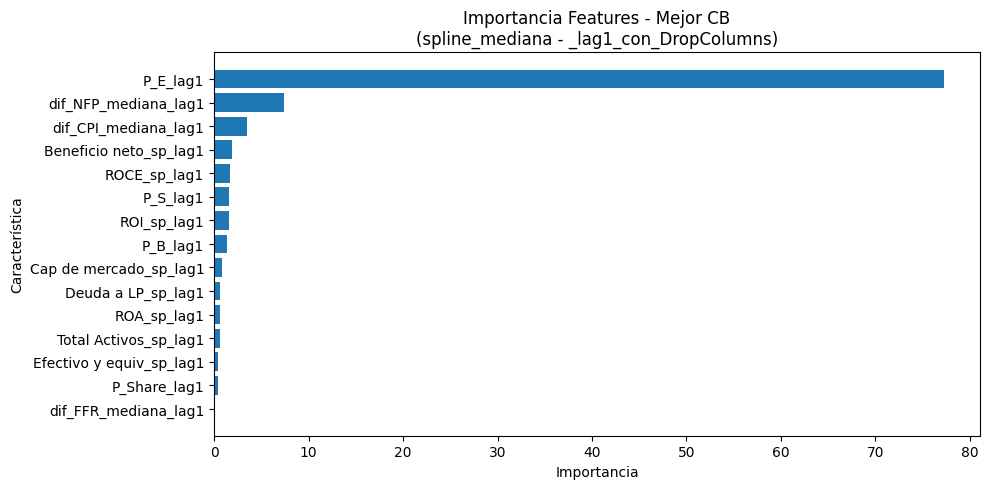


Paquete para 'spline_mediana' guardado como: paquete_mejores_por_tipo_spline_mediana__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: lineal_promedio ---
  Mejor RF para lineal_promedio: RMSE = 2.8219
    Generando importancia de features para Mejor RF de lineal_promedio...


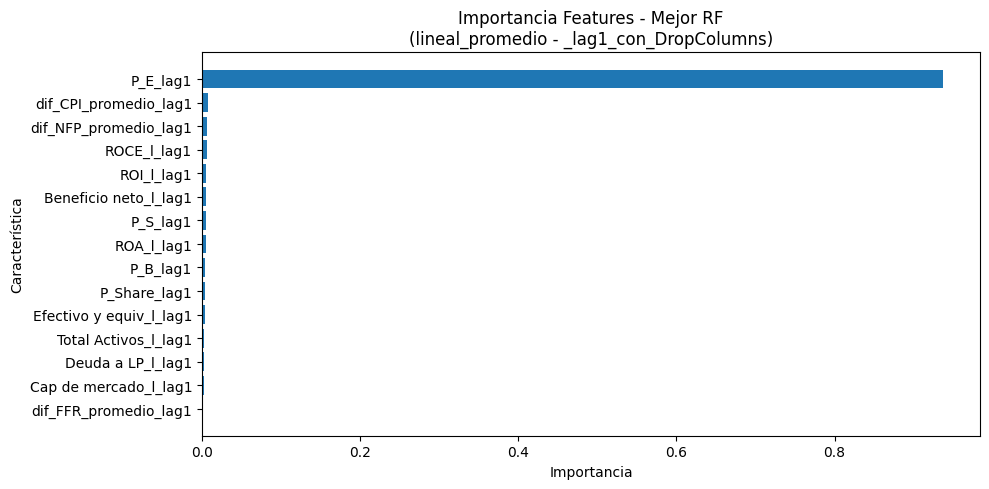

  Mejor XGB para lineal_promedio: RMSE = 4.1274
    Generando importancia de features para Mejor XGB de lineal_promedio...


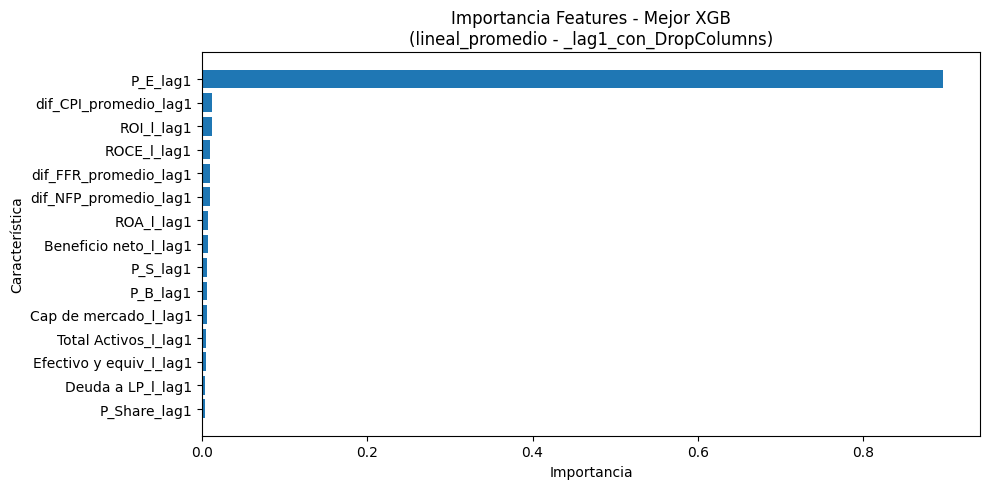

  Mejor LGBM para lineal_promedio: RMSE = 2.3988
    Generando importancia de features para Mejor LGBM de lineal_promedio...


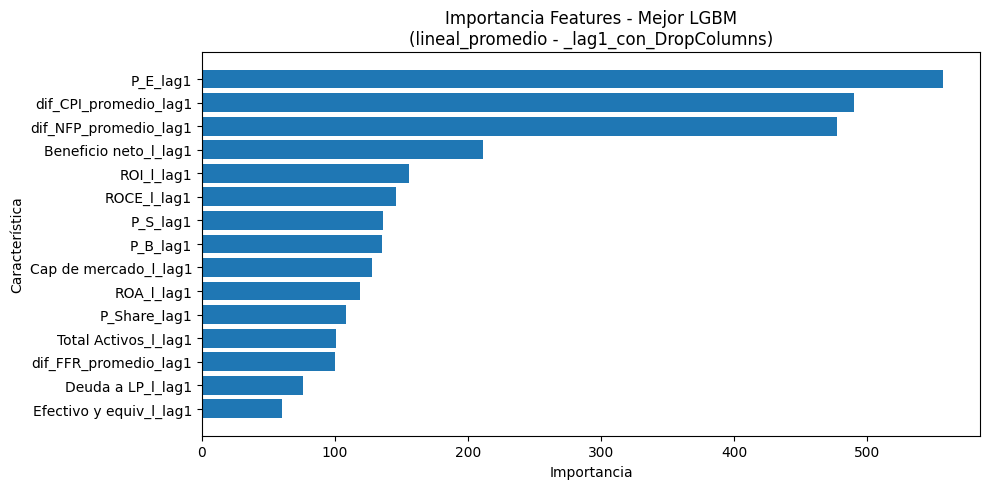

  Mejor CB para lineal_promedio: RMSE = 3.2837
    Generando importancia de features para Mejor CB de lineal_promedio...


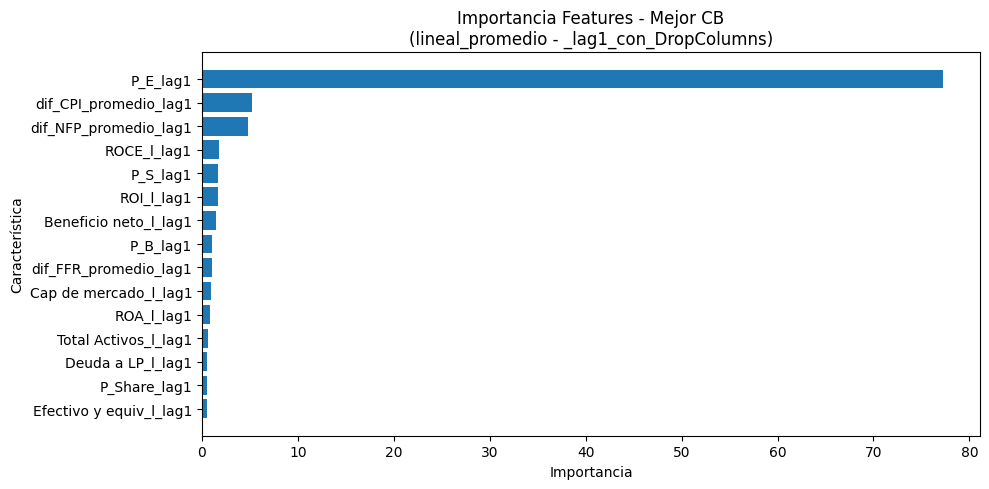


Paquete para 'lineal_promedio' guardado como: paquete_mejores_por_tipo_lineal_promedio__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: spline_promedio ---
  Mejor RF para spline_promedio: RMSE = 2.8682
    Generando importancia de features para Mejor RF de spline_promedio...


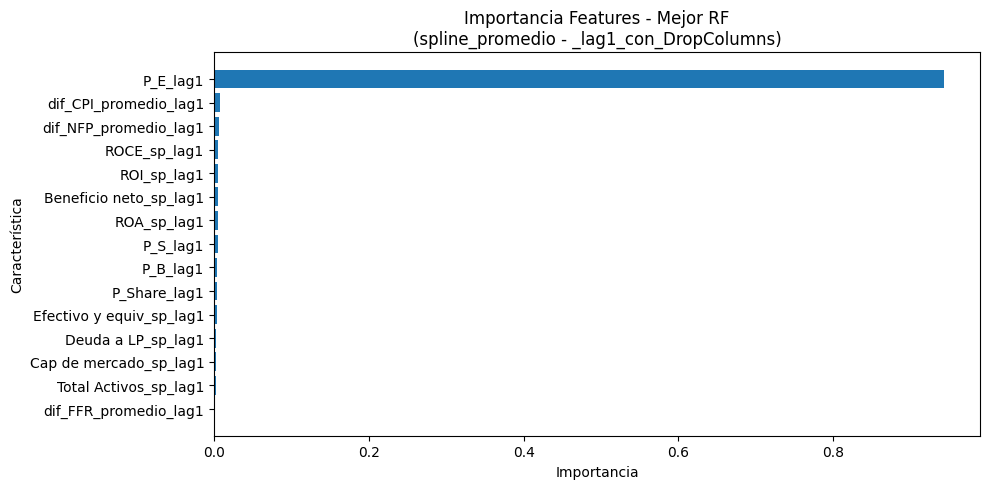

  Mejor XGB para spline_promedio: RMSE = 3.9168
    Generando importancia de features para Mejor XGB de spline_promedio...


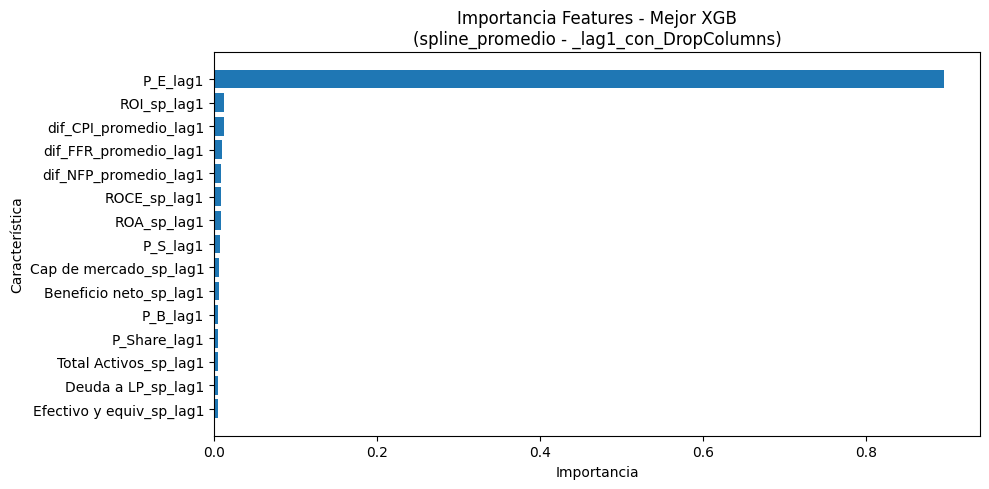

  Mejor LGBM para spline_promedio: RMSE = 2.3784
    Generando importancia de features para Mejor LGBM de spline_promedio...


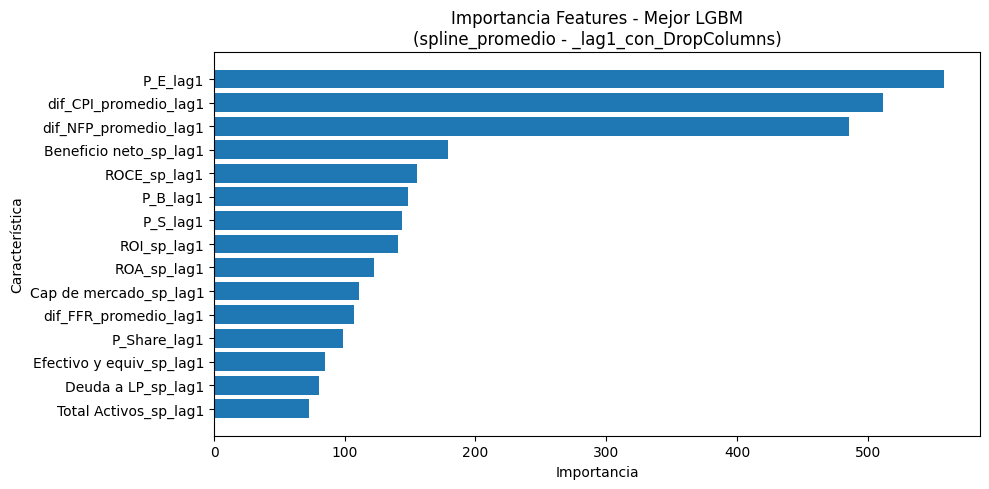

  Mejor CB para spline_promedio: RMSE = 2.9178
    Generando importancia de features para Mejor CB de spline_promedio...


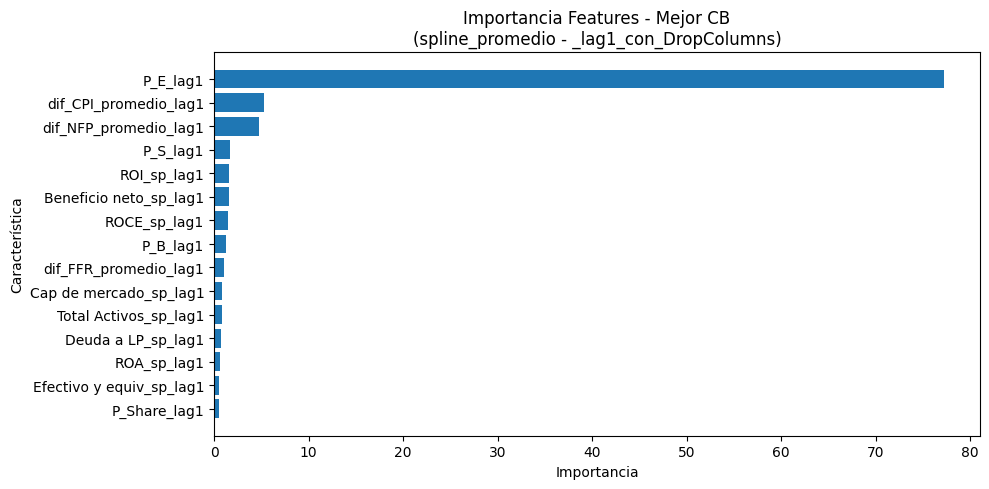


Paquete para 'spline_promedio' guardado como: paquete_mejores_por_tipo_spline_promedio__lag1_con_DropColumns.joblib

TABLA RESUMEN DE LOS MEJORES MODELOS POR TIPO
Metodo_Features            Lag_Config  Log_Transform Modelo_Tipo_Base   RMSE    MAE     R2  n_features_modelo                                                                                         Best_Params
 lineal_mediana _lag1_con_DropColumns           True             LGBM 2.3481 1.2521 0.9666                 15                                                                                                None
 lineal_mediana _lag1_con_DropColumns           True               RF 2.8222 1.5158 0.9517                 15                {'model__max_depth': 20, 'model__min_samples_split': 10, 'model__n_estimators': 100}
 lineal_mediana _lag1_con_DropColumns           True               CB 3.1697 1.5242 0.9391                 15 {'model__depth': 7, 'model__iterations': 200, 'model__l2_leaf_reg': 1, 'model__learning_rate': 0

In [38]:
# ================================================================================
# BLOQUE DE EXPERIMENTOS (CON DropColumns en Pipeline, PLOT FEATURE IMPORTANCE para Mejores por Tipo, GUARDAR PAQUETES)
# ================================================================================
results_accumulator = [] 
start_time_total_experiments = time.time()
use_log_transform_experiment = True
test_size_ratio_experiment = 0.20
LAG_SUFFIX_TO_USE = '_lag1' 

if 'dfs_shifted' not in locals() or not isinstance(dfs_shifted, dict) or not dfs_shifted:
    raise NameError("El diccionario 'dfs_shifted' no está definido o está vacío.")

for metodo_features, df_original_with_lags_and_ids in dfs_shifted.items():
    start_time_metodo = time.time()
    lag_config_display = f"{LAG_SUFFIX_TO_USE}_con_DropColumns" 

    print("\n" + "="*80)
    print(f"Procesando Método: {metodo_features} {'(CON Log Transform)' if use_log_transform_experiment else '(SIN Log Transform)'} (Lags: {LAG_SUFFIX_TO_USE}, con DropColumns)")
    print("="*80 + "\n")

    if df_original_with_lags_and_ids.empty: continue
    df_current_method_processed = df_original_with_lags_and_ids.copy()
    if 'time_step' not in df_current_method_processed.columns:
        df_current_method_processed.sort_values(['Empresa', 'Fecha'], inplace=True)
        df_current_method_processed['time_step'] = df_current_method_processed.groupby('Empresa').cumcount()

    predictor_cols_for_pipeline_input = sorted([
        c for c in df_current_method_processed.columns 
        if c.endswith(LAG_SUFFIX_TO_USE) and c not in ['Empresa', 'Fecha', 'time_step', 'P_E']
    ])
    if not predictor_cols_for_pipeline_input: continue
    columnas_base_que_generaron_lags = sorted(list(set(re.sub(r'_lag\d+$', '', lag_col) for lag_col in predictor_cols_for_pipeline_input)))
    
    all_relevant_cols_for_df = ['Empresa', 'Fecha', 'time_step', 'P_E'] + predictor_cols_for_pipeline_input
    final_cols_for_df_model_construction = sorted(list(set(c for c in all_relevant_cols_for_df if c in df_current_method_processed.columns)))
    essential_cols_check = ['Empresa', 'Fecha', 'time_step', 'P_E']
    if not all(ec in final_cols_for_df_model_construction for ec in essential_cols_check): continue
    df_model_for_splitting = df_current_method_processed[final_cols_for_df_model_construction].copy()

    n_total_empresas = df_model_for_splitting['Empresa'].nunique()
    n_empresas_test = 0
    if n_total_empresas > 1:
        n_empresas_test = max(1, int(round(n_total_empresas * test_size_ratio_experiment)))
        if n_total_empresas - n_empresas_test < 1 : n_empresas_test = n_total_empresas - 1
    X_train_with_ids, y_train_original, X_test_with_ids, y_test_original = train_test_split_by_empresa(df_model_for_splitting, n_empresas_test)
    if X_train_with_ids is None or X_train_with_ids.empty: continue
    
    y_train_transformed_target = y_train_original.copy()
    if use_log_transform_experiment:
        y_numeric = pd.to_numeric(y_train_original, errors='coerce')
        median_y_train = y_numeric.median() if not y_numeric.isnull().all() else 0.0
        y_numeric = y_numeric.fillna(median_y_train); y_numeric.loc[y_numeric < 0] = 0
        y_train_transformed_target = np.log1p(y_numeric)
        if y_train_transformed_target.isnull().any():
             median_y_transformed = y_train_transformed_target.median() if not y_train_transformed_target.isnull().all() else 0.0
             y_train_transformed_target = y_train_transformed_target.fillna(median_y_transformed)

    if not X_train_with_ids.index.equals(y_train_transformed_target.index):
        common_idx_train = X_train_with_ids.index.intersection(y_train_transformed_target.index)
        X_train_with_ids = X_train_with_ids.loc[common_idx_train]
        y_train_transformed_target = y_train_transformed_target.loc[common_idx_train]
        if X_train_with_ids.empty : continue

    X_train_s_with_ids, y_train_s_transformed = sort_by_timestep(X_train_with_ids, y_train_transformed_target)
    X_test_s_with_ids, y_test_s_original = pd.DataFrame(), pd.Series(dtype=float)
    if X_test_with_ids is not None and not X_test_with_ids.empty:
        X_test_s_with_ids, y_test_s_original = sort_by_timestep(X_test_with_ids, y_test_original)

    param_grid_rf   = {'model__max_depth':[10, 20, None],'model__min_samples_split':[5, 10],'model__n_estimators':[100, 200]}
    param_grid_xgb  = {'model__n_estimators':[100, 200],'model__max_depth':[3, 5, 7],'model__learning_rate':[0.1, 0.05]}
    param_grid_lgbm = {'model__n_estimators':[100, 200],'model__learning_rate':[0.1, 0.05],'model__max_depth':[3, 5, 7],'model__num_leaves':[15, 31]}
    param_grid_cb   = {'model__iterations':[100, 200],'model__learning_rate':[0.1, 0.05],'model__depth':[3, 5, 7],'model__l2_leaf_reg':[1, 3]}
    scenarios = {
        'RF_Simple':  {'model': RandomForestRegressor(random_state=42, n_jobs=-1), 'hp': False, 'vt': False, 'grid': param_grid_rf},
        'RF_HP':      {'model': RandomForestRegressor(random_state=42, n_jobs=-1), 'hp': True,  'vt': False, 'grid': param_grid_rf},
        'XGB_Simple': {'model': XGBRegressor(random_state=42, n_jobs=-1), 'hp': False, 'vt': False, 'grid': param_grid_xgb},
        'XGB_HP':     {'model': XGBRegressor(random_state=42, n_jobs=-1), 'hp': True,  'vt': False, 'grid': param_grid_xgb},
        'LGBM_Simple':{'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1), 'hp': False, 'vt': False, 'grid': param_grid_lgbm},
        'LGBM_HP':    {'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1), 'hp': True,  'vt': False, 'grid': param_grid_lgbm},
        'CB_Simple':  {'model': CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False), 'hp': False, 'vt': False, 'grid': param_grid_cb},
        'CB_HP':      {'model': CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False), 'hp': True,  'vt': False, 'grid': param_grid_cb},
    }

    for escenario_nombre, escenario_cfg in scenarios.items():
        tiempo_esc_inicio = time.time()
        current_base_model = escenario_cfg['model']; perform_hp_search = escenario_cfg['hp']; use_temporal_cv_in_scenario = escenario_cfg.get('vt', False)
        X_fit_data_pipeline = X_train_s_with_ids if use_temporal_cv_in_scenario else X_train_with_ids
        y_fit_data_pipeline = y_train_s_transformed if use_temporal_cv_in_scenario else y_train_transformed_target
        X_eval_data_pipeline = X_test_s_with_ids if use_temporal_cv_in_scenario else X_test_with_ids
        y_eval_data_original_final = y_test_s_original if use_temporal_cv_in_scenario else y_test_original
        if X_fit_data_pipeline.empty or y_fit_data_pipeline.empty:
            results_accumulator.append({'Modelo': escenario_nombre.split('_')[0], 'Validacion_Temp': use_temporal_cv_in_scenario,
                'Busqueda_HP': perform_hp_search, 'Config_Key': metodo_features, 'Metodo': metodo_features,
                'Lag_Config': lag_config_display, 'Log_Transform': use_log_transform_experiment, 'RMSE': np.nan, 'MAE': np.nan, 
                'R2': np.nan, 'Best_Params': None, 'pipeline': 'Error: Datos vacíos', 
                'columnas_base_usadas': columnas_base_que_generaron_lags, 
                'n_features_modelo': len(predictor_cols_after_drop), 
                'features_usadas_por_modelo': [], 'Error': 'Datos vacíos'})
            continue
        cols_to_drop_in_pipeline = [col for col in ['Empresa', 'Fecha', 'time_step'] if col in X_fit_data_pipeline.columns]
        pipeline_obj_for_training = Pipeline([('drop_ids', DropColumns(columns=cols_to_drop_in_pipeline)), ('model', current_base_model)])
        model_actual_features_for_plot = [col for col in X_fit_data_pipeline.columns if col not in cols_to_drop_in_pipeline]
        final_fitted_pipeline, hp_best_params_found, error_msg_escenario = None, None, None
        try:
            if perform_hp_search:
                cv_strategy_obj, cv_fit_params_dict, can_perform_cv = None, {}, True
                n_groups_for_cv = X_fit_data_pipeline['Empresa'].nunique() if use_temporal_cv_in_scenario and 'Empresa' in X_fit_data_pipeline.columns else 0
                if use_temporal_cv_in_scenario and n_groups_for_cv >= 2:
                    groups_for_gkf = X_fit_data_pipeline['Empresa']; n_splits_gkf = min(3, n_groups_for_cv); n_splits_gkf = max(2, n_splits_gkf)
                    if len(X_fit_data_pipeline) < n_splits_gkf : can_perform_cv = False
                    else: cv_strategy_obj = GroupKFold(n_splits=n_splits_gkf); cv_fit_params_dict = {'groups': groups_for_gkf}
                elif len(X_fit_data_pipeline) >= 2:
                    n_samples_kf = len(X_fit_data_pipeline); kfold_splits_val = min(3, n_samples_kf); kfold_splits_val = max(2, kfold_splits_val)
                    if n_samples_kf < kfold_splits_val : can_perform_cv = False
                    else: cv_strategy_obj = KFold(n_splits=kfold_splits_val, shuffle=True, random_state=42)
                else: can_perform_cv = False
                if not can_perform_cv or cv_strategy_obj is None: perform_hp_search = False
                if perform_hp_search:
                    gs = GridSearchCV(pipeline_obj_for_training, escenario_cfg['grid'], scoring=rmse_scorer, cv=cv_strategy_obj, n_jobs=-1, refit=True, error_score='raise', verbose=0)
                    gs.fit(X_fit_data_pipeline, y_fit_data_pipeline, **cv_fit_params_dict)
                    final_fitted_pipeline, hp_best_params_found = gs.best_estimator_, gs.best_params_
            if not perform_hp_search or final_fitted_pipeline is None:
                pipeline_obj_for_training.fit(X_fit_data_pipeline, y_fit_data_pipeline)
                final_fitted_pipeline = pipeline_obj_for_training; hp_best_params_found = None
        except Exception as e: error_msg_escenario = str(e)
        eval_metrics_dict, n_features_in_final_model_attr = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}, "N/A"
        if final_fitted_pipeline:
            try:
                actual_estimator = final_fitted_pipeline.steps[-1][1]
                n_features_in_final_model_attr = getattr(actual_estimator, 'n_features_in_', "N/A")
                if not X_eval_data_pipeline.empty and not y_eval_data_original_final.empty:
                    pred_transformed_eval = final_fitted_pipeline.predict(X_eval_data_pipeline)
                    pred_original_scale_eval = np.expm1(pred_transformed_eval) if use_log_transform_experiment else pred_transformed_eval
                    if use_log_transform_experiment: pred_original_scale_eval[~np.isfinite(pred_original_scale_eval)] = np.nan
                    eval_metrics_dict = evaluate_model(y_eval_data_original_final, pred_original_scale_eval)
                    print(f"    Métricas Test {escenario_nombre}: RMSE={eval_metrics_dict['RMSE']:.4f}, MAE={eval_metrics_dict['MAE']:.4f}, R2={eval_metrics_dict['R2']:.4f}")
                # NO PLOTEAMOS AQUÍ, LO HAREMOS AL FINAL PARA LOS MEJORES POR TIPO
            except Exception as e_eval: error_msg_escenario = (error_msg_escenario + f" | EvalError: {str(e_eval)}") if error_msg_escenario else f"EvalError: {str(e_eval)}"
        
        results_accumulator.append({
            'Modelo': escenario_nombre.split('_')[0], 'Validacion_Temp': use_temporal_cv_in_scenario and isinstance(cv_strategy_obj, GroupKFold),
            'Busqueda_HP': escenario_cfg['hp'] and perform_hp_search, 
            'Config_Key': metodo_features, 'Metodo': metodo_features, 
            'Lag_Config': lag_config_display, 
            'Log_Transform': use_log_transform_experiment, 
            'RMSE': eval_metrics_dict['RMSE'], 'MAE': eval_metrics_dict['MAE'], 'R2': eval_metrics_dict['R2'], 
            'Best_Params': hp_best_params_found, 
            'pipeline': final_fitted_pipeline, 
            'columnas_base_usadas': columnas_base_que_generaron_lags, 
            'n_features_modelo': n_features_in_final_model_attr, 
            'features_usadas_por_modelo': model_actual_features_for_plot, # Guardar las features que vio el estimador
            'Error': error_msg_escenario
        })
    print(f"\nTiempo total para Método: {metodo_features}: {time.time() - start_time_metodo:.2f}s")
print(f"\n\nTiempo total de ejecución de todos los experimentos: {(time.time() - start_time_total_experiments)/60:.2f} minutos")

# ================================================================================
# CREAR TABLA DE RESULTADOS GENERAL, GUARDAR PAQUETES Y PLOTEAR MEJORES POR TIPO
# ================================================================================
if results_accumulator:
    df_results_all_experiments = pd.DataFrame(results_accumulator)
    print("\n" + "="*80 + "\n--- Resultados Finales Globales ---\n" + f"Total resultados: {len(df_results_all_experiments)}\n")
    cols_to_display_summary = ['Metodo', 'Modelo', 'Busqueda_HP', 'RMSE', 'MAE', 'R2', 'n_features_modelo', 'Lag_Config', 'Error', 'Best_Params'] # Quitado 'features_usadas_por_modelo' para brevedad
    final_cols_to_display_summary = [col for col in cols_to_display_summary if col in df_results_all_experiments.columns]
    with pd.option_context('display.max_rows', 200, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
        print(df_results_all_experiments.sort_values(by=['Metodo','RMSE'], ascending=[True,True])[final_cols_to_display_summary].to_string(index=False))

    lista_info_mejores_por_tipo_global = []
    for metodo_actual_features_key in df_results_all_experiments['Metodo'].unique(): 
        print("\n" + "="*70 + f"\n--- Preparando paquete y plots para Método: {metodo_actual_features_key} ---")
        df_resultados_metodo_actual = df_results_all_experiments[
            (df_results_all_experiments['Metodo'] == metodo_actual_features_key) &
            (df_results_all_experiments['RMSE'].notna()) &
            (df_results_all_experiments['pipeline'].notna()) & 
            (df_results_all_experiments['Error'].isna()) &
            (df_results_all_experiments['pipeline'].apply(lambda x: not (isinstance(x, str) and x.startswith('Error:')))) & # Asegurar que pipeline no sea string de error
            (df_results_all_experiments['features_usadas_por_modelo'].apply(lambda x: isinstance(x, list) and len(x) > 0)) # Asegurar que hay features
        ].copy()

        if df_resultados_metodo_actual.empty: 
            print(f"No hay resultados válidos con features para el método '{metodo_actual_features_key}' para crear paquete o plotear.")
            continue

        mejores_modelos_info_para_paquete = {}
        modelos_base_a_considerar = ['RF', 'XGB', 'LGBM', 'CB']
        
        metadata_ref_row = df_resultados_metodo_actual.iloc[0]
        log_transform_paquete_actual = metadata_ref_row.get('Log_Transform', True)
        columnas_base_paquete_actual = metadata_ref_row.get('columnas_base_usadas', []) 
        lag_config_paquete_actual = metadata_ref_row.get('Lag_Config', 'desconocida')
        
        for tipo_modelo_base in modelos_base_a_considerar:
            df_tipo_especifico = df_resultados_metodo_actual[df_resultados_metodo_actual['Modelo'] == tipo_modelo_base]
            if not df_tipo_especifico.empty:
                mejor_fila_tipo_actual = df_tipo_especifico.sort_values(by='RMSE', ascending=True).iloc[0]
                
                pipeline_obj_actual = mejor_fila_tipo_actual['pipeline']
                features_usadas_actual = mejor_fila_tipo_actual['features_usadas_por_modelo']

                mejores_modelos_info_para_paquete[tipo_modelo_base] = {
                    'pipeline_object': pipeline_obj_actual,
                    'RMSE': mejor_fila_tipo_actual['RMSE'], 'MAE': mejor_fila_tipo_actual['MAE'],
                    'R2': mejor_fila_tipo_actual['R2'], 'Best_Params': mejor_fila_tipo_actual['Best_Params'],
                    'n_features_modelo': mejor_fila_tipo_actual['n_features_modelo'],
                    'features_usadas_por_modelo': features_usadas_actual, 
                    'Escenario_Validacion_Temp': mejor_fila_tipo_actual['Validacion_Temp'],
                    'Escenario_Busqueda_HP': mejor_fila_tipo_actual['Busqueda_HP']}
                
                print(f"  Mejor {tipo_modelo_base} para {metodo_actual_features_key}: RMSE = {mejor_fila_tipo_actual['RMSE']:.4f}")

                # --- PLOT FEATURE IMPORTANCE PARA ESTE MEJOR MODELO POR TIPO ---
                titulo_plot_tipo = (
                    f"Importancia Features - Mejor {tipo_modelo_base}\n"
                    f"({metodo_actual_features_key} - {lag_config_paquete_actual})"
                )
                print(f"    Generando importancia de features para Mejor {tipo_modelo_base} de {metodo_actual_features_key}...")
                plot_feature_importances(
                    pipeline_obj_actual, # El pipeline completo (DropColumns + modelo)
                    feature_names=features_usadas_actual, # Las features que vio el estimador final
                    title=titulo_plot_tipo
                )
                # --- FIN PLOT ---

                info_para_tabla_resumen = {
                    'Metodo_Features': metodo_actual_features_key, 
                    'Lag_Config': lag_config_paquete_actual,
                    'Log_Transform': log_transform_paquete_actual, 
                    'Modelo_Tipo_Base': tipo_modelo_base,
                    'RMSE': mejor_fila_tipo_actual['RMSE'], 'MAE': mejor_fila_tipo_actual['MAE'],
                    'R2': mejor_fila_tipo_actual['R2'], 'n_features_modelo': mejor_fila_tipo_actual['n_features_modelo'],
                    'Best_Params': mejor_fila_tipo_actual['Best_Params']}
                lista_info_mejores_por_tipo_global.append(info_para_tabla_resumen)
            else: 
                mejores_modelos_info_para_paquete[tipo_modelo_base] = None 

        if any(mejores_modelos_info_para_paquete.values()):
            paquete_final_a_guardar = {
                'metodo_features': metodo_actual_features_key, 
                'lag_config_usada': lag_config_paquete_actual,
                'log_transform_target': log_transform_paquete_actual,
                'columnas_base_para_lags': columnas_base_paquete_actual, 
                'mejores_modelos_info_por_tipo': mejores_modelos_info_para_paquete
            }
            nombre_archivo_paquete_final = f"paquete_mejores_por_tipo_{metodo_actual_features_key.replace(' ', '_')}_{lag_config_paquete_actual}.joblib"
            try:
                joblib.dump(paquete_final_a_guardar, nombre_archivo_paquete_final)
                print(f"\nPaquete para '{metodo_actual_features_key}' guardado como: {nombre_archivo_paquete_final}")
            except Exception as e_dump_final_package: print(f"\nERROR al guardar paquete para '{metodo_actual_features_key}': {e_dump_final_package}")
    
    if lista_info_mejores_por_tipo_global:
        df_mejores_por_tipo_global = pd.DataFrame(lista_info_mejores_por_tipo_global)
        print("\n" + "="*80 + "\nTABLA RESUMEN DE LOS MEJORES MODELOS POR TIPO" + "\n" + "="*80)
        with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
            cols_resumen_mejores = ['Metodo_Features', 'Lag_Config', 'Log_Transform', 'Modelo_Tipo_Base', 'RMSE', 'MAE', 'R2', 'n_features_modelo', 'Best_Params']
            cols_resumen_existentes = [col for col in cols_resumen_mejores if col in df_mejores_por_tipo_global.columns]
            print(df_mejores_por_tipo_global.sort_values(by=['Metodo_Features', 'RMSE'], ascending=[True, True])[cols_resumen_existentes].to_string(index=False))
else: 
    print("\nNo se generaron resultados en los experimentos.")

In [39]:
df_mejores_por_tipo_global.sort_values(by=['Metodo_Features', 'RMSE'], ascending=[True, True])

,Metodo_Features,Lag_Config,Log_Transform,Modelo_Tipo_Base,RMSE,MAE,R2,n_features_modelo,Best_Params
2,lineal_mediana,_lag1_con_DropColumns,True,LGBM,2.348086,1.252078,0.966596,15,None
0,lineal_mediana,_lag1_con_DropColumns,True,RF,2.822174,1.515766,0.951746,15,"{'model__max_depth': 20, 'model__min_samples_s..."
3,lineal_mediana,_lag1_con_DropColumns,True,CB,3.169740,1.524174,0.939128,15,"{'model__depth': 7, 'model__iterations': 200, ..."
1,lineal_mediana,_lag1_con_DropColumns,True,XGB,4.273331,1.748973,0.889362,15,"{'model__learning_rate': 0.1, 'model__max_dept..."
10,lineal_promedio,_lag1_con_DropColumns,True,LGBM,2.398819,1.271018,0.965137,15,None
8,lineal_promedio,_lag1_con_DropColumns,True,RF,2.821934,1.491650,0.951754,15,None
11,lineal_promedio,_lag1_con_DropColumns,True,CB,3.283651,1.541012,0.934674,15,"{'model__depth': 7, 'model__iterations': 200, ..."
9,lineal_promedio,_lag1_con_DropColumns,True,XGB,4.127430,1.651089,0.896788,15,"{'model__learning_rate': 0.1, 'model__max_dept..."
6,spline_mediana,_lag1_con_DropColumns,True,LGBM,2.341670,1.250741,0.966778,15,None
7,spline_mediana,_lag1_con_DropColumns,True,CB,2.845322,1.404611,0.950951,15,"{'model__depth': 7, 'model__iterations': 200, ..."


Cargando paquete de modelos desde: paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib
Paquete de modelos cargado exitosamente.
  Información del Paquete: Método=lineal_mediana, LagConfig=_lag1_con_DropColumns, LogT=True
    Columnas Base (usadas para generar lags): 15 ['Beneficio neto_l', 'Cap de mercado_l', 'Deuda a LP_l', 'Efectivo y equiv_l', 'P_B']...
    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.
Se generarán lags [1] para DLocal.

Preparando datos de DLocal (Método: lineal_mediana, Lags: [1])
Generando lags para DLocal para las features: ['Beneficio neto_l', 'Cap de mercado_l', 'Deuda a LP_l', 'Efectivo y equiv_l', 'P_B', 'P_E', 'P_S', 'P_Share', 'ROA_l', 'ROCE_l', 'ROI_l', 'Total Activos_l', 'dif_CPI_mediana', 'dif_FFR_mediana', 'dif_NFP_mediana']
Se generaron 15 columnas de lag para DLocal: ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
    ¡Confirmado! L

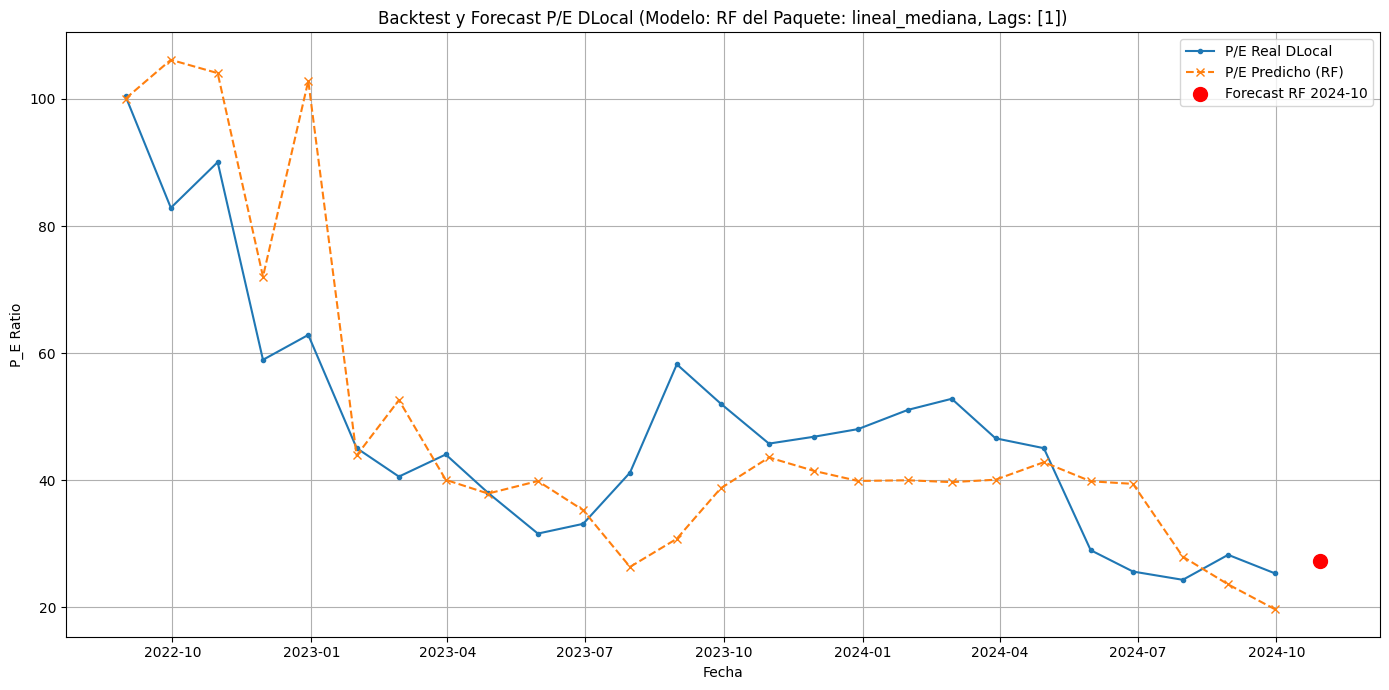


--- Procesando Modelo Tipo: XGB ---
  Features esperadas por XGB (del paquete o inferidas): 15 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
  Métricas Backtest (XGB): RMSE=14.2356, MAE=11.9857, R2=0.4321


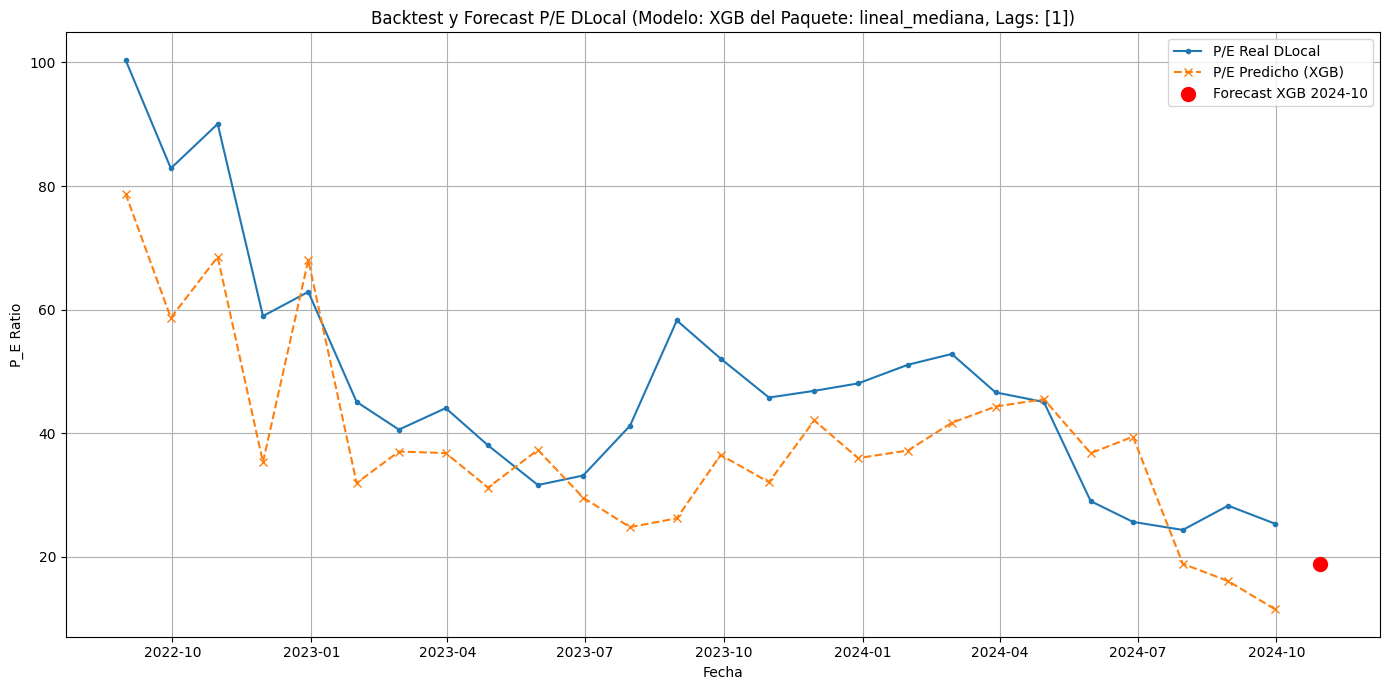


--- Procesando Modelo Tipo: LGBM ---
  Features esperadas por LGBM (del paquete o inferidas): 15 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
  Métricas Backtest (LGBM): RMSE=11.0274, MAE=8.0886, R2=0.6592


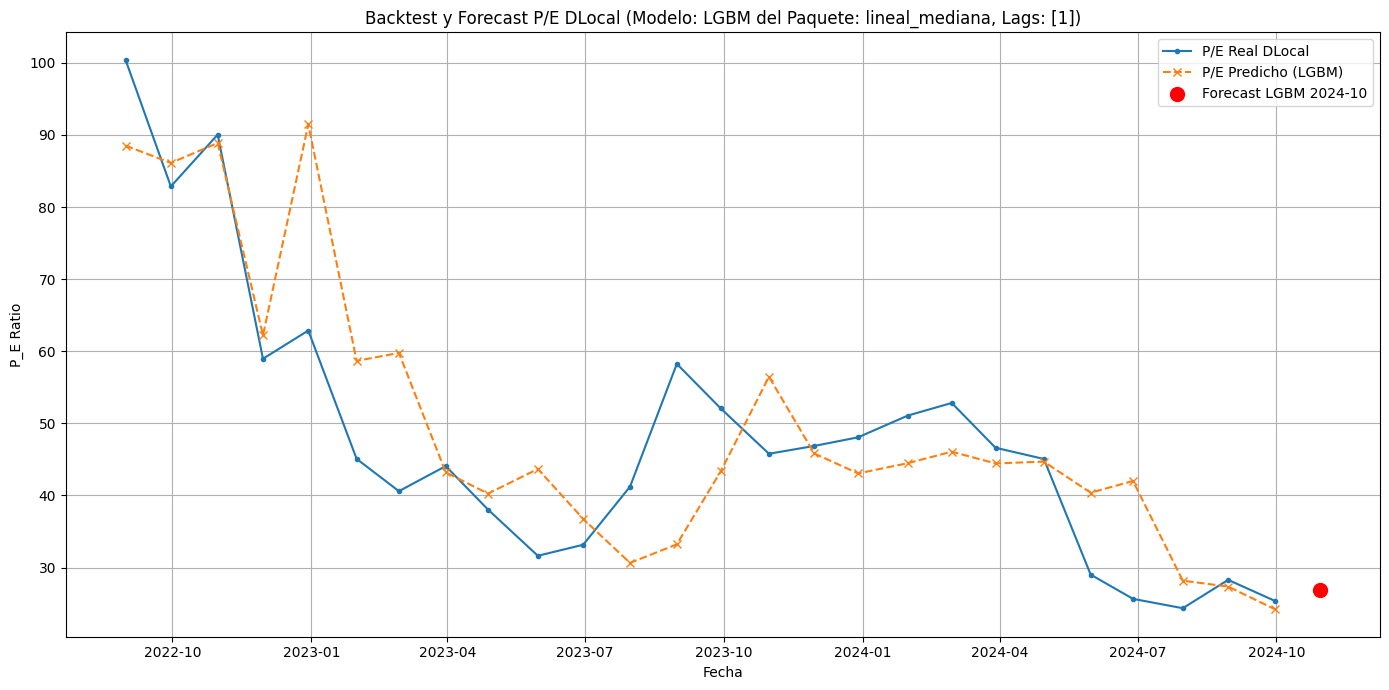


--- Procesando Modelo Tipo: CB ---
  Features esperadas por CB (del paquete o inferidas): 15 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
  Métricas Backtest (CB): RMSE=14.0549, MAE=10.3524, R2=0.4465


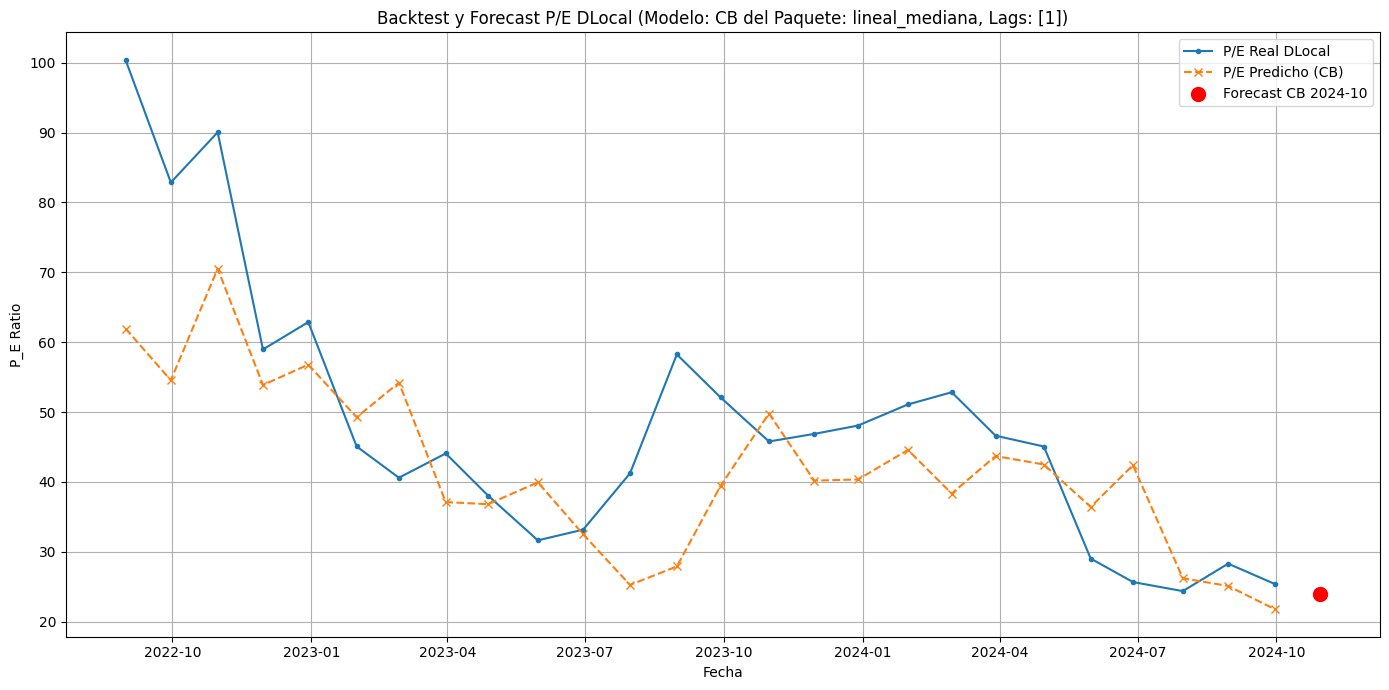


Resumen de Métricas Individuales de los Modelos en el Backtest de DLocal
Modelo_Tipo    RMSE     MAE     R2
       LGBM 11.0274  8.0886 0.6592
         RF 13.4563 10.0468 0.4926
         CB 14.0549 10.3524 0.4465
        XGB 14.2356 11.9857 0.4321

Proceso de predicción para DLocal completado.


In [40]:
# =====================================================================================
# BLOQUE DE PREDICCIÓN PARA DLOCAL (MODELOS INDIVIDUALES - GRÁFICOS Y MÉTRICAS)
# =====================================================================================

# --- 0. CONFIGURACIÓN Y CARGA DEL PAQUETE DEL MODELO ---
# ASUME: df_dlocal está cargado.
#        listas_columnas está definida (si es necesaria como fallback para columnas_base_paquete).
#        El paquete fue entrenado incluyendo P_E_lagN como feature si se desea usar aquí.

nombre_paquete_a_cargar = "paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib"

print(f"Cargando paquete de modelos desde: {nombre_paquete_a_cargar}")
model_package = None
try:
    ruta_paquete = os.path.join(os.getcwd(), nombre_paquete_a_cargar)
    if not os.path.exists(ruta_paquete):
        raise FileNotFoundError(f"El archivo del paquete '{ruta_paquete}' no existe.")
    model_package = joblib.load(ruta_paquete)
    print("Paquete de modelos cargado exitosamente.")

    required_keys = ['metodo_features', 'lag_config_usada', 'log_transform_target', 'mejores_modelos_info_por_tipo']
    if not isinstance(model_package, dict) or not all(key in model_package for key in required_keys):
        raise ValueError("El archivo cargado no es un paquete de modelos válido o le faltan claves esenciales.")

    metodo_features_paquete = model_package['metodo_features']
    lag_config_paquete = model_package['lag_config_usada'] 
    log_transform_paquete = model_package['log_transform_target']
    columnas_base_paquete = model_package.get('columnas_base_para_lags') # Esta clave debe existir en tu paquete
    mejores_modelos_info = model_package['mejores_modelos_info_por_tipo']

    if not columnas_base_paquete: # Fallback si no está en el paquete
        print("ADVERTENCIA: 'columnas_base_para_lags' no encontrada en el paquete. Intentando usar 'listas_columnas'.")
        if 'listas_columnas' in locals() and metodo_features_paquete in listas_columnas:
            columnas_base_paquete = listas_columnas[metodo_features_paquete]
            # Si P_E_lagN se usó y 'P_E' no está en listas_columnas[metodo_features_paquete], hay que añadirlo:
            # Esta lógica asume que si P_E_lagN es una feature, 'P_E' debe estar en las bases para generar ese lag.
            # El paquete idealmente ya tendría 'P_E' en 'columnas_base_para_lags' si P_E_lagN fue usado.
            # Si el paquete es de "solo lags de P/E", columnas_base_paquete debería ser ['P_E'].
            if 'P_E' not in columnas_base_paquete and any(f.startswith("P_E_lag") for f_dict in mejores_modelos_info.values() if f_dict and 'features_usadas_por_modelo' in f_dict for f in f_dict['features_usadas_por_modelo']):
                 if 'P_E' in df_dlocal.columns:
                    print("Añadiendo 'P_E' a columnas_base_paquete para generar su lag, basado en features de modelos.")
                    columnas_base_paquete.append('P_E')
                    columnas_base_paquete = sorted(list(set(columnas_base_paquete)))
        else: 
            raise ValueError("No se pudieron determinar las 'columnas_base_para_lags' ni del paquete ni de 'listas_columnas'.")
    
    print(f"  Información del Paquete: Método={metodo_features_paquete}, LagConfig={lag_config_paquete}, LogT={log_transform_paquete}")
    print(f"    Columnas Base (usadas para generar lags): {len(columnas_base_paquete)} {columnas_base_paquete[:5]}...")
    if 'P_E' in columnas_base_paquete:
        print("    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.")
    else:
        print("    ADVERTENCIA: 'P_E' NO está en columnas_base_paquete. NO se generará P_E_lagN como feature para DLocal, a menos que lag_config_paquete lo fuerce.")

except FileNotFoundError: raise FileNotFoundError(f"ERROR FATAL: No se encontró el archivo del paquete '{nombre_paquete_a_cargar}'.")
except Exception as e_load_pack: raise RuntimeError(f"Error fatal al cargar o procesar el paquete: {e_load_pack}")

if 'df_dlocal' not in locals() or not isinstance(df_dlocal, pd.DataFrame) or df_dlocal.empty:
     raise NameError("'df_dlocal' no definido o vacío.")

# Determinar qué lags generar para DLocal basado en lag_config_paquete
lags_a_generar_dlocal = []
temp_lag_str_cfg = str(lag_config_paquete).lower()
temp_lag_str_cfg = temp_lag_str_cfg.replace('pe_lags_', '').replace('_solo_pred', '').replace('lags_', '').replace('lag', '')
found_numbers_cfg = re.findall(r'\d+', temp_lag_str_cfg)
if found_numbers_cfg:
    lags_a_generar_dlocal = sorted(list(set(int(num) for num in found_numbers_cfg)))
if not lags_a_generar_dlocal: # Fallback
    for i in range(1, 7): 
        if f"lag{i}" in str(lag_config_paquete).lower() or f"_{i}" in str(lag_config_paquete): 
            lags_a_generar_dlocal.append(i)
    lags_a_generar_dlocal = sorted(list(set(lags_a_generar_dlocal)))
if not lags_a_generar_dlocal:
    raise ValueError(f"No se pudo determinar qué lags numéricos generar a partir de lag_config_paquete: '{lag_config_paquete}'")
print(f"Se generarán lags {lags_a_generar_dlocal} para DLocal.")


# --- 1. PREPARAR df_dlocal ---
print("\n" + "="*80 + f"\nPreparando datos de DLocal (Método: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})" + "\n" + "="*80)
df_dlocal_procesado_base = df_dlocal.copy()

# 1.1 Conversión Numérica
# Usar 'columnas_base_paquete' que ahora debería incluir 'P_E' si P_E_lagN es una feature.
cols_convertir_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
for col in cols_convertir_dlocal:
    if not pd.api.types.is_numeric_dtype(df_dlocal_procesado_base[col]):
        df_dlocal_procesado_base[col] = pd.to_numeric(df_dlocal_procesado_base[col], errors='coerce')

# 1.2 Imputación Pre-Lag
cols_imputar_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
if cols_imputar_dlocal:
    df_dlocal_procesado_base.sort_values(['Empresa', 'Fecha'], inplace=True)
    if df_dlocal_procesado_base['Empresa'].nunique() > 1:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base.groupby('Empresa')[cols_imputar_dlocal].ffill()
    else:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].ffill()
    df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].fillna(0)

# 1.3 Generar Lags
# 'features_para_generar_lags_dlocal' se basa en 'columnas_base_paquete'
features_para_generar_lags_dlocal = [c for c in columnas_base_paquete if c in df_dlocal_procesado_base.columns]
# Asegurar que P_E esté si se espera P_E_lagN y no está ya en features_para_generar_lags_dlocal
# (Esta lógica es un poco redundante si columnas_base_paquete ya es correcta)
if any(f"P_E_lag{lg}" in model_info_actual.get('features_usadas_por_modelo',[]) for lg in lags_a_generar_dlocal for model_info_actual in mejores_modelos_info.values() if model_info_actual) \
   and 'P_E' not in features_para_generar_lags_dlocal and 'P_E' in df_dlocal_procesado_base.columns:
    print("  Asegurando que 'P_E' se incluya para generar sus lags para DLocal.")
    features_para_generar_lags_dlocal.append('P_E')
    features_para_generar_lags_dlocal = sorted(list(set(features_para_generar_lags_dlocal)))


cols_necesarias_para_base_df = ['Empresa', 'Fecha']
if 'P_E' in df_dlocal_procesado_base.columns: cols_necesarias_para_base_df.append('P_E')
for f_lag in features_para_generar_lags_dlocal:
    if f_lag not in cols_necesarias_para_base_df: cols_necesarias_para_base_df.append(f_lag)

df_dlocal_con_todos_lags = df_dlocal_procesado_base[cols_necesarias_para_base_df].copy()
all_generated_lag_cols_dlocal = []

print(f"Generando lags para DLocal para las features: {features_para_generar_lags_dlocal}")
for lag_val in lags_a_generar_dlocal:
    for col_base_para_lag in features_para_generar_lags_dlocal:
        lag_col_name = f"{col_base_para_lag}_lag{lag_val}"
        df_dlocal_con_todos_lags[lag_col_name] = df_dlocal_con_todos_lags.groupby('Empresa')[col_base_para_lag].shift(lag_val)
        all_generated_lag_cols_dlocal.append(lag_col_name)
all_generated_lag_cols_dlocal = sorted(list(set(all_generated_lag_cols_dlocal)))
print(f"Se generaron {len(all_generated_lag_cols_dlocal)} columnas de lag para DLocal: {all_generated_lag_cols_dlocal[:5]}...")
# Confirmación de P_E_lagN
pe_lags_actually_generated = [col for col in all_generated_lag_cols_dlocal if col.startswith("P_E_lag")]
if pe_lags_actually_generated:
    print(f"    ¡Confirmado! Lags de P/E generados: {pe_lags_actually_generated}")
else:
    print("    ADVERTENCIA: NO se generaron lags de P/E para DLocal. Verifica 'columnas_base_paquete' y la lógica de generación de lags.")

# 1.4 Aplicar dropna
df_dlocal_final_features_con_ids = df_dlocal_con_todos_lags.dropna(subset=all_generated_lag_cols_dlocal).copy()
if df_dlocal_final_features_con_ids.empty: raise ValueError("DLocal vacío post lags y dropna.")
print(f"DataFrame DLocal procesado y listo (con IDs y lags): {df_dlocal_final_features_con_ids.shape}")

# --- 2. ITERAR, PREDECIR, EVALUAR INDIVIDUALMENTE Y GRAFICAR ---
print("\n" + "="*80 + "\nIterando sobre modelos por tipo para predicción, evaluación y graficación individual en DLocal" + "\n" + "="*80)
lista_metricas_individuales_dlocal = []

for tipo_modelo_actual, model_info_actual in mejores_modelos_info.items():
    print(f"\n--- Procesando Modelo Tipo: {tipo_modelo_actual} ---")

    if model_info_actual is None or 'pipeline_object' not in model_info_actual or model_info_actual['pipeline_object'] is None:
        print(f"  No hay un pipeline válido para '{tipo_modelo_actual}'. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    pipeline_cargado_actual = model_info_actual['pipeline_object']
    estimador_real_actual = pipeline_cargado_actual
    if hasattr(pipeline_cargado_actual, 'steps'): estimador_real_actual = pipeline_cargado_actual.steps[-1][1]
    
    # Obtener las features que este modelo específico espera (guardadas en el paquete)
    features_esperadas_por_modelo_actual = model_info_actual.get('features_usadas_por_modelo', [])
    
    if not features_esperadas_por_modelo_actual: # Fallback si no se guardaron en el paquete
        print(f"  ADVERTENCIA para {tipo_modelo_actual}: 'features_usadas_por_modelo' no encontrada en el paquete. Intentando inferir...")
        if hasattr(estimador_real_actual, 'feature_names_in_'):
            features_esperadas_por_modelo_actual = list(estimador_real_actual.feature_names_in_)
        elif hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == len(all_generated_lag_cols_dlocal):
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        elif tipo_modelo_actual == 'CB' and hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == 0 and len(all_generated_lag_cols_dlocal) > 0:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        else:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal # Último recurso
            print(f"    Usando todos los {len(all_generated_lag_cols_dlocal)} lags generados como fallback final.")

    if not features_esperadas_por_modelo_actual:
        print(f"  Error: Lista final de features esperadas vacía para {tipo_modelo_actual}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    print(f"  Features esperadas por {tipo_modelo_actual} (del paquete o inferidas): {len(features_esperadas_por_modelo_actual)} {features_esperadas_por_modelo_actual[:5]}...")

    missing_features_in_dlocal = [f for f in features_esperadas_por_modelo_actual if f not in df_dlocal_final_features_con_ids.columns]
    if missing_features_in_dlocal:
        print(f"  ERROR para {tipo_modelo_actual}: Faltan features en DLocal que el modelo espera: {missing_features_in_dlocal}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    X_dlocal_input_this_model = df_dlocal_final_features_con_ids[features_esperadas_por_modelo_actual].copy()
    df_dlocal_eval_data_this_model = df_dlocal_final_features_con_ids[['Fecha', 'P_E']].loc[X_dlocal_input_this_model.index].copy()
    
    if X_dlocal_input_this_model.empty:
        print(f"  Input para {tipo_modelo_actual} vacío. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
    
    n_rows_pred_this_model = len(X_dlocal_input_this_model); fechas_p_individual, preds_p_individual, reales_p_individual = [], [], []
    if n_rows_pred_this_model > 0:
        if n_rows_pred_this_model > 1: # Backtest
            for i in range(1, n_rows_pred_this_model):
                X_pred_row_loop = X_dlocal_input_this_model.iloc[[i-1]]
                try:
                    pred_raw_loop = pipeline_cargado_actual.predict(X_pred_row_loop)[0]
                    pred_orig_loop = np.expm1(pred_raw_loop) if log_transform_paquete else pred_raw_loop
                    if log_transform_paquete and not np.isfinite(pred_orig_loop): pred_orig_loop = np.nan
                except Exception as e_pred_loop:
                    pred_orig_loop = np.nan
                    print(f"    Error en backtest para {tipo_modelo_actual} (Fecha target: {df_dlocal_eval_data_this_model.iloc[i]['Fecha']}): {e_pred_loop}")
                preds_p_individual.append(pred_orig_loop)
                fechas_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['Fecha'])
                reales_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['P_E'])
        
        X_forecast_row_loop = X_dlocal_input_this_model.iloc[[-1]]; pronostico_final_individual = np.nan
        try:
            pred_raw_forecast_loop = pipeline_cargado_actual.predict(X_forecast_row_loop)[0]
            pronostico_final_individual = np.expm1(pred_raw_forecast_loop) if log_transform_paquete else pred_raw_forecast_loop
            if log_transform_paquete and not np.isfinite(pronostico_final_individual): pronostico_final_individual = np.nan
        except Exception as e_forecast_ind:
             print(f"    Error durante el forecast para {tipo_modelo_actual}: {e_forecast_ind}")
        
        proxima_fecha_individual = "Periodo Siguiente"
        if not df_dlocal_eval_data_this_model.empty and 'Fecha' in df_dlocal_eval_data_this_model.columns and not df_dlocal_eval_data_this_model['Fecha'].empty:
            try: proxima_fecha_individual = df_dlocal_eval_data_this_model['Fecha'].iloc[-1] + pd.DateOffset(months=1)
            except: pass
            
        df_backtest_individual = pd.DataFrame({'Fecha': fechas_p_individual, 'P_E_Predicho': preds_p_individual, 'P_E_Real': reales_p_individual})
        
        metricas_individual_actual = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
        if not df_backtest_individual.empty:
            metricas_individual_actual = evaluate_model(df_backtest_individual['P_E_Real'], df_backtest_individual['P_E_Predicho'])
            print(f"  Métricas Backtest ({tipo_modelo_actual}): RMSE={metricas_individual_actual['RMSE']:.4f}, MAE={metricas_individual_actual['MAE']:.4f}, R2={metricas_individual_actual['R2']:.4f}")
        
        metricas_a_guardar = metricas_individual_actual.copy()
        metricas_a_guardar['Modelo_Tipo'] = tipo_modelo_actual
        lista_metricas_individuales_dlocal.append(metricas_a_guardar)

        if not df_backtest_individual.empty:
            plt.figure(figsize=(14, 7))
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Real'], marker='.', linestyle='-', label='P/E Real DLocal')
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Predicho'], marker='x', linestyle='--', label=f'P/E Predicho ({tipo_modelo_actual})')
            if isinstance(proxima_fecha_individual, pd.Timestamp) and pd.notna(pronostico_final_individual):
                 plt.scatter([proxima_fecha_individual], [pronostico_final_individual], color='red', label=f'Forecast {tipo_modelo_actual} {proxima_fecha_individual.strftime("%Y-%m")}', zorder=5, s=100)
            plt.title(f'Backtest y Forecast P/E DLocal (Modelo: {tipo_modelo_actual} del Paquete: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})')
            plt.xlabel('Fecha'); plt.ylabel('P_E Ratio'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
    else:
        print(f"  No hay datos suficientes en DLocal procesado para hacer predicciones con {tipo_modelo_actual}.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})

# --- 3. IMPRIMIR TABLA DE MÉTRICAS INDIVIDUALES (AL FINAL) ---
if lista_metricas_individuales_dlocal:
    df_metricas_final_dlocal = pd.DataFrame(lista_metricas_individuales_dlocal)
    print("\n" + "="*80 + "\nResumen de Métricas Individuales de los Modelos en el Backtest de DLocal" + "\n" + "="*80)
    df_metricas_final_dlocal_sorted = df_metricas_final_dlocal.sort_values(by='RMSE', ascending=True)
    columnas_ordenadas_metricas = ['Modelo_Tipo', 'RMSE', 'MAE', 'R2']
    columnas_existentes_para_print = [col for col in columnas_ordenadas_metricas if col in df_metricas_final_dlocal_sorted.columns]
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.4f}'.format):
        print(df_metricas_final_dlocal_sorted[columnas_existentes_para_print].to_string(index=False))
else:
    print("\nNo se generaron métricas para DLocal o la lista está vacía.")

print("\n" + "="*80 + "\nProceso de predicción para DLocal completado." + "\n" + "="*80)

Tiene sentido obtener resultados muy similares (o incluso idénticos) a cuando se hacía fillna(0) globalmente, bajo ciertas condiciones específicas.

Posibles Razones para Resultados Similares:

Pocos NaNs en other_cols después de ffill:

Si el ffill() dentro de cada grupo ya resuelve la gran mayoría de los NaNs en las other_cols, entonces los pasos posteriores (mediana de grupo, fillna(0) global) tendrían un impacto mínimo porque operarían sobre muy pocos valores.
Esto es más probable si tus series temporales por empresa son relativamente completas y los NaNs son esporádicos en lugar de bloques grandes al inicio de cada serie.
La Mediana del Grupo (g.median()) es Frecuentemente Cero o Cercana a Cero:
Para algunas de tus other_cols (ratios, magnitudes), si la mediana calculada dentro de cada grupo de empresa resulta ser cero (o muy cercana a cero), entonces el paso .transform(lambda g: g.fillna(g.median())) estaría, en efecto, rellenando con cero.

Esto podría ocurrir si:

Una empresa tiene muchos ceros reales en esa feature.

Una empresa tiene pocos valores no nulos y la mediana de esos pocos valores es cero.

Muchas Empresas con Historial Completamente Vacío para Ciertas other_cols:

Si para una other_col específica, una empresa tiene todos sus valores como NaN, entonces:

ffill() no hará nada para esa empresa/columna.

g.median() para esa empresa/columna será NaN.

g.fillna(g.median()) (que es g.fillna(NaN)) no cambiará los NaNs.

Finalmente, el df[other_cols] = df[other_cols].fillna(0) global rellenará esos NaNs persistentes con 0.

Si este es el caso para una proporción significativa de tus datos en other_cols, entonces el resultado final de la imputación para esas celdas seguirá siendo 0.

Las cols_zero_ok son las Dominantes o Más Importantes:

Si las columnas en cols_zero_ok (donde explícitamente imputas con 0) son las que tienen la mayor cantidad de NaNs iniciales o son las features más importantes para tus modelos, entonces el cambio en la estrategia de imputación para other_cols podría no tener un impacto tan grande en los resultados finales del modelo.

Las Banderas _was_na No Son Explotadas por los Modelos (o no son suficientemente informativas):

Aunque creas las columnas _was_na, no hay garantía de que los modelos de árbol las encuentren suficientemente útiles como para cambiar significativamente sus patrones de división en comparación con cuando el valor imputado era simplemente 0.

Si la ausencia de un dato no tiene una correlación fuerte con el target (después de considerar otras features), la bandera podría tener baja importancia.

Naturaleza de los Datos y el Modelo:

A veces, los modelos de árbol pueden ser sorprendentemente robustos a diferentes estrategias de imputación simples si la señal principal proviene de otras features o si los valores imputados no caen en puntos críticos de decisión para el árbol.

En resumen, es plausible obtener resultados similares si:

La cantidad de datos realmente afectados por la nueva lógica de imputación para other_cols es pequeña.

Las medianas de grupo para other_cols son a menudo cero.

El fillna(0) final sigue siendo el que rellena una cantidad significativa de NaNs en other_cols (porque las empresas tenían historiales completamente vacíos para esas features).

| Posible causa                                      | Qué revisar / por qué sucede                                                                                                                                                                                                                                     |
| -------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Las celdas que antes iban a 0 siguen yendo a 0** | Si después del `ffill()` todavía quedan *huecos* (por ejemplo, la primera fila de cada empresa), tu paso final `fillna(0)` los vuelve a poner en 0. En ese caso, con-o-sin forward-fill el resultado neto sobre esas observaciones es idéntico.                  |
| **La variable nunca entra en el modelo**           | · Podría quedar fuera por los filtros de NaNs, por `DropColumns`, por `feature_importances_` muy bajas, o porque la librería ignora columnas con varianza \~0. <br>· Comprueba qué *features* usa cada pipeline (`pipe.named_steps['model'].feature_names_in_`). |
| **El modelo no “siente” la diferencia**            | • Si la magnitud típica de la feature es grande (p.ej. millones) y solo cambias algunos ceros por el valor anterior, el bosque aleatorio puede considerarlo ruido. <br>• Con targets log-transformados los cambios pequeños en variables se amortiguan.          |
| **Escasez de valores faltantes**                   | Si el % de NaNs era bajo, estadísticamente el efecto en RMSE/MAE puede caer dentro de la variabilidad del hold-out.                                                                                                                                              |
| **Redondeo de métricas**                           | A veces vemos “lo mismo” porque redondeamos a 3-4 decimales. Mira la diferencia exacta (`abs(new_rmse - old_rmse)`).                                                                                                                                             |


In [55]:
   
# ================================================================================
# BLOQUE DE EXPERIMENTOS (REGRESIÓN CUANTÍLICA - FEATURES COMBINADAS, EARLY STOPPING)
# ================================================================================
results_accumulator_quantile = [] 
start_time_total_quantile_exp = time.time()
use_log_transform_experiment = True
test_size_ratio_experiment = 0.20
QUANTILES_ALPHA = [0.05, 0.5, 0.95] 
EARLY_STOPPING_ROUNDS = 30 # Para LGBM y CatBoost en GridSearchCV

# --- USAR el diccionario 'dfs_shifted' que contiene P_E_lagN y otros lags ---
# Este dfs_shifted debe ser el resultado del "Bloque 8 (Incluyendo P_E_lag1 como feature)"
# Placeholder for dfs_shifted for testing purposes
# dfs_shifted = {'Metodo1': pd.DataFrame({
#     'Empresa': ['A']*5 + ['B']*5 + ['C']*5, # Added more companies for GroupKFold
#     'Fecha': pd.to_datetime(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04', '2020-01-05'] * 3),
#     'P_E': np.random.rand(15) * 10 + 5,
#     'Feature1_lag1': np.random.rand(15),
#     'P_E_lag1': np.random.rand(15) * 10 + 5,
#     'Feature2_lag1': np.random.rand(15)
# })}
if 'dfs_shifted' not in locals() or not isinstance(dfs_shifted, dict) or not dfs_shifted:
    raise NameError("El diccionario 'dfs_shifted' (con P_E_lagN y otros lags) no está definido o está vacío.")

for metodo_features, df_original_with_lags in dfs_shifted.items(): # Iterar sobre los métodos de features
    start_time_config = time.time()
    
    temp_cols_for_lag_config = df_original_with_lags.columns.tolist()
    pe_lags_present = sorted([int(re.search(r'P_E_lag(\d+)', col).group(1)) for col in temp_cols_for_lag_config if re.search(r'P_E_lag(\d+)', col)])
    otros_lags_present = sorted(list(set([int(re.search(r'_lag(\d+)', col).group(1)) for col in temp_cols_for_lag_config if not col.startswith('P_E_') and re.search(r'_lag(\d+)', col)])))
    lag_config_display = f"P_E_lags{pe_lags_present}_Otros_lags{otros_lags_present}"

    print("\n" + "="*80)
    print(f"Procesando Método Features: {metodo_features} (Regresión Cuantílica) {'(CON Log Transform)' if use_log_transform_experiment else '(SIN Log Transform)'}")
    print(f"  Configuración de Lags: {lag_config_display}")
    print(f"  Cuantiles a predecir: {QUANTILES_ALPHA}")
    print("="*80 + "\n")

    if df_original_with_lags.empty: continue

    df_current_method_processed = df_original_with_lags.copy()
    if 'time_step' not in df_current_method_processed.columns:
        df_current_method_processed.sort_values(['Empresa', 'Fecha'], inplace=True)
        df_current_method_processed['time_step'] = df_current_method_processed.groupby('Empresa').cumcount()

    predictor_cols_for_model = sorted([c for c in df_current_method_processed.columns if re.search(r'_lag\d+$', c)])
    if not predictor_cols_for_model: print(f"No se encontraron lags para {metodo_features}."); continue
    columnas_base_que_generaron_lags = sorted(list(set(re.sub(r'_lag\d+$', '', lag_col) for lag_col in predictor_cols_for_model)))
    
    cols_for_df_model_construction = ['Empresa', 'Fecha', 'time_step', 'P_E'] + predictor_cols_for_model
    final_cols_for_df_model_construction = sorted(list(set(c for c in cols_for_df_model_construction if c in df_current_method_processed.columns)))
    essential_cols_check = ['Empresa', 'Fecha', 'time_step', 'P_E']
    if not all(ec in final_cols_for_df_model_construction for ec in essential_cols_check): continue
    df_model_for_splitting = df_current_method_processed[final_cols_for_df_model_construction].copy()
    
    n_total_empresas = df_model_for_splitting['Empresa'].nunique()
    n_empresas_test = 0
    if n_total_empresas > 1:
        n_empresas_test = max(1, int(round(n_total_empresas * test_size_ratio_experiment)))
        if n_total_empresas - n_empresas_test < 1 : n_empresas_test = n_total_empresas - 1
    X_train_with_ids, y_train_original, X_test_with_ids, y_test_original = train_test_split_by_empresa(df_model_for_splitting, n_empresas_test)
    if X_train_with_ids is None or X_train_with_ids.empty: continue
    
    X_train_model_features = X_train_with_ids[predictor_cols_for_model].copy()
    X_test_model_features = pd.DataFrame(columns=predictor_cols_for_model)
    if X_test_with_ids is not None and not X_test_with_ids.empty: X_test_model_features = X_test_with_ids[predictor_cols_for_model].copy()
    
    y_train_transformed_target = y_train_original.copy()
    if use_log_transform_experiment:
        y_numeric = pd.to_numeric(y_train_original, errors='coerce'); median_y_train = y_numeric.median() if not y_numeric.isnull().all() else 0.0
        y_numeric = y_numeric.fillna(median_y_train); y_numeric.loc[y_numeric < 0] = 0; y_train_transformed_target = np.log1p(y_numeric)
        if y_train_transformed_target.isnull().any(): median_y_transformed = y_train_transformed_target.median() if not y_train_transformed_target.isnull().all() else 0.0; y_train_transformed_target = y_train_transformed_target.fillna(median_y_transformed)
    
    if not X_train_with_ids.index.equals(y_train_transformed_target.index):
        common_idx_train = X_train_with_ids.index.intersection(y_train_transformed_target.index)
        X_train_with_ids = X_train_with_ids.loc[common_idx_train]; X_train_model_features = X_train_model_features.loc[common_idx_train]
        y_train_transformed_target = y_train_transformed_target.loc[common_idx_train]
        if X_train_model_features.empty : continue
        
    X_train_cv_data_with_ids, y_train_cv_target = sort_by_timestep(X_train_with_ids, y_train_transformed_target)
    X_train_fit_data_features, y_train_fit_target = sort_by_timestep(X_train_model_features, y_train_transformed_target)
    X_test_eval_data_with_ids, y_test_eval_target_original = pd.DataFrame(), pd.Series(dtype=float)
    X_test_predict_data_features = pd.DataFrame()
    if X_test_with_ids is not None and not X_test_with_ids.empty:
        X_test_eval_data_with_ids, y_test_eval_target_original = sort_by_timestep(X_test_with_ids, y_test_original)
        X_test_predict_data_features, _ = sort_by_timestep(X_test_model_features, y_test_original)

    param_grid_lgbm_q = {'model__n_estimators':[500, 1000], 'model__learning_rate':[0.05, 0.03], 'model__num_leaves':[31, 63]}
    param_grid_cb_q   = {'model__iterations':[500, 1000], 'model__learning_rate':[0.05, 0.03], 'model__depth':[5, 7]}
    param_grid_rf_p   = {'model__n_estimators':[200, 500],'model__max_depth':[10, 20, None],'model__min_samples_split':[5, 10]}
    param_grid_xgb_p  = {'model__n_estimators':[200, 500],'model__max_depth':[5, 7, 9],'model__learning_rate':[0.05, 0.03]}

    scenarios_all = {
        'LGBM_Quantile_HP': {'model_class': LGBMRegressor, 'hp': True, 'grid_base': param_grid_lgbm_q, 'prefix': 'model', 'is_quantile': True},
        'CB_Quantile_HP':   {'model_class': CatBoostRegressor, 'hp': True, 'grid_base': param_grid_cb_q, 'prefix': 'model', 'is_quantile': True},
        'RF_Point_HP':      {'model_class': RandomForestRegressor, 'hp': True,  'grid_base': param_grid_rf_p,   'prefix': 'model', 'is_quantile': False},
        'XGB_Point_HP':     {'model_class': XGBRegressor, 'hp': True,  'grid_base': param_grid_xgb_p,  'prefix': 'model', 'is_quantile': False},
    }
    
    modelos_entrenados_para_paquete = {} 

    for escenario_nombre_base, escenario_cfg in scenarios_all.items():
        model_class = escenario_cfg['model_class']
        perform_hp_search = escenario_cfg['hp']
        model_prefix = escenario_cfg['prefix']
        
        X_fit_input = X_train_fit_data_features 
        y_fit_input = y_train_fit_target
        X_eval_input = X_test_predict_data_features 
        y_eval_target = y_test_eval_target_original
        
        X_for_cv_groups = X_train_cv_data_with_ids 
        current_model_actual_features = list(X_fit_input.columns)

        if escenario_cfg.get('is_quantile', True): 
            modelos_cuantil_del_escenario = {} 
            predictions_test_por_cuantil = {}
            for alpha_q in QUANTILES_ALPHA:
                esc_q_name = f"{escenario_nombre_base}_alpha{int(alpha_q*100)}"
                print(f"\n  --- Esc. Cuantílico: {esc_q_name} para {metodo_features} ---")
                
                # --- CORRECTED SECTION for model_params_q initialization ---
                model_params_q = {'random_state': 42} 
                
                if model_class == LGBMRegressor: 
                    model_params_q.update({'objective': 'quantile', 'alpha': alpha_q, 'verbosity': -1, 'n_jobs': -1})
                elif model_class == CatBoostRegressor: 
                    model_params_q.update({'loss_function': f'Quantile:alpha={alpha_q}', 'verbose': 0, 'allow_writing_files': False})
                    # CatBoostRegressor does not take 'n_jobs' in __init__
                else: 
                    # This case should ideally not be reached if scenarios_all is well-defined
                    # but as a safeguard, skip if model_class is unexpected for quantile.
                    print(f"Modelo {model_class.__name__} no configurado para regresión cuantílica en este script. Saltando.")
                    continue
                # --- END OF CORRECTED SECTION ---
                
                base_model_q = model_class(**model_params_q)
                pipeline_q = Pipeline([(model_prefix, base_model_q)]) 
                fitted_model_q, best_params_q, error_q = None, None, None
                
                current_perform_hp_search = perform_hp_search 

                try:
                    if current_perform_hp_search:
                        pinball_scorer_alpha = make_scorer(mean_pinball_loss, greater_is_better=False, alpha=alpha_q)
                        cv_obj, cv_params = None, {}
                        n_groups_cv = X_for_cv_groups['Empresa'].nunique() if 'Empresa' in X_for_cv_groups.columns else 0
                        can_cv = True
                        if n_groups_cv >= 2: # GroupKFold needs at least 2 groups
                            groups_gkf = X_for_cv_groups['Empresa']
                            # n_splits for GroupKFold must be <= number of groups.
                            n_s = min(3, n_groups_cv) 
                            n_s = max(2, n_s) # Ensure at least 2 splits if possible
                            if len(X_fit_input) < n_s : can_cv = False # Basic check for samples vs splits
                            else: cv_obj = GroupKFold(n_splits=n_s); cv_params = {'groups': groups_gkf}
                        elif len(X_fit_input) >= 4: # KFold needs at least n_splits samples, assume min 2 splits
                            n_s_kf = min(3, len(X_fit_input) // 2 if len(X_fit_input) // 2 >=2 else 2) # Try to make splits reasonable
                            n_s_kf = max(2, n_s_kf)
                            if len(X_fit_input) < n_s_kf: can_cv = False
                            else: cv_obj = KFold(n_splits=n_s_kf, shuffle=True, random_state=42)
                        else: can_cv = False
                        
                        if not can_cv or cv_obj is None: current_perform_hp_search = False

                        if current_perform_hp_search:
                            gs_q = GridSearchCV(pipeline_q, escenario_cfg['grid_base'], scoring=pinball_scorer_alpha, cv=cv_obj, n_jobs=-1, refit=True, error_score='raise', verbose=0)
                            gs_q.fit(X_fit_input, y_fit_input, **cv_params) 
                            fitted_model_q, best_params_q = gs_q.best_estimator_, gs_q.best_params_
                    
                    if not current_perform_hp_search or fitted_model_q is None: 
                        fit_model_instance = pipeline_q 
                        
                        if model_class in [LGBMRegressor, CatBoostRegressor]:
                            # Ensure enough samples for a validation split for early stopping
                            # Test size 0.2 means we need at least 5 samples for 1 validation sample.
                            if len(X_fit_input) >= 5: 
                                temp_X_train, temp_X_val, temp_y_train, temp_y_val = train_test_split(X_fit_input, y_fit_input, test_size=0.2, random_state=42)
                                fit_kwargs = {}
                                if model_class == LGBMRegressor: 
                                    fit_kwargs = {f'{model_prefix}__callbacks':[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)], 
                                                  f'{model_prefix}__eval_set':[(temp_X_val, temp_y_val)], 
                                                  f'{model_prefix}__eval_metric':'quantile'}
                                elif model_class == CatBoostRegressor: 
                                    fit_kwargs = {f'{model_prefix}__early_stopping_rounds':EARLY_STOPPING_ROUNDS, 
                                                  f'{model_prefix}__eval_set':[(temp_X_val, temp_y_val)]}
                                fit_model_instance.fit(temp_X_train, temp_y_train, **fit_kwargs)
                            else: # Not enough data for split, fit on all data without early stopping via eval_set
                                print(f"  Not enough samples ({len(X_fit_input)}) for early stopping split in {esc_q_name}. Fitting on all train data.")
                                fit_model_instance.fit(X_fit_input, y_fit_input)
                        else: 
                            fit_model_instance.fit(X_fit_input, y_fit_input)
                        fitted_model_q = fit_model_instance
                        best_params_q = None 
                except Exception as e: error_q = str(e); print(f"ERROR {esc_q_name}: {e}")
                
                modelos_cuantil_del_escenario[alpha_q] = fitted_model_q 
                if fitted_model_q and not X_eval_input.empty:
                    pred_trans_q = fitted_model_q.predict(X_eval_input)
                    pred_orig_q = np.expm1(pred_trans_q) if use_log_transform_experiment else pred_trans_q
                    if use_log_transform_experiment: pred_orig_q[~np.isfinite(pred_orig_q)] = np.nan
                    predictions_test_por_cuantil[alpha_q] = pred_orig_q
                else: predictions_test_por_cuantil[alpha_q] = np.full(len(y_eval_target) if not y_eval_target.empty else 0, np.nan)
                
                results_accumulator_quantile.append({
                    'Modelo': escenario_nombre_base.split('_')[0], 'Cuantil_Alpha': alpha_q,
                    'Busqueda_HP': escenario_cfg['hp'] and current_perform_hp_search, 
                    'Config_Key': metodo_features, 'Metodo': metodo_features, 
                    'Lag_Config': lag_config_display, 'Log_Transform': use_log_transform_experiment, 
                    'Pinball_Loss_Test': mean_pinball_loss(y_eval_target, predictions_test_por_cuantil[alpha_q], alpha=alpha_q) if not y_eval_target.empty and pd.Series(predictions_test_por_cuantil[alpha_q]).notna().any() else np.nan,
                    'Best_Params': best_params_q, 'pipeline': fitted_model_q, 
                    'columnas_base_usadas': columnas_base_que_generaron_lags, 
                    'n_features_modelo': getattr(fitted_model_q.steps[-1][1] if hasattr(fitted_model_q, 'steps') else fitted_model_q, 'n_features_in_', "N/A") if fitted_model_q else "N/A", 
                    'features_usadas_por_modelo': current_model_actual_features, 'Error': error_q
                })

            if QUANTILES_ALPHA[0] in predictions_test_por_cuantil and QUANTILES_ALPHA[-1] in predictions_test_por_cuantil and not y_eval_target.empty:
                pass 
            modelos_entrenados_para_paquete[escenario_nombre_base.replace('_HP','')] = modelos_cuantil_del_escenario
        
        else: # Escenario de regresión puntual (RF o XGB)
            # For point regressors (RF, XGB), n_jobs is fine as they support it.
            point_model_init_args = {'random_state': 42, 'n_jobs': -1}
            base_point_model_instance = model_class(**point_model_init_args)
            pipeline_for_training = Pipeline([(model_prefix, base_point_model_instance)])
            
            final_fitted_model_object, hp_best_params_found, error_msg_escenario = None, None, None
            current_perform_hp_search_pt = perform_hp_search 

            try:
                if current_perform_hp_search_pt:
                    cv_strategy_obj, cv_fit_params_dict, can_perform_cv = None, {}, True
                    n_groups_cv_point = X_for_cv_groups['Empresa'].nunique() if 'Empresa' in X_for_cv_groups.columns else 0
                    if n_groups_cv_point >= 2:
                        groups_for_cv_point = X_for_cv_groups['Empresa']
                        n_s_gkf = min(3, n_groups_cv_point); n_s_gkf = max(2, n_s_gkf)
                        if len(X_fit_input) < n_s_gkf: can_perform_cv = False
                        else: cv_strategy_obj = GroupKFold(n_splits=n_s_gkf); cv_fit_params_dict = {'groups': groups_for_cv_point}
                    elif len(X_fit_input) >= 4:
                        n_s_kf_pt = min(3, len(X_fit_input) // 2 if len(X_fit_input) // 2 >=2 else 2)
                        n_s_kf_pt = max(2, n_s_kf_pt)
                        if len(X_fit_input) < n_s_kf_pt: can_perform_cv = False
                        else: cv_strategy_obj = KFold(n_splits=n_s_kf_pt, shuffle=True, random_state=42)
                    else: can_perform_cv = False

                    if not can_perform_cv or cv_strategy_obj is None: current_perform_hp_search_pt = False
                    
                    if current_perform_hp_search_pt:
                        gs = GridSearchCV(pipeline_for_training, escenario_cfg['grid_base'], scoring=rmse_scorer, cv=cv_strategy_obj, n_jobs=-1, refit=True, error_score='raise', verbose=0)
                        gs.fit(X_fit_input, y_fit_input, **cv_fit_params_dict)
                        final_fitted_model_object, hp_best_params_found = gs.best_estimator_, gs.best_params_

                if not current_perform_hp_search_pt or final_fitted_model_object is None:
                    fit_model_instance_pt = pipeline_for_training 
                    
                    can_do_early_stopping_split_pt = len(X_fit_input) >= 5

                    if model_class == XGBRegressor and can_do_early_stopping_split_pt:
                        temp_X_train_pt, temp_X_val_pt, temp_y_train_pt, temp_y_val_pt = train_test_split(
                            X_fit_input, y_fit_input, test_size=0.2, random_state=42
                        )
                        fit_kwargs_pt = {
                            f'{model_prefix}__early_stopping_rounds': EARLY_STOPPING_ROUNDS,
                            f'{model_prefix}__eval_set': [(temp_X_val_pt, temp_y_val_pt)],
                        }
                        # XGBoost default eval_metric for regression is rmse, so explicit not always needed
                        # but can be added: f'{model_prefix}__eval_metric': 'rmse'
                        fit_model_instance_pt.fit(temp_X_train_pt, temp_y_train_pt, **fit_kwargs_pt)
                    else: 
                        if model_class == XGBRegressor and not can_do_early_stopping_split_pt:
                             print(f"  Not enough samples ({len(X_fit_input)}) for early stopping split in {escenario_nombre_base}. Fitting on all train data.")
                        fit_model_instance_pt.fit(X_fit_input, y_fit_input)
                    
                    final_fitted_model_object = fit_model_instance_pt
                    hp_best_params_found = None
            except Exception as e: error_msg_escenario = str(e); print(f"ERROR {escenario_nombre_base}: {e}")
            
            eval_metrics_dict = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
            if final_fitted_model_object and not X_eval_input.empty and not y_eval_target.empty:
                pred_transformed_eval = final_fitted_model_object.predict(X_eval_input)
                pred_original_scale_eval = np.expm1(pred_transformed_eval) if use_log_transform_experiment else pred_transformed_eval
                if use_log_transform_experiment: pred_original_scale_eval[~np.isfinite(pred_original_scale_eval)] = np.nan
                eval_metrics_dict = evaluate_model(y_eval_target, pred_original_scale_eval)
            
            results_accumulator_quantile.append({
                'Modelo': escenario_nombre_base.split('_')[0], 'Cuantil_Alpha': 'Puntual',
                'Busqueda_HP': escenario_cfg['hp'] and current_perform_hp_search_pt, 
                'Config_Key': metodo_features, 'Metodo': metodo_features, 
                'Lag_Config': lag_config_display, 'Log_Transform': use_log_transform_experiment, 
                'RMSE': eval_metrics_dict['RMSE'], 'MAE': eval_metrics_dict['MAE'], 'R2': eval_metrics_dict['R2'], 
                'Best_Params': hp_best_params_found, 'pipeline': final_fitted_model_object, 
                'columnas_base_usadas': columnas_base_que_generaron_lags, 
                'n_features_modelo': getattr(final_fitted_model_object.steps[-1][1] if hasattr(final_fitted_model_object, 'steps') else final_fitted_model_object, 'n_features_in_', "N/A") if final_fitted_model_object else "N/A", 
                'features_usadas_por_modelo': current_model_actual_features, 'Error': error_msg_escenario 
            })
            modelos_entrenados_para_paquete[escenario_nombre_base.replace('_HP','')] = final_fitted_model_object

    if modelos_entrenados_para_paquete:
        paquete_final_a_guardar = {
            'metodo_features': metodo_features, 
            'lag_config_usada': lag_config_display, 
            'log_transform_target': use_log_transform_experiment,
            'columnas_base_para_lags': columnas_base_que_generaron_lags, 
            'features_usadas_en_entrenamiento': predictor_cols_for_model,
            'modelos_por_tipo_y_cuantil_o_puntual': modelos_entrenados_para_paquete
        }
        nombre_archivo_paquete_final = f"paquete_cuantil_{metodo_features.replace(' ', '_')}_{lag_config_display.replace(' ', '_')}.joblib" 
        try:
            joblib.dump(paquete_final_a_guardar, nombre_archivo_paquete_final)
            print(f"\nPaquete para '{metodo_features}' ({lag_config_display}) guardado como: {nombre_archivo_paquete_final}") 
        except Exception as e_dump_final_package:
            print(f"\nERROR al guardar el paquete final para '{metodo_features}': {e_dump_final_package}") 
    else:
        print(f"\nNo se entrenaron modelos válidos para '{metodo_features}'. No se guardó paquete.") 

if results_accumulator_quantile:
    df_results_quantile_exp_final = pd.DataFrame(results_accumulator_quantile)
    print("\n" + "="*80 + "\n--- Resultados Finales (Regresión Cuantílica y Puntual) ---\n")
    cols_q_display = ['Metodo', 'Modelo', 'Cuantil_Alpha', 'Busqueda_HP', 'RMSE', 'MAE', 'R2', 'Pinball_Loss_Test', 'Best_Params', 'Error']
    cols_q_exist = [c for c in cols_q_display if c in df_results_quantile_exp_final.columns]
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
        print(df_results_quantile_exp_final.sort_values(by=['Metodo', 'Modelo', 'Cuantil_Alpha', 'RMSE', 'Pinball_Loss_Test'],key=lambda x: x.astype(str) if x.name == 'Cuantil_Alpha' else x)[cols_q_exist].to_string(index=False))
else:
    print("\nNo se generaron resultados en los experimentos cuantílicos.")


Procesando Método Features: lineal_mediana (Regresión Cuantílica) (CON Log Transform)
  Configuración de Lags: P_E_lags[1]_Otros_lags[1]
  Cuantiles a predecir: [0.05, 0.5, 0.95]


  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha5 para lineal_mediana ---

  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha50 para lineal_mediana ---

  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha95 para lineal_mediana ---

  --- Esc. Cuantílico: CB_Quantile_HP_alpha5 para lineal_mediana ---

  --- Esc. Cuantílico: CB_Quantile_HP_alpha50 para lineal_mediana ---

  --- Esc. Cuantílico: CB_Quantile_HP_alpha95 para lineal_mediana ---

Paquete para 'lineal_mediana' (P_E_lags[1]_Otros_lags[1]) guardado como: paquete_cuantil_lineal_mediana_P_E_lags[1]_Otros_lags[1].joblib

Procesando Método Features: spline_mediana (Regresión Cuantílica) (CON Log Transform)
  Configuración de Lags: P_E_lags[1]_Otros_lags[1]
  Cuantiles a predecir: [0.05, 0.5, 0.95]


  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha5 para spline_mediana --

Usando el paquete: paquete_cuantil_spline_promedio_P_E_lags[1]_Otros_lags[1].joblib
INFO: Usando la variable 'df_dlocal' existente para los datos históricos de DLocal.
Paquete 'paquete_cuantil_spline_promedio_P_E_lags[1]_Otros_lags[1].joblib' cargado exitosamente.

--- Backtesting A Un Paso para DLocal ---

Métricas de Backtesting A Un Paso para DLocal:
  Puntos evaluados: 27
  Cobertura (5%-95%): 74.07%
  Anchura Media Intervalo: 35.60
  Pinball Loss Media Intervalo: 1.6446
  RMSE Mediana (Q50): 13.70
  MAE Mediana (Q50): 8.66
  Pinball Loss Mediana (Q50): 4.3283

--- Forecast A Un Paso para DLocal ---
Predicción para 2024-10-30: Q5: 19.32, Q50: 27.38, Q95: 32.14


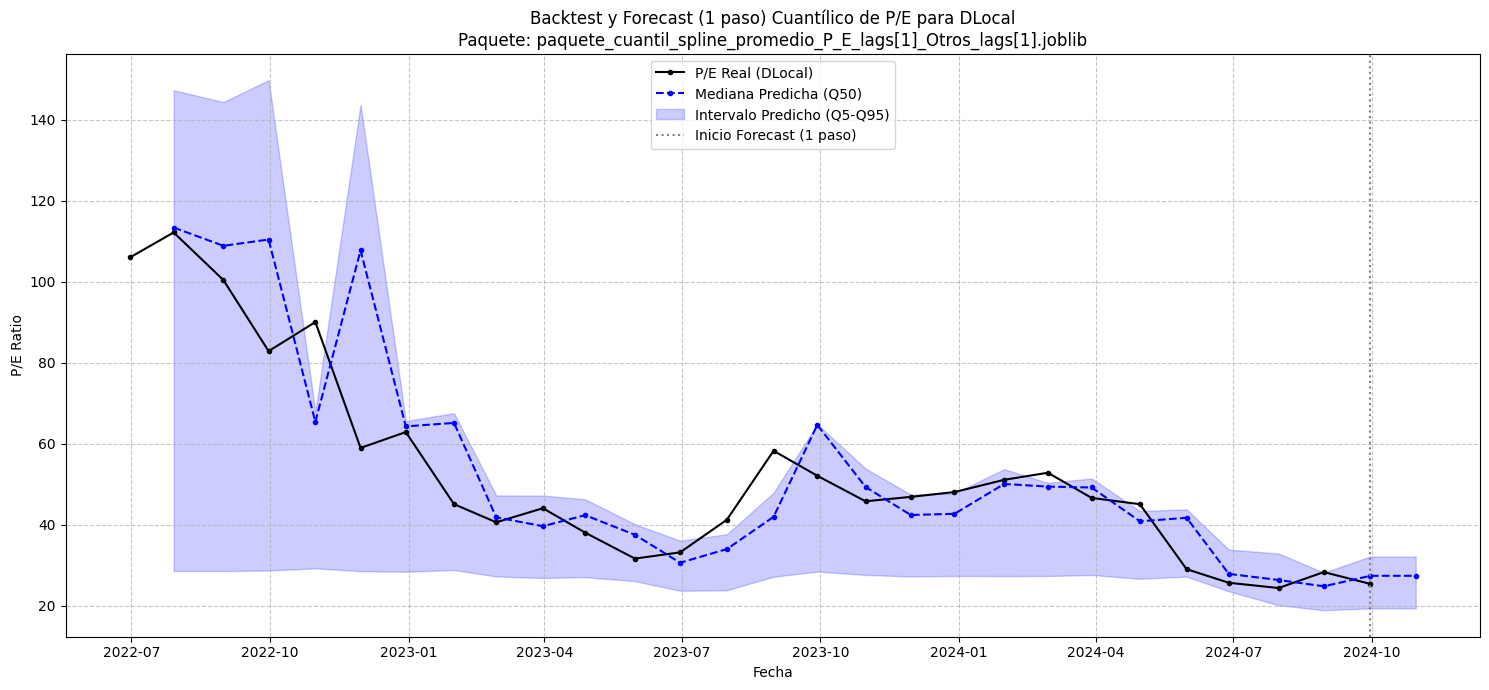


Forecast A Un Paso para DLocal:
       Fecha  P_E_pred_q5  P_E_pred_q50  P_E_pred_q95  P_E
0 2024-10-30    19.321581     27.375577     32.135069  NaN


In [56]:
# ================================================================================
# BLOQUE DE BACKTESTING "A UN PASO" Y FORECAST "A UN PASO" CUANTÍLICO PARA DLOCAL
# ================================================================================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import re
import warnings
from sklearn.metrics import mean_pinball_loss, mean_squared_error # Para métricas de backtesting

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# --- Configuración para la Predicción ---
EMPRESA_A_PREDECIR = "DLocal"
# N_FUTURE_STEPS ya no se usa para un forecast a un solo paso, pero lo dejamos por si se quiere cambiar
# N_FUTURE_STEPS_FORECAST = 1 # <--- CAMBIO CLAVE: Solo 1 paso para el forecast
QUANTILES_PREDICCION = [0.05, 0.5, 0.95]
ALPHA_LOWER_INTERVAL = QUANTILES_PREDICCION[0]
ALPHA_UPPER_INTERVAL = QUANTILES_PREDICCION[-1]
ALPHA_MEDIAN = QUANTILES_PREDICCION[len(QUANTILES_PREDICCION)//2]


# !!! NOMBRE DEL PAQUETE DE MODELOS ENTRENADOS !!!
NOMBRE_PAQUETE_MODELOS = "paquete_cuantil_spline_promedio_P_E_lags[1]_Otros_lags[1].joblib"
print(f"Usando el paquete: {NOMBRE_PAQUETE_MODELOS}")

# --- ASEGÚRATE DE QUE 'df_dlocal' ESTÉ DEFINIDO ANTES DE ESTE BLOQUE ---
if 'df_dlocal' not in locals() or not isinstance(df_dlocal, pd.DataFrame) or df_dlocal.empty:
    print(f"ERROR CRÍTICO: La variable 'df_dlocal' no está definida, no es un DataFrame o está vacía.")
    raise SystemExit("'df_dlocal' no disponible o inválida.")
else:
    print(f"INFO: Usando la variable 'df_dlocal' existente para los datos históricos de {EMPRESA_A_PREDECIR}.")
    df_empresa_hist_original = df_dlocal.copy()

# --- Cargar el paquete de modelos ---
# ... (Sección de carga de paquete sin cambios) ...
try:
    paquete_cargado = joblib.load(NOMBRE_PAQUETE_MODELOS)
    print(f"Paquete '{NOMBRE_PAQUETE_MODELOS}' cargado exitosamente.")
except FileNotFoundError:
    print(f"ERROR CRÍTICO: Archivo del paquete '{NOMBRE_PAQUETE_MODELOS}' no encontrado.")
    raise SystemExit(f"Archivo del paquete no encontrado: {NOMBRE_PAQUETE_MODELOS}")
except Exception as e:
    print(f"ERROR CRÍTICO: No se pudo cargar el paquete '{NOMBRE_PAQUETE_MODELOS}'. Error: {e}")
    raise SystemExit(f"Error al cargar el paquete: {e}")

log_transform_usada = paquete_cargado.get('log_transform_target')
features_entrenamiento = paquete_cargado.get('features_usadas_en_entrenamiento')
modelos_paquete = paquete_cargado.get('modelos_por_tipo_y_cuantil_o_puntual')

if any(v is None for v in [log_transform_usada, features_entrenamiento, modelos_paquete]):
    print("ERROR CRÍTICO: Información esencial faltante en el paquete cargado.")
    raise SystemExit("Paquete inválido.")

modelo_cuantil_key_base = None
for key_iter in modelos_paquete.keys():
    if 'Quantile' in key_iter and isinstance(modelos_paquete[key_iter], dict):
        potential_quantile_models = modelos_paquete[key_iter]
        if all(q_alpha in potential_quantile_models for q_alpha in QUANTILES_PREDICCION):
            modelo_cuantil_key_base = key_iter
            break
if not modelo_cuantil_key_base:
    print(f"ERROR CRÍTICO: No se encontró clave de diccionario para modelos cuantílicos en el paquete.")
    raise SystemExit("Modelos cuantílicos no encontrados en paquete.")
modelos_cuantil_dict = modelos_paquete[modelo_cuantil_key_base]
for alpha_val in QUANTILES_PREDICCION:
    if alpha_val not in modelos_cuantil_dict or not hasattr(modelos_cuantil_dict[alpha_val], 'predict'):
        print(f"ERROR CRÍTICO: Modelo para cuantil {alpha_val} faltante o inválido.")
        raise SystemExit(f"Modelo para cuantil {alpha_val} faltante o inválido.")

# --- Preparar datos históricos de DLocal ---
# ... (Sección de preparación de df_empresa_hist y función crear_features_con_lags sin cambios) ...
df_empresa_hist = df_empresa_hist_original.copy()
if 'Fecha' not in df_empresa_hist.columns:
    print("ERROR CRÍTICO: 'Fecha' no en df_empresa_hist (derivado de df_dlocal).")
    raise SystemExit("'Fecha' faltante.")
try:
    df_empresa_hist['Fecha'] = pd.to_datetime(df_empresa_hist['Fecha'])
except Exception as e_date:
    print(f"ERROR CRÍTICO: No se pudo convertir 'Fecha' a datetime. Error: {e_date}")
    raise SystemExit("Error en formato de 'Fecha'.")
df_empresa_hist.sort_values(by='Fecha', ascending=True, inplace=True)
df_empresa_hist.reset_index(drop=True, inplace=True)

def crear_features_con_lags_para_prediccion(df_historico_empresa, features_modelo_espera, fecha_base_prediccion):
    input_features = {}
    df_hist_para_lags = df_historico_empresa[df_historico_empresa['Fecha'] <= fecha_base_prediccion].sort_values(by='Fecha', ascending=False)
    if df_hist_para_lags.empty:
        for feat in features_modelo_espera: input_features[feat] = np.nan
        return pd.Series(input_features, index=features_modelo_espera)
    for feature_lag_name in features_modelo_espera:
        match = re.match(r"(.+)_lag(\d+)", feature_lag_name)
        if match:
            base_col_name = match.group(1)
            lag_n = int(match.group(2))
            if base_col_name not in df_hist_para_lags.columns:
                input_features[feature_lag_name] = np.nan
                continue
            if lag_n < len(df_hist_para_lags): 
                input_features[feature_lag_name] = df_hist_para_lags[base_col_name].iloc[lag_n]
            else:
                input_features[feature_lag_name] = np.nan
        else: 
            if feature_lag_name in df_hist_para_lags.columns:
                 input_features[feature_lag_name] = df_hist_para_lags[feature_lag_name].iloc[0] 
            else:
                input_features[feature_lag_name] = np.nan
    return pd.Series(input_features, index=features_modelo_espera)

# --- 1. BACKTESTING "A UN PASO": GENERAR PREDICCIONES PARA EL PERÍODO HISTÓRICO ---
# ... (Esta sección se mantiene igual que en el bloque anterior para el backtesting) ...
print("\n--- Backtesting A Un Paso para DLocal ---")
historical_predictions_list = []
min_lag_required = 0
if features_entrenamiento: 
    for feat_name in features_entrenamiento:
        match_lag = re.search(r"_lag(\d+)", feat_name)
        if match_lag:
            min_lag_required = max(min_lag_required, int(match_lag.group(1)))
for index, row_hist in df_empresa_hist.iterrows():
    current_hist_fecha = row_hist['Fecha']
    p_e_real_hist = row_hist.get('P_E', np.nan)
    pred_row_hist = {'Fecha': current_hist_fecha, 'P_E_real': p_e_real_hist}
    for alpha_val in QUANTILES_PREDICCION: 
        pred_row_hist[f'P_E_pred_q{int(alpha_val*100)}'] = np.nan
    if index < min_lag_required: 
        historical_predictions_list.append(pred_row_hist)
        continue
    hist_input_features = crear_features_con_lags_para_prediccion(df_empresa_hist, features_entrenamiento, current_hist_fecha)
    if hist_input_features.isna().all():
        historical_predictions_list.append(pred_row_hist)
        continue
    input_df_hist_model = pd.DataFrame([hist_input_features], columns=features_entrenamiento)
    for alpha_val in QUANTILES_PREDICCION:
        model_cuantil_actual = modelos_cuantil_dict[alpha_val]
        try:
            pred_transformed_hist = model_cuantil_actual.predict(input_df_hist_model)[0]
            if pd.isna(pred_transformed_hist): pred_original_hist = np.nan
            elif log_transform_usada: pred_original_hist = np.expm1(pred_transformed_hist)
            else: pred_original_hist = pred_transformed_hist
            pred_row_hist[f'P_E_pred_q{int(alpha_val*100)}'] = np.nan_to_num(pred_original_hist) if not pd.isna(pred_original_hist) else np.nan
        except Exception: pass             
    historical_predictions_list.append(pred_row_hist)
df_historical_quantile_preds = pd.DataFrame(historical_predictions_list)

# Calcular Métricas de Backtesting
# ... (Sección de métricas de backtesting sin cambios) ...
df_backtest_eval = df_historical_quantile_preds.dropna(
    subset=['P_E_real', f'P_E_pred_q{int(ALPHA_LOWER_INTERVAL*100)}', f'P_E_pred_q{int(ALPHA_UPPER_INTERVAL*100)}']
)
if not df_backtest_eval.empty:
    y_true_backtest = df_backtest_eval['P_E_real']
    pred_lower_backtest = df_backtest_eval[f'P_E_pred_q{int(ALPHA_LOWER_INTERVAL*100)}']
    pred_upper_backtest = df_backtest_eval[f'P_E_pred_q{int(ALPHA_UPPER_INTERVAL*100)}']
    coverage = np.mean((y_true_backtest >= pred_lower_backtest) & (y_true_backtest <= pred_upper_backtest))
    mean_interval_width = np.mean(pred_upper_backtest - pred_lower_backtest)
    pinball_loss_lower = mean_pinball_loss(y_true_backtest, pred_lower_backtest, alpha=ALPHA_LOWER_INTERVAL)
    pinball_loss_upper = mean_pinball_loss(y_true_backtest, pred_upper_backtest, alpha=ALPHA_UPPER_INTERVAL)
    avg_pinball_loss_interval = (pinball_loss_lower + pinball_loss_upper) / 2
    print(f"\nMétricas de Backtesting A Un Paso para DLocal:")
    print(f"  Puntos evaluados: {len(df_backtest_eval)}")
    print(f"  Cobertura ({ALPHA_LOWER_INTERVAL*100:.0f}%-{ALPHA_UPPER_INTERVAL*100:.0f}%): {coverage:.2%}")
    print(f"  Anchura Media Intervalo: {mean_interval_width:.2f}")
    print(f"  Pinball Loss Media Intervalo: {avg_pinball_loss_interval:.4f}")
    median_pred_col_name = f'P_E_pred_q{int(ALPHA_MEDIAN*100)}'
    if median_pred_col_name in df_backtest_eval.columns:
        valid_median_mask = df_backtest_eval[median_pred_col_name].notna()
        y_true_for_median = y_true_backtest[valid_median_mask]
        pred_median_backtest = df_backtest_eval.loc[valid_median_mask, median_pred_col_name]
        if not pred_median_backtest.empty and not y_true_for_median.empty:
            rmse_median = np.sqrt(mean_squared_error(y_true_for_median, pred_median_backtest))
            from sklearn.metrics import mean_absolute_error as mae
            mae_median = mae(y_true_for_median, pred_median_backtest)
            pinball_loss_median = mean_pinball_loss(y_true_for_median, pred_median_backtest, alpha=ALPHA_MEDIAN)
            print(f"  RMSE Mediana (Q{int(ALPHA_MEDIAN*100)}): {rmse_median:.2f}")
            print(f"  MAE Mediana (Q{int(ALPHA_MEDIAN*100)}): {mae_median:.2f}")
            print(f"  Pinball Loss Mediana (Q{int(ALPHA_MEDIAN*100)}): {pinball_loss_median:.4f}")
else:
    print("\nNo hay datos para métricas de backtesting.")

# --- 2. FORECAST "A UN PASO": GENERAR PREDICCIÓN SOLO PARA EL SIGUIENTE MES ---
print("\n--- Forecast A Un Paso para DLocal ---")
last_known_row_dlocal = df_empresa_hist.iloc[-1:]
last_known_P_E_original = last_known_row_dlocal['P_E'].iloc[0]
last_known_fecha = pd.to_datetime(last_known_row_dlocal['Fecha'].iloc[0])

# Features para predecir el primer mes futuro
features_for_next_step_forecast = crear_features_con_lags_para_prediccion(
    df_empresa_hist, features_entrenamiento, last_known_fecha
)

single_future_prediction_list = []
if not features_for_next_step_forecast.isna().all():
    input_df_forecast_model = pd.DataFrame([features_for_next_step_forecast], columns=features_entrenamiento)
    
    pred_step_transformed_future = {}
    pred_step_original_future = {}
    
    first_future_date = last_known_fecha + pd.DateOffset(months=1)
    pred_row_future = {'Fecha': first_future_date}

    for alpha_val in QUANTILES_PREDICCION:
        model_cuantil_actual = modelos_cuantil_dict[alpha_val]
        try:
            pred_transformed = model_cuantil_actual.predict(input_df_forecast_model)[0]
        except Exception:
            pred_transformed = np.nan
        pred_step_transformed_future[alpha_val] = pred_transformed
        
        if pd.isna(pred_transformed): pred_original_val = np.nan
        elif log_transform_usada: pred_original_val = np.expm1(pred_transformed)
        else: pred_original_val = pred_transformed
        pred_step_original_future[alpha_val] = np.nan_to_num(pred_original_val) if not pd.isna(pred_original_val) else np.nan
        pred_row_future[f'P_E_pred_q{int(alpha_val*100)}'] = pred_step_original_future[alpha_val]
        
    single_future_prediction_list.append(pred_row_future)
    
    q_strs_future = [f"Q{int(qv*100)}: {pred_step_original_future.get(qv, np.nan):.2f}" for qv in QUANTILES_PREDICCION]
    print(f"Predicción para {first_future_date.strftime('%Y-%m-%d')}: {', '.join(q_strs_future)}")
else:
    print("No se pudieron generar features para el forecast a un paso.")

df_single_future_prediction = pd.DataFrame(single_future_prediction_list)

# --- 3. COMBINAR DATAFRAMES Y GRAFICAR ---
df_historical_quantile_preds.rename(columns={'P_E_real': 'P_E'}, inplace=True, errors='ignore')
df_single_future_prediction['P_E'] = np.nan # No hay P/E real para el futuro

df_combined_predictions = pd.concat([df_historical_quantile_preds, df_single_future_prediction], ignore_index=True)
df_combined_predictions.sort_values(by='Fecha', inplace=True)

plt.figure(figsize=(15, 7))
plt.plot(df_combined_predictions['Fecha'], df_combined_predictions['P_E'], label=f'P/E Real ({EMPRESA_A_PREDECIR})', color='black', marker='.', linestyle='-')
median_col = f'P_E_pred_q{int(ALPHA_MEDIAN*100)}'
lower_col = f'P_E_pred_q{int(ALPHA_LOWER_INTERVAL*100)}'
upper_col = f'P_E_pred_q{int(ALPHA_UPPER_INTERVAL*100)}'
df_plot_median = df_combined_predictions.dropna(subset=[median_col])
df_plot_interval = df_combined_predictions.dropna(subset=[lower_col, upper_col])

if not df_plot_median.empty:
    plt.plot(df_plot_median['Fecha'], df_plot_median[median_col], label=f'Mediana Predicha (Q{int(ALPHA_MEDIAN*100)})', color='blue', marker='o', markersize=3, linestyle='--')
if not df_plot_interval.empty:
    plt.fill_between(df_plot_interval['Fecha'], df_plot_interval[lower_col], df_plot_interval[upper_col], color='blue', alpha=0.2, label=f'Intervalo Predicho (Q{int(ALPHA_LOWER_INTERVAL*100)}-Q{int(ALPHA_UPPER_INTERVAL*100)})')

# Línea vertical para separar backtest de forecast (ahora solo un punto de forecast)
plt.axvline(last_known_fecha, color='gray', linestyle=':', linewidth=1.5, label='Inicio Forecast (1 paso)')

plt.title(f'Backtest y Forecast (1 paso) Cuantílico de P/E para {EMPRESA_A_PREDECIR}\nPaquete: {NOMBRE_PAQUETE_MODELOS.split("/")[-1]}')
plt.xlabel('Fecha')
plt.ylabel('P/E Ratio')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Imprimir tabla de la única predicción futura
print("\n" + "="*80)
print(f"Forecast A Un Paso para {EMPRESA_A_PREDECIR}:")
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    print(df_single_future_prediction)
print("="*80)

Interpretación de los Resultados (Gráfico y Métricas):

Del Gráfico:

Visualización Correcta: El gráfico muestra claramente el P/E real histórico, la mediana predicha "a un paso" sobre ese histórico, el intervalo de confianza (Q5-Q95) también sobre el histórico, y luego una única predicción "a un paso" para el futuro (octubre de 2024) con su mediana e intervalo. La línea vertical "Inicio Forecast" marca bien la transición.

Intervalo Ancho al Inicio: Sigue siendo visible que el intervalo es particularmente ancho en los primeros meses del histórico (aproximadamente de 2022-07 a 2023-01). Esto, como hemos discutido, puede deberse a la volatilidad real de DLocal en ese período, a la menor cantidad de historia para los lags de otras features (si las hay y son importantes), o a cómo el modelo generaliza a las condiciones iniciales de DLocal.

Ajuste General: La mediana predicha (línea azul discontinua) sigue la tendencia general de los datos reales, aunque hay períodos de sobreestimación y subestimación. El intervalo de confianza parece capturar una buena parte de los datos reales, aunque no todos.

De las Métricas de Backtesting (para los 27 puntos evaluados):

Cobertura (5%-95%): 74.07%

El intervalo de confianza del 90% (Q5 a Q95) logró capturar el P/E real aproximadamente el 74% de las veces durante el período de backtesting.

Este valor es inferior al 90% esperado. Esto sugiere que los intervalos predichos son, en promedio, un poco demasiado estrechos o que el modelo está mal calibrado para DLocal en ciertos períodos (es decir, subestima la verdadera incertidumbre o variabilidad). La anchura visual al inicio podría ser una excepción a una tendencia general de intervalos más ajustados en otros momentos.

Anchura Media Intervalo: 35.60

En promedio, la diferencia entre el cuantil 95 y el cuantil 5 fue de 35.60 puntos de P/E. Debes juzgar si esta anchura es informativa para tus propósitos. Si el P/E suele estar en el rango de 20-60, un intervalo de 35 puntos es bastante grande.

Pinball Loss Media Intervalo: 1.6446

Esta es una medida agregada del error para los cuantiles del intervalo. Un valor más bajo es mejor. Es útil para comparar con otros modelos cuantílicos si los tuvieras.

RMSE Mediana (Q50): 13.70

El error cuadrático medio de la predicción mediana (Q50) es de 13.70 puntos de P/E.

MAE Mediana (Q50): 8.66

El error absoluto medio de la predicción mediana es de 8.66 puntos de P/E. Esto significa que, en promedio, la predicción mediana se desvió del valor real en 8.66 puntos.

Pinball Loss Mediana (Q50): 4.3283

Error específico para el cuantil mediano.

Del Forecast "A Un Paso":

Predicción para 2024-10-30: Q5: 19.32, Q50: 27.38, Q95: 32.14

Esta es tu predicción puntual (mediana) y el rango de incertidumbre para el próximo mes.

El último P/E real fue 25.37 (según tu log anterior). La mediana predicha de 27.38 es ligeramente superior. El intervalo (19.32 - 32.14) contiene el último valor real.

Conclusiones y Próximos Pasos:

Calibración del Intervalo: La cobertura del 74.07% para un intervalo nominal del 90% indica que los intervalos podrían ser demasiado optimistas (estrechos) en general, o que hay períodos específicos donde el modelo falla significativamente en capturar la variabilidad.

Investigar: Podrías graficar los residuos (Real - Mediana Predicha) y también si el real cayó dentro o fuera del intervalo para cada punto del backtest. Esto ayudaría a identificar patrones en los errores.

Posibles Acciones: Si la calibración es un problema persistente, podrías considerar reentrenar los modelos con diferentes parámetros, o incluso aplicar técnicas de post-procesamiento para recalibrar los intervalos (aunque esto es más avanzado).

Anchura del Intervalo: Aunque la cobertura es un poco baja, la anchura media de 35.60 es considerable. Esto sugiere que, incluso cuando el modelo intenta ser preciso, la incertidumbre inherente (o la percibida por el modelo) es alta.

Errores de la Mediana: Un MAE de 8.66 puntos de P/E es el error típico de tu predicción puntual. Compara esto con la variabilidad histórica del P/E de DLocal para juzgar si es aceptable.

Intervalo Ancho al Inicio: Sigue siendo un punto a considerar. Si los primeros meses del backtesting tienen errores mucho mayores o intervalos desproporcionadamente anchos, podrías excluirlos del cálculo de métricas para obtener una visión del rendimiento en un período más "estable" o con más historia de lags.